In [1]:
from io import StringIO
import csv
import pandas as pd
import math
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import re
import itertools
from collections import Counter
import seaborn as sns
import seaborn.objects as so

In [2]:
WORKDIR="../datasets/qe-ts/"
YML_FILE="experiment-1-1.yml.pkl"

In [3]:
%%capture output
%%bash -s "$WORKDIR" "$YML_FILE"
cd $1;
./postprocess.sh ts_storage_stats $2

In [4]:
storage_stats_csv = output.stdout
storage_stats_csv

'Task Name,Execution,Name,Total Objects,Uncompressed Data Size,Compressed Data Size,Index Size,Total Compressed Size\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_EDC,100000,444700000,399446016,327086080,726532096\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_ESC,3100000,145700000,215789568,0,215789568\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_ECOC,3100000,316200000,216981504,0,216981504\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_EDC,100000,1225600000,1215791104,1342222336,2558013440\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_ESC,8800000,413600000,1032380416,0,1032380416\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_ECOC,8800000,897600000,606531584,0,606531584\nexperiment11_fixed-uniform-32_e_16_substring_3_7,0,FinalDBStatsUser_Stats_EDC,100000,1955800000,2019598336,2085453824,4105052160\nexperiment11_fix

In [5]:
%%capture output
%%bash -s "$WORKDIR" "$YML_FILE"
cd $1;
./postprocess.sh ts_locust_stats $2

In [6]:
locust_stats_csv = output.stdout
storage_stats_csv

'Task Name,Execution,Name,Total Objects,Uncompressed Data Size,Compressed Data Size,Index Size,Total Compressed Size\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_EDC,100000,444700000,399446016,327086080,726532096\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_ESC,3100000,145700000,215789568,0,215789568\nexperiment11_fixed-uniform-32_e_16_substring_3_3,0,FinalDBStatsUser_Stats_ECOC,3100000,316200000,216981504,0,216981504\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_EDC,100000,1225600000,1215791104,1342222336,2558013440\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_ESC,8800000,413600000,1032380416,0,1032380416\nexperiment11_fixed-uniform-32_e_16_substring_3_5,0,FinalDBStatsUser_Stats_ECOC,8800000,897600000,606531584,0,606531584\nexperiment11_fixed-uniform-32_e_16_substring_3_7,0,FinalDBStatsUser_Stats_EDC,100000,1955800000,2019598336,2085453824,4105052160\nexperiment11_fix

In [14]:
f = StringIO(storage_stats_csv)
storage_stats = pd.read_csv(f)
storage_stats

f2 = StringIO(locust_stats_csv)
locust_stats = pd.read_csv(f2)
locust_stats

,Task Name,Execution,Type,Name,Request Count,Failure Count,Median Response Time,Average Response Time,Min Response Time,Max Response Time,...,66%,75%,80%,90%,95%,98%,99%,99.9%,99.99%,100%
0,experiment11_fixed-uniform-32_e_16_substring_3_3,0,insert,LoadUser_InsertBatch,100000,0,9523000,1.022376e+07,7586252,244091399,...,9876000,10123000,10376000,13602000,15036000,17694000,21211000,54121000,197816000,244091000
1,experiment11_fixed-uniform-32_e_16_substring_3_3,0,NaN,Aggregated,100000,0,9523000,1.022376e+07,7586252,244091399,...,9876000,10123000,10376000,13602000,15036000,17694000,21211000,54121000,197816000,244091000
2,experiment11_fixed-uniform-32_e_16_substring_3_5,0,insert,LoadUser_InsertBatch,100000,0,24225000,2.799035e+07,13020378,306106818,...,28511000,31649000,34033000,42375000,52418000,66269000,76584000,125053000,255790000,306107000
3,experiment11_fixed-uniform-32_e_16_substring_3_5,0,NaN,Aggregated,100000,0,24225000,2.799035e+07,13020378,306106818,...,28511000,31649000,34033000,42375000,52418000,66269000,76584000,125053000,255790000,306107000
4,experiment11_fixed-uniform-32_e_16_substring_3_7,0,insert,LoadUser_InsertBatch,100000,0,45012000,5.218407e+07,18225772,552436109,...,53199000,59747000,65156000,84658000,104475000,132151000,156415000,254238000,421228000,552436000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,experiment11_var-zipf-16_e_8_substring_5_7,0,NaN,Aggregated,100000,0,8381000,8.741768e+06,4546797,244987895,...,9192000,9692000,9932000,10749000,12090000,15565000,19209000,40286000,195801000,244988000
708,experiment11_var-zipf-16_e_8_substring_7_7,0,insert,LoadUser_InsertBatch,100000,0,5721000,5.901714e+06,3356669,240120518,...,6106000,6375000,6560000,7013000,7507000,8664000,11148000,19736000,216001000,240121000
709,experiment11_var-zipf-16_e_8_substring_7_7,0,NaN,Aggregated,100000,0,5721000,5.901714e+06,3356669,240120518,...,6106000,6375000,6560000,7013000,7507000,8664000,11148000,19736000,216001000,240121000
710,experiment11_var-zipf-16_u,0,insert,LoadUser_InsertBatch,100000,0,2651000,2.814465e+06,1468708,144745545,...,2928000,3054000,3155000,3499000,3882000,4848000,7750000,16836000,79554000,144746000


In [15]:
# experiment11_var-zipf-16_e_8_substring_7_7
pattern_e11 = r"experiment11_(?P<Svar_or_fixed>[a-z]+)-(?P<Szipf_or_uniform>[a-z]+)-(?P<Imlen>[0-9]+)_(?P<Se_or_u>[a-z])(_(?P<Icf>[0-9]+)_(?P<Sss_or_pref>[a-z]+)_(?P<Ilb>[0-9]+)_(?P<Iub>[0-9]+))?"

for st in [locust_stats, storage_stats]:
    keys_to_add = {}
    for name in st["Task Name"]:
        d = re.match(pattern_e11, name).groupdict()
        for k, v in d.items():
            if k[0] == 'I':
                v = int(v) if v is not None else -1
            elif k[0] == 'S':
                v = str(v) if v is not None else ""
            k = k[1:]
            if k not in keys_to_add:
                keys_to_add[k] = []
            keys_to_add[k].append(v)

    for k, v in keys_to_add.items():
        st[k] = v

In [16]:
locust_stats_name_map = {'Task Name': 'name', 'Request Count': 'count', 'Failure Count': 'failures', 'Average Response Time': 'lat_avg', 'Min Response Time': 'lat_min', 'Max Response Time': 'lat_max',
                         'Requests/s': 'req_per_s', 'Failures/s': 'fail_per_s'}
for pcnt in ['50%', '66%', '75%', '80%', '90%', '95%','98%', '99%', '99.9%', '99.99%']:
    locust_stats_name_map[pcnt] = f'lat{pcnt[:-1]}'
locust_stats_drop_cols = ['Execution', 'Type', 'Name', 'Median Response Time', 'Average Content Size', '100%']

# Filter out aggregated column
locust_stats = locust_stats[locust_stats['Name'] != 'Aggregated']

locust_stats = locust_stats.drop(columns=locust_stats_drop_cols)
locust_stats = locust_stats.rename(columns=locust_stats_name_map)

locust_stats.columns

Index(['name', 'count', 'failures', 'lat_avg', 'lat_min', 'lat_max',
       'req_per_s', 'fail_per_s', 'lat50', 'lat66', 'lat75', 'lat80', 'lat90',
       'lat95', 'lat98', 'lat99', 'lat99.9', 'lat99.99', 'var_or_fixed',
       'zipf_or_uniform', 'mlen', 'e_or_u', 'cf', 'ss_or_pref', 'lb', 'ub'],
      dtype='object')

In [17]:
storage_stats_name_map = {'Task Name': 'name', 'Name': 'stat_name', 'Total Objects': 'count', 'Uncompressed Data Size': 'data_size', 'Compressed Data Size': 'compressed_size', 'Index Size': 'index_size', 'Total Compressed Size': 'total_size'}
storage_stats_drop_cols = ['Execution']
storage_stats = storage_stats.drop(columns=storage_stats_drop_cols)
storage_stats = storage_stats.rename(columns=storage_stats_name_map)

storage_stats

,name,stat_name,count,data_size,compressed_size,index_size,total_size,var_or_fixed,zipf_or_uniform,mlen,e_or_u,cf,ss_or_pref,lb,ub
0,experiment11_fixed-uniform-32_e_16_substring_3_3,FinalDBStatsUser_Stats_EDC,100000,444700000,399446016,327086080,726532096,fixed,uniform,32,e,16,substring,3,3
1,experiment11_fixed-uniform-32_e_16_substring_3_3,FinalDBStatsUser_Stats_ESC,3100000,145700000,215789568,0,215789568,fixed,uniform,32,e,16,substring,3,3
2,experiment11_fixed-uniform-32_e_16_substring_3_3,FinalDBStatsUser_Stats_ECOC,3100000,316200000,216981504,0,216981504,fixed,uniform,32,e,16,substring,3,3
3,experiment11_fixed-uniform-32_e_16_substring_3_5,FinalDBStatsUser_Stats_EDC,100000,1225600000,1215791104,1342222336,2558013440,fixed,uniform,32,e,16,substring,3,5
4,experiment11_fixed-uniform-32_e_16_substring_3_5,FinalDBStatsUser_Stats_ESC,8800000,413600000,1032380416,0,1032380416,fixed,uniform,32,e,16,substring,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,experiment11_var-zipf-16_e_8_substring_7_7,FinalDBStatsUser_Stats_ESC,747280,35122160,67362816,0,67362816,var,zipf,16,e,8,substring,7,7
1064,experiment11_var-zipf-16_e_8_substring_7_7,FinalDBStatsUser_Stats_ECOC,747280,76222560,41521152,0,41521152,var,zipf,16,e,8,substring,7,7
1065,experiment11_var-zipf-16_u,FinalDBStatsUser_Stats_EDC,100000,3709812,3616768,3514368,7131136,var,zipf,16,u,-1,,-1,-1
1066,experiment11_var-zipf-16_u,FinalDBStatsUser_Stats_ESC,0,0,0,0,0,var,zipf,16,u,-1,,-1,-1


In [18]:
unq_colls = storage_stats['stat_name'].unique()
merged_stats = locust_stats
for stat_name in unq_colls:
    split_stat = storage_stats[storage_stats['stat_name'] == stat_name]
    rem_cols = ['var_or_fixed', 'zipf_or_uniform', 'mlen', 'e_or_u', 'cf', 'ss_or_pref', 'lb', 'ub', 'stat_name']
    prefix = stat_name.split('_')[-1].lower()
    col_map = {c: prefix + "_" + c for c in split_stat.columns if c != 'name'}
    renamed_split = split_stat.drop(columns=rem_cols).rename(columns=col_map)
    merged_stats = pd.merge(merged_stats, renamed_split, on='name', how='inner')

print(merged_stats.columns)
merged_stats

Index(['name', 'count', 'failures', 'lat_avg', 'lat_min', 'lat_max',
       'req_per_s', 'fail_per_s', 'lat50', 'lat66', 'lat75', 'lat80', 'lat90',
       'lat95', 'lat98', 'lat99', 'lat99.9', 'lat99.99', 'var_or_fixed',
       'zipf_or_uniform', 'mlen', 'e_or_u', 'cf', 'ss_or_pref', 'lb', 'ub',
       'edc_count', 'edc_data_size', 'edc_compressed_size', 'edc_index_size',
       'edc_total_size', 'esc_count', 'esc_data_size', 'esc_compressed_size',
       'esc_index_size', 'esc_total_size', 'ecoc_count', 'ecoc_data_size',
       'ecoc_compressed_size', 'ecoc_index_size', 'ecoc_total_size'],
      dtype='object')


,name,count,failures,lat_avg,lat_min,lat_max,req_per_s,fail_per_s,lat50,lat66,...,esc_count,esc_data_size,esc_compressed_size,esc_index_size,esc_total_size,ecoc_count,ecoc_data_size,ecoc_compressed_size,ecoc_index_size,ecoc_total_size
0,experiment11_fixed-uniform-32_e_16_substring_3_3,100000,0,1.022376e+07,7586252,244091399,669.774673,0.0,9523000,9876000,...,3100000,145700000,215789568,0,215789568,3100000,316200000,216981504,0,216981504
1,experiment11_fixed-uniform-32_e_16_substring_3_5,100000,0,2.799035e+07,13020378,306106818,388.146773,0.0,24226000,28511000,...,8800000,413600000,1032380416,0,1032380416,8800000,897600000,606531584,0,606531584
2,experiment11_fixed-uniform-32_e_16_substring_3_7,100000,0,5.218407e+07,18225772,552436109,220.338020,0.0,45012000,53199000,...,14100000,662700000,1696546816,0,1696546816,14100000,1438200000,1009655808,0,1009655808
3,experiment11_fixed-uniform-32_e_16_substring_5_5,100000,0,8.968460e+06,7115330,259630532,660.158976,0.0,8681000,9049000,...,2900000,136300000,196939776,0,196939776,2900000,295800000,189419520,0,189419520
4,experiment11_fixed-uniform-32_e_16_substring_5_7,100000,0,2.287579e+07,12756613,260457282,455.929903,0.0,20870000,23948000,...,8200000,385400000,842731520,0,842731520,8200000,836400000,593805312,0,593805312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,experiment11_var-zipf-16_e_8_substring_3_7,100000,0,1.256877e+07,6563075,238708740,627.947177,0.0,12117000,13069000,...,4782525,224778675,420925440,0,420925440,4782525,487817550,250646528,0,250646528
352,experiment11_var-zipf-16_e_8_substring_5_5,100000,0,6.800306e+06,3911173,234057446,665.746864,0.0,6616000,7063000,...,1036850,48731950,97984512,0,97984512,1036850,105758700,64376832,0,64376832
353,experiment11_var-zipf-16_e_8_substring_5_7,100000,0,8.741768e+06,4546797,244987895,667.150090,0.0,8382000,9192000,...,2569150,120750050,216752128,0,216752128,2569150,262053300,134791168,0,134791168
354,experiment11_var-zipf-16_e_8_substring_7_7,100000,0,5.901714e+06,3356669,240120518,663.671101,0.0,5721000,6106000,...,747280,35122160,67362816,0,67362816,747280,76222560,41521152,0,41521152


In [19]:
# useful segmentations
enc_stats = merged_stats[merged_stats['e_or_u'] == 'e']
unenc_stats = merged_stats[merged_stats['e_or_u'] == 'u']

In [20]:
import bisect
import random


def calculate_harmonic_sum(n, alpha):
    total_sum = 0.0
    for i in range(1, n + 1):
        total_sum = total_sum + 1 / math.pow(i, alpha)
    return total_sum


def get_zipf_docs(values, n):
    sum_freq = 0
    # numValues = <SET THIS>
    alpha = 1.1
    freq_list = []
    exact_freq_list = []

    h = calculate_harmonic_sum(len(values), alpha)

    for i in range(len(values)):
        exact_f_i = n * (math.pow(i + 1, -alpha) / h)
        f_i = math.ceil(exact_f_i)
        freq_list.append(f_i)
        exact_freq_list.append(exact_f_i)
        sum_freq += f_i

    if sum_freq > n:
        assert freq_list[0] > 0
        print("off by" + str(sum_freq - n))
        off_by_after_sub = [
            abs((freq_list[i] - 1 - exact_freq_list[i]) / exact_freq_list[i])
            for i in range(len(freq_list))
        ]
        sorted_off_by = [(-offby, i) for i, offby in enumerate(off_by_after_sub)]
        sorted_off_by.sort()
        while sum_freq > n:
            _, i = sorted_off_by.pop()
            assert freq_list[i] > 0
            freq_list[i] -= 1
            sum_freq -= 1
            new_offby = abs((freq_list[i] - 1 - exact_freq_list[i]) / exact_freq_list[i])
            bisect.insort(sorted_off_by, (-new_offby, i))

        assert sum(freq_list) == n
        assert freq_list[0] > 0

    docs = []
    for i in range(len(values)):
        docs += [values[i]] * freq_list[i]

    random.shuffle(docs)
    return docs


def get_docs(coll_type, n):
    t = coll_type.split("-")
    assert len(t) == 3
    assert t[0] in ("fixed", "var")
    assert t[1] in ("uniform", "zipf")
    mlen = int(t[2])
    if t[1] == "zipf":
        values = set()
        if t[0] == "fixed":
            while len(values) < 1000:
                values.add("".join(random.choices("0123456789", k=mlen)))
        else:
            while len(values) < 1000:
                slen = random.randint(1, mlen)
                values.add("".join(random.choices("0123456789", k=slen)))
        lvalues = list(values)
        random.shuffle(lvalues)
        return get_zipf_docs(lvalues, n)
    else:
        if t[0] == "fixed":
            return ["".join(random.choices("0123456789", k=mlen)) for _ in range(n)]
        else:
            return [
                "".join(random.choices("0123456789", k=random.randint(1, mlen))) for _ in range(n)
            ]

In [21]:
colltypes = ['fixed-uniform-16', 'var-uniform-16', 'fixed-zipf-16', 'var-zipf-16', 'fixed-uniform-32', 'var-uniform-32']
docsets = {k: get_docs(k, 100000) for k in colltypes}
mydata = pd.DataFrame(columns=["colltype", "itype", "lb", "ub", "nreal", "ndummy", "ntotal"])
for typ in colltypes:
    for idx in ('prefix', 'substring'):
        for lb in (1, 3, 5, 7):
            if idx == 'substring' and lb == 1:
                continue
            for ub in range(lb, 8, 2):
                nreal = 0
                ndummy = 0
                for doc in docsets[typ]:
                    real_len = len(doc)
                    mlen = int(typ.split('-')[2])
                    cbc_len = min(mlen, math.ceil((real_len + 5) / 16.) * 16 - 5)
                    if idx == 'prefix':
                        smallest_tag = lb
                        largest_tag = min(ub, real_len)
                        real_tags = 1 + max(largest_tag - smallest_tag + 1, 0)
                        total_tags = 2 + ub - lb
                        nreal += real_tags
                        ndummy += total_tags - real_tags
                    else:
                        real_tags = set()
                        mclen = min(cbc_len, mlen)
                        total_tags = 0
                        for taglen in range(lb, ub+1):
                            if taglen > mclen:
                                break
                            total_tags += mclen - taglen + 1
                            if taglen > real_len:
                                continue
                            for i in range(0, len(doc) - taglen + 1):
                                real_tags.add(doc[i:i+taglen])
                        
                        nreal += 1 + len(real_tags)
                        ndummy += total_tags - len(real_tags)
                mydata.loc[len(mydata)] = [typ, idx, lb, ub, nreal, ndummy, nreal + ndummy]
                print(f'{typ}, {idx}, ({lb}, {ub}): real: {nreal}, dummy: {ndummy}, total: {nreal + ndummy}')
mydata


off by509
off by509
fixed-uniform-16, prefix, (1, 1): real: 200000, dummy: 0, total: 200000
fixed-uniform-16, prefix, (1, 3): real: 400000, dummy: 0, total: 400000
fixed-uniform-16, prefix, (1, 5): real: 600000, dummy: 0, total: 600000
fixed-uniform-16, prefix, (1, 7): real: 800000, dummy: 0, total: 800000
fixed-uniform-16, prefix, (3, 3): real: 200000, dummy: 0, total: 200000
fixed-uniform-16, prefix, (3, 5): real: 400000, dummy: 0, total: 400000
fixed-uniform-16, prefix, (3, 7): real: 600000, dummy: 0, total: 600000
fixed-uniform-16, prefix, (5, 5): real: 200000, dummy: 0, total: 200000
fixed-uniform-16, prefix, (5, 7): real: 400000, dummy: 0, total: 400000
fixed-uniform-16, prefix, (7, 7): real: 200000, dummy: 0, total: 200000
fixed-uniform-16, substring, (3, 3): real: 1491167, dummy: 8833, total: 1500000
fixed-uniform-16, substring, (3, 5): real: 3990402, dummy: 9598, total: 4000000
fixed-uniform-16, substring, (3, 7): real: 6090399, dummy: 9601, total: 6100000
fixed-uniform-16, su

,colltype,itype,lb,ub,nreal,ndummy,ntotal
0,fixed-uniform-16,prefix,1,1,200000,0,200000
1,fixed-uniform-16,prefix,1,3,400000,0,400000
2,fixed-uniform-16,prefix,1,5,600000,0,600000
3,fixed-uniform-16,prefix,1,7,800000,0,800000
4,fixed-uniform-16,prefix,3,3,200000,0,200000
...,...,...,...,...,...,...,...
91,var-uniform-32,substring,3,5,4174366,1710315,5884681
92,var-uniform-32,substring,3,7,6457066,2784069,9241135
93,var-uniform-32,substring,5,5,1371209,557018,1928227
94,var-uniform-32,substring,5,7,3653909,1630772,5284681


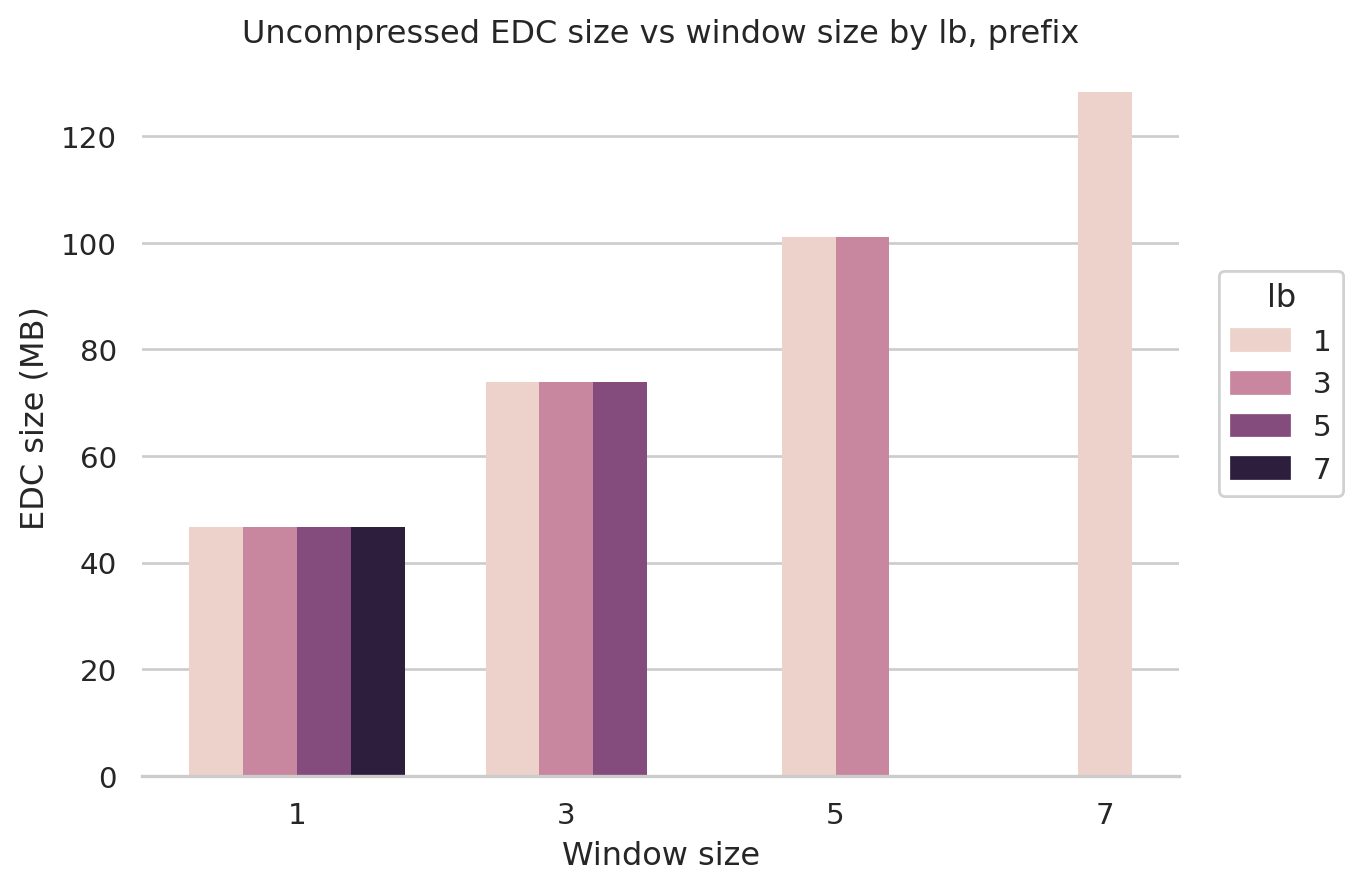

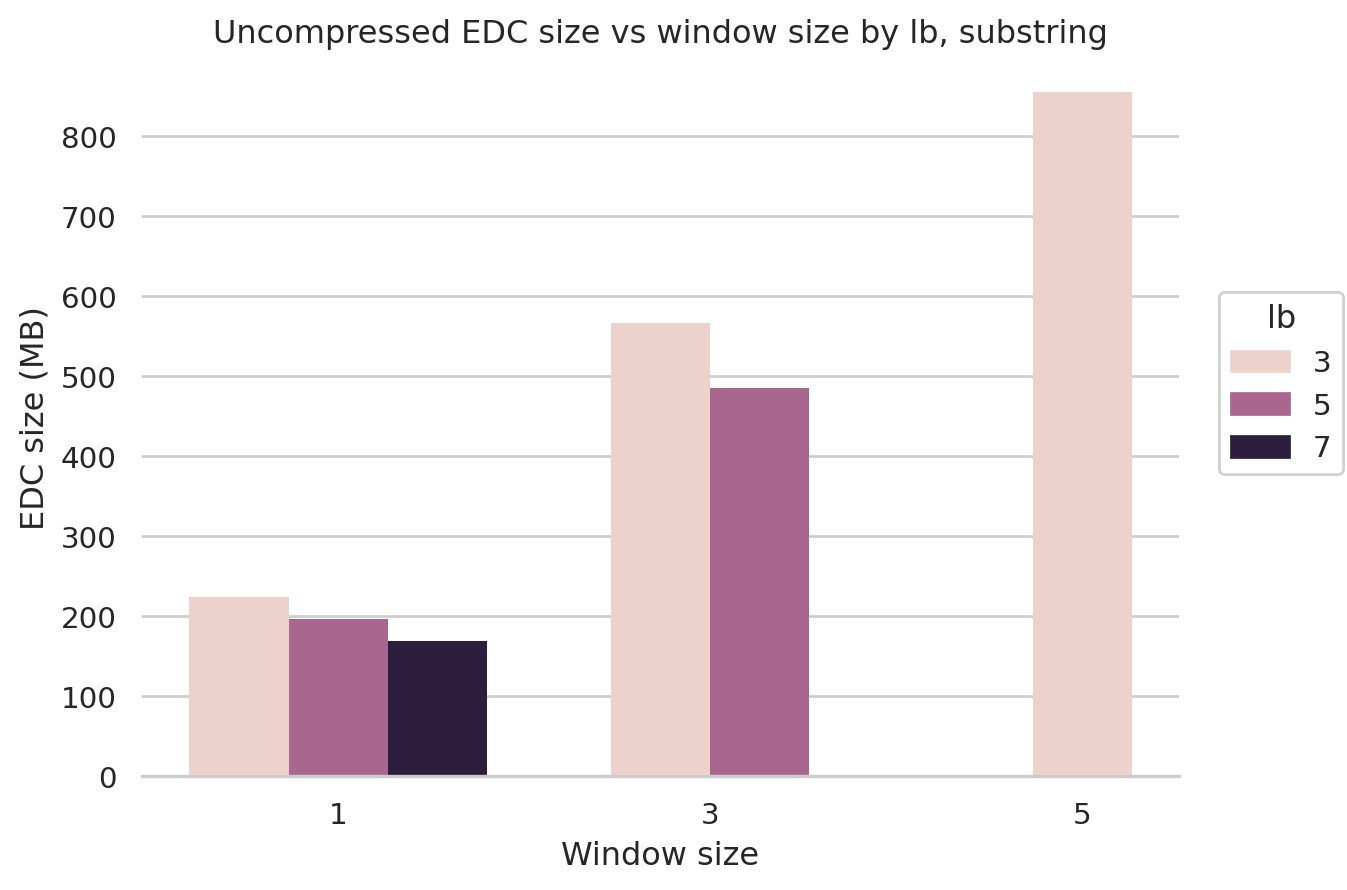

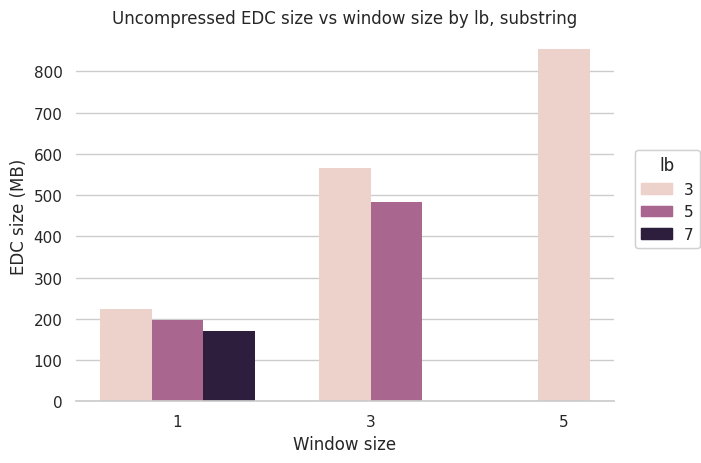

In [271]:
# Graph 1
for typ in ('prefix', 'substring'):
    stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['var_or_fixed'] == 'fixed') & (enc_stats['zipf_or_uniform'] == 'uniform') & (enc_stats['cf'] == 4)].copy()
    stats['window_size'] = stats['ub'] - stats['lb'] + 1
    # for row in stats.rows():
    #     row['lbub'] = (row['lb'], row['ub'])
    # stats.groupby('window_size')
    # print(stats[['name', 'window_size', 'lb', 'edc_data_size', 'esc_count']])
    stats['lb_aba'] = stats['lb'].astype(str)
    stats['edc_data_size_mb'] = stats['edc_data_size'] / 1000000.
    title = f'Uncompressed EDC size vs window size by lb, {typ}'
    plt.close()
    ax = plt.gca()
    p = so.Plot(stats, x='window_size', y='edc_data_size_mb', color='lb')
    p = p.add(so.Bar(alpha=1), so.Dodge(empty='drop'))
    p = p.label(title=title, x='Window size', y='EDC size (MB)')
    p = p.theme(sns.axes_style(style='whitegrid'))
    p = p.scale(x=so.Continuous().tick(at=stats['window_size'].unique()), color=so.Continuous().tick(at=stats['lb'].unique()))
    p = p.layout(engine='tight')
    p = p.on(ax)
    sns.despine(ax=ax, left=True)
    ax.grid(False, axis='x')

    p.save(f'../figures/graph1-{typ}.png', bbox_inches='tight')
    display(p)
    # g = sns.catplot(data=stats, kind='bar', x='window_size', y='edc_data_size_mb', col='lb', sharex=False, hue='lb')
    # g.set(title=title, xlabel='Window size', ylabel='EDC size (MB)')
    # g.despine(left=True)


     ub  avg_tag_count        collname
64    1            2.0  fixed, uniform
65    3            4.0  fixed, uniform
66    5            6.0  fixed, uniform
67    7            8.0  fixed, uniform
145   1            2.0     fixed, zipf
146   3            4.0     fixed, zipf
147   5            6.0     fixed, zipf
148   7            8.0     fixed, zipf
226   1            2.0    var, uniform
227   3            4.0    var, uniform
228   5            6.0    var, uniform
229   7            8.0    var, uniform
307   1            2.0       var, zipf
308   3            4.0       var, zipf
309   5            6.0       var, zipf
310   7            8.0       var, zipf


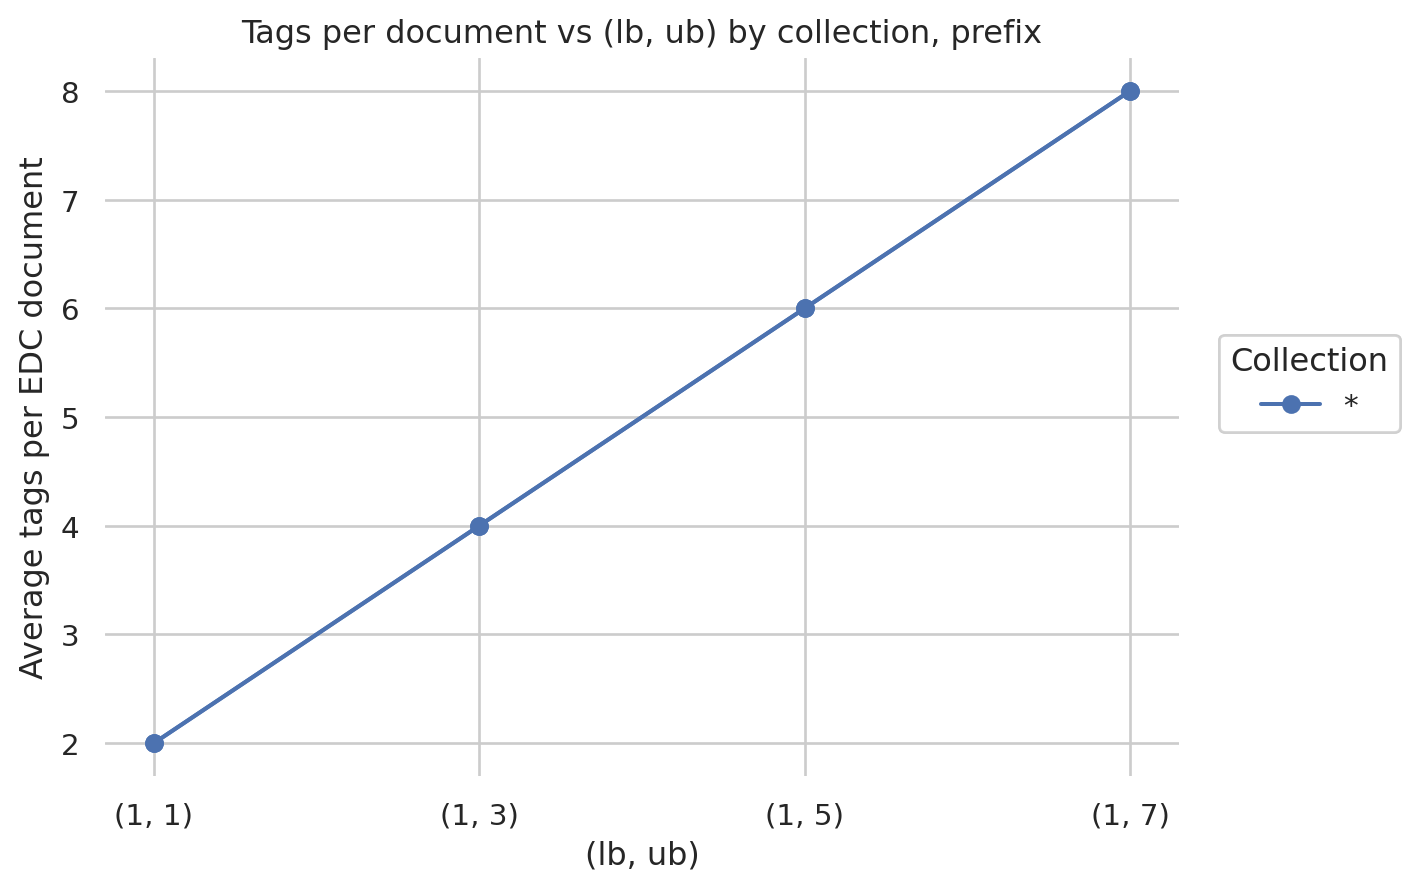

     ub  avg_tag_count        collname
74    3       15.00000  fixed, uniform
75    5       40.00000  fixed, uniform
76    7       61.00000  fixed, uniform
155   3       15.00000     fixed, zipf
156   5       40.00000     fixed, zipf
157   7       61.00000     fixed, zipf
236   3       11.55560    var, uniform
237   5       29.70715    var, uniform
238   7       43.86675    var, uniform
317   3       11.76810       var, zipf
318   5       28.81885       var, zipf
319   7       47.82525       var, zipf


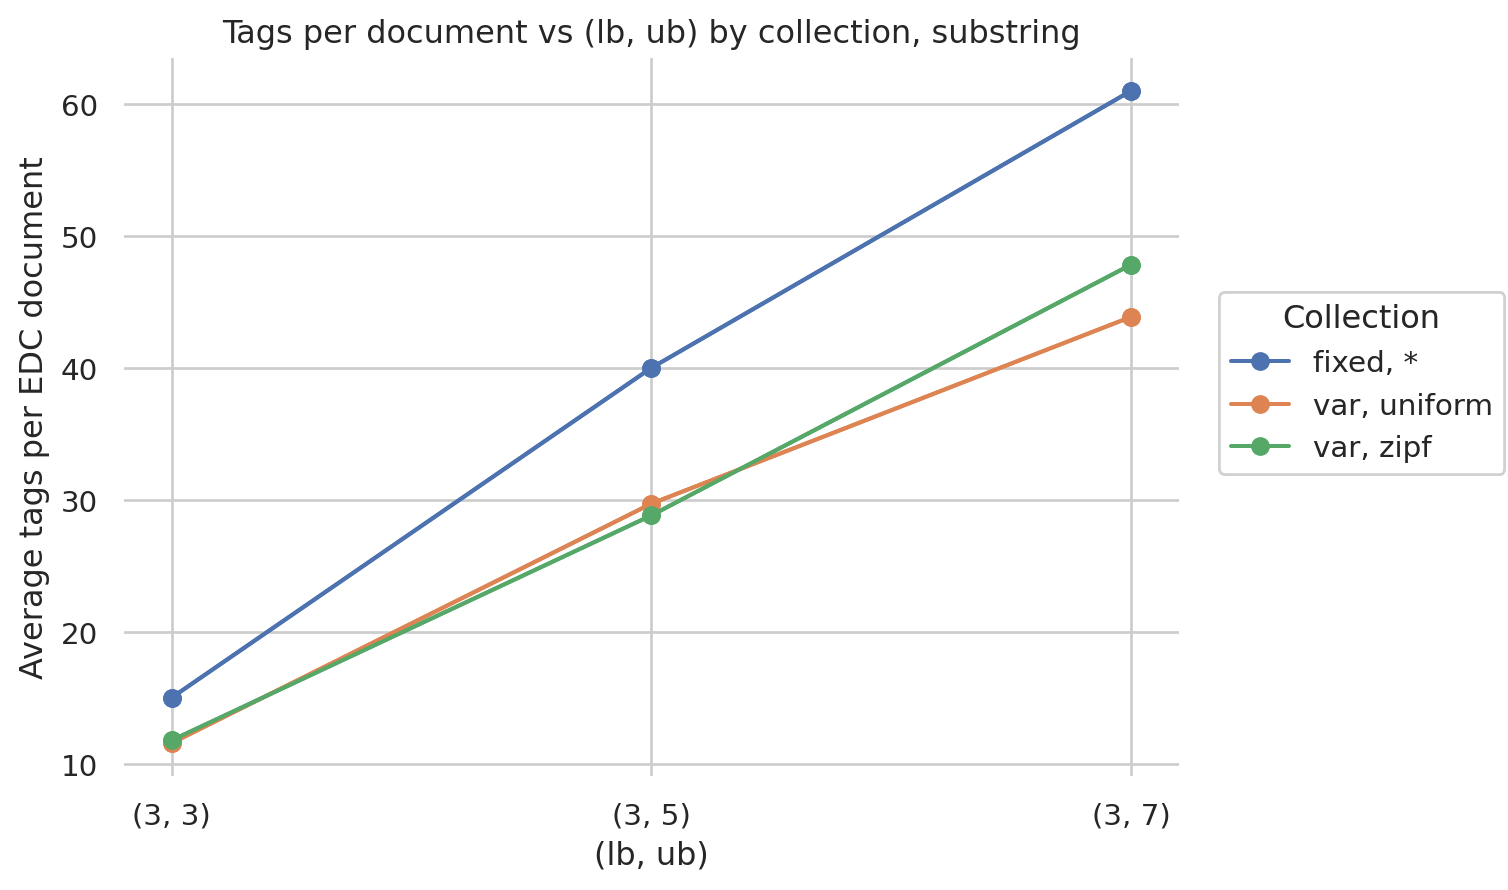

In [272]:
# Graph 2
for typ in ('prefix', 'substring'):
    lowest_lb = 1 if typ == 'prefix' else 3
    stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['cf'] == 8) & (enc_stats['lb'] == lowest_lb)].copy()

    title = f'Tags per document vs (lb, ub) by collection, {typ}'
    stats['avg_tag_count'] = stats['esc_count'] / stats['edc_count']
    stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
    print(stats[['ub', 'avg_tag_count', 'collname']])
    if typ == 'prefix':
        stats = stats[stats['collname'] == 'fixed, uniform']
        stats['collname'] = '*'
    else:
        stats = stats[stats['collname'] != 'fixed, uniform']
        stats['collname'] = stats['collname'].replace('fixed, zipf', 'fixed, *')
    plt.close()
    ax = plt.gca()
    p = so.Plot(stats, x='ub', y='avg_tag_count', color='collname')
    p = p.add(so.Line(alpha=1, marker='o'))
    p = p.label(title=title, x='(lb, ub)', y='Average tags per EDC document', color='Collection')
    p = p.theme(sns.axes_style(style='whitegrid'))
    p = p.layout(engine='tight')
    p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
    p = p.on(ax)
    sns.despine(ax=ax, left=True, bottom=True)
    # ax.grid(False, axis='x')

    p.save(f'../figures/graph2-{typ}.png', bbox_inches='tight')
    display(p)
    plt.close()
    
    # g = sns.catplot(data=stats, kind='bar', x='window_size', y='edc_data_size_mb', col='lb', sharex=False, hue='lb')
    # g.set(title=title, xlabel='Window size', ylabel='EDC size (MB)')
    # g.despine(left=True)


     ub  avg_tag_count        collname
64    1            2.0  fixed, uniform
65    3            4.0  fixed, uniform
66    5            6.0  fixed, uniform
67    7            8.0  fixed, uniform
145   1            2.0     fixed, zipf
146   3            4.0     fixed, zipf
147   5            6.0     fixed, zipf
148   7            8.0     fixed, zipf
226   1            2.0    var, uniform
227   3            4.0    var, uniform
228   5            6.0    var, uniform
229   7            8.0    var, uniform
307   1            2.0       var, zipf
308   3            4.0       var, zipf
309   5            6.0       var, zipf
310   7            8.0       var, zipf
fixed, uniform
    index                                          name   count  failures  \
0      64  experiment11_fixed-uniform-16_e_8_prefix_1_1  100000         0   
1      65  experiment11_fixed-uniform-16_e_8_prefix_1_3  100000         0   
2      66  experiment11_fixed-uniform-16_e_8_prefix_1_5  100000         0   
3      67  exp

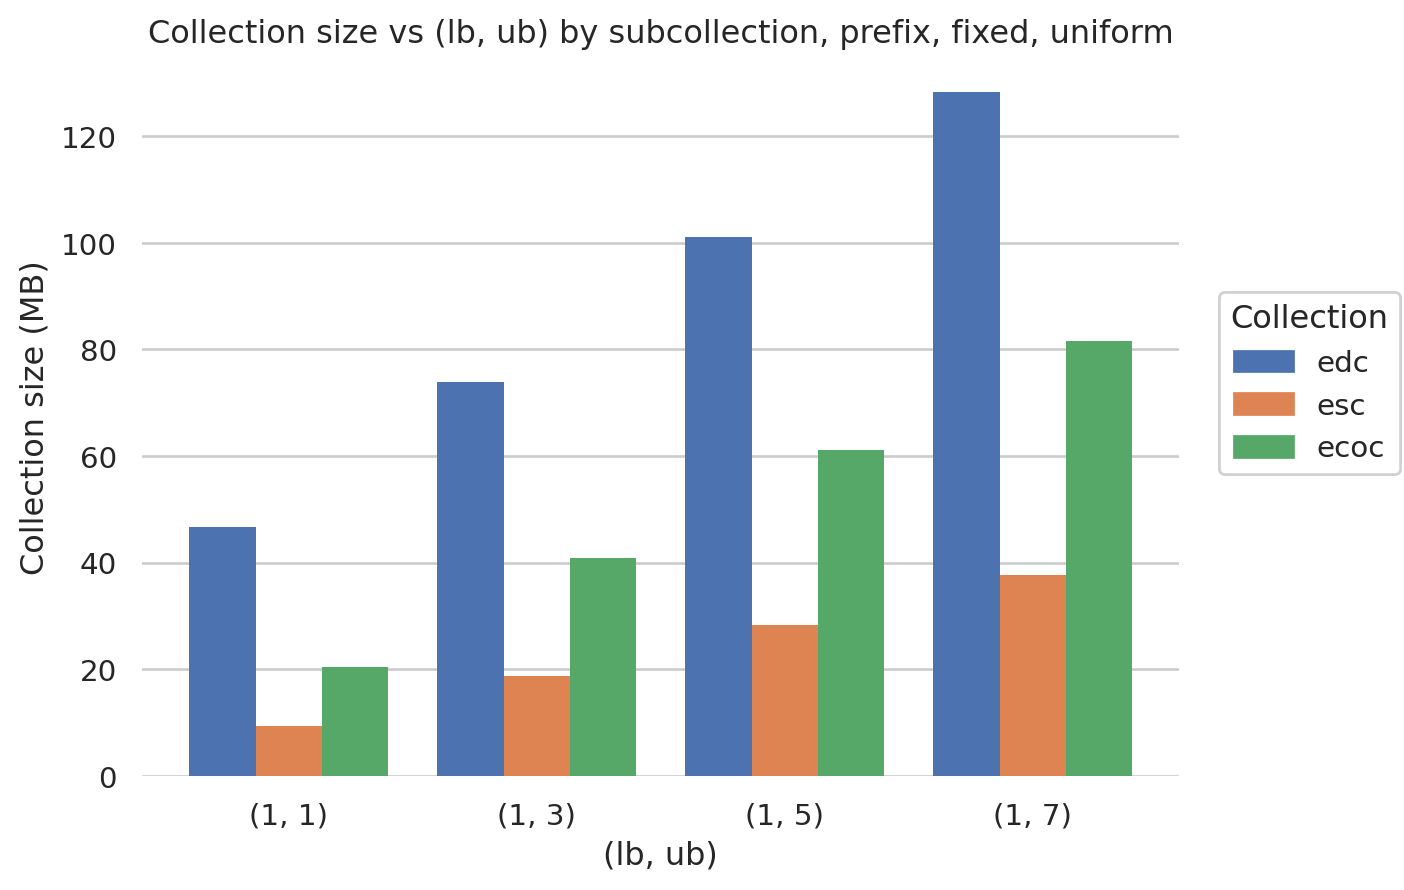

fixed, zipf
    index                                       name   count  failures  \
4     145  experiment11_fixed-zipf-16_e_8_prefix_1_1  100000         0   
5     146  experiment11_fixed-zipf-16_e_8_prefix_1_3  100000         0   
6     147  experiment11_fixed-zipf-16_e_8_prefix_1_5  100000         0   
7     148  experiment11_fixed-zipf-16_e_8_prefix_1_7  100000         0   
20    145  experiment11_fixed-zipf-16_e_8_prefix_1_1  100000         0   
21    146  experiment11_fixed-zipf-16_e_8_prefix_1_3  100000         0   
22    147  experiment11_fixed-zipf-16_e_8_prefix_1_5  100000         0   
23    148  experiment11_fixed-zipf-16_e_8_prefix_1_7  100000         0   
36    145  experiment11_fixed-zipf-16_e_8_prefix_1_1  100000         0   
37    146  experiment11_fixed-zipf-16_e_8_prefix_1_3  100000         0   
38    147  experiment11_fixed-zipf-16_e_8_prefix_1_5  100000         0   
39    148  experiment11_fixed-zipf-16_e_8_prefix_1_7  100000         0   

         lat_avg  lat_min

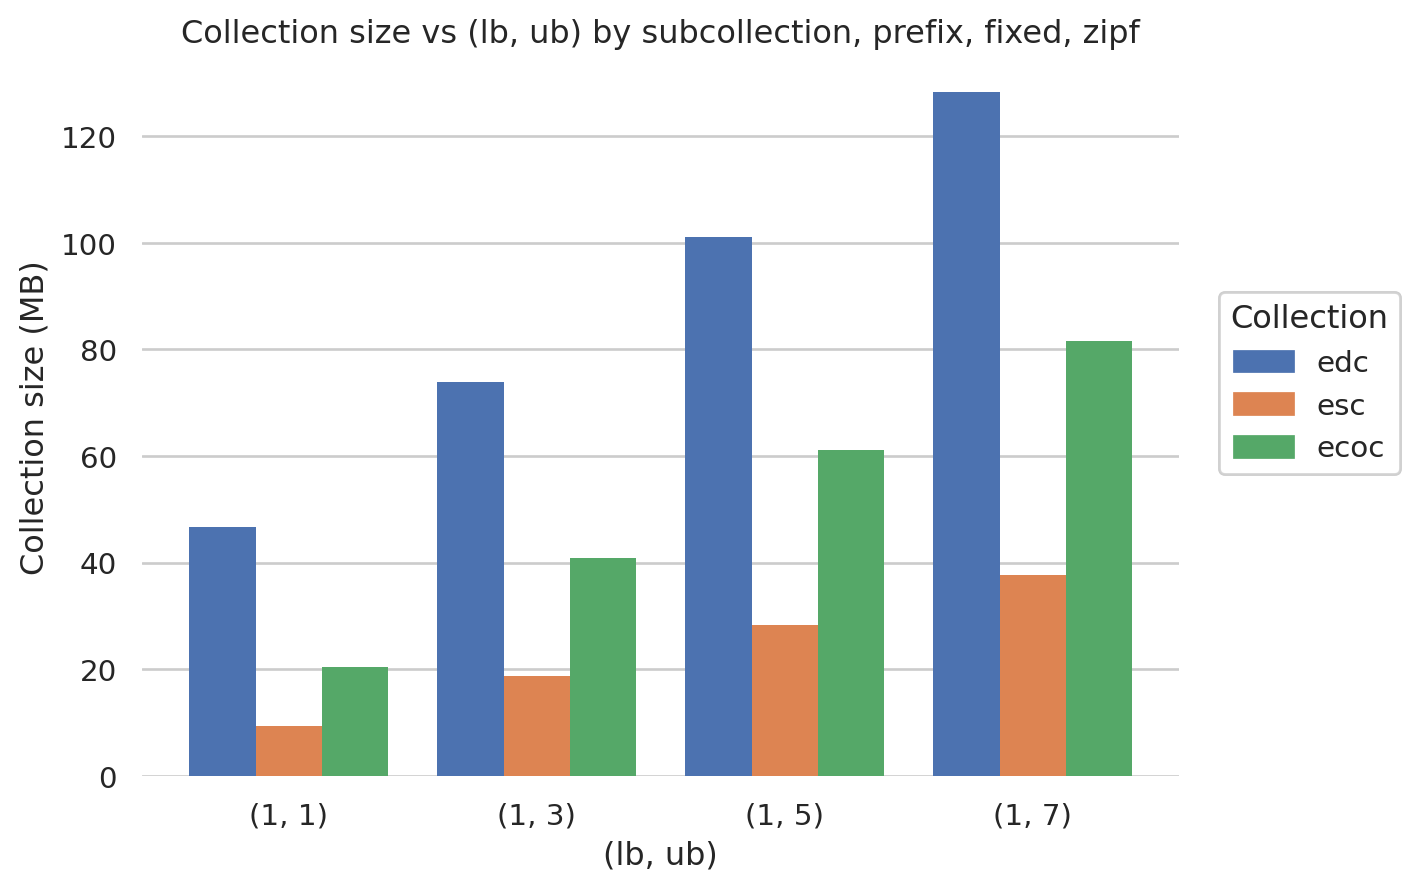

var, uniform
    index                                        name   count  failures  \
8     226  experiment11_var-uniform-16_e_8_prefix_1_1  100000         0   
9     227  experiment11_var-uniform-16_e_8_prefix_1_3  100000         0   
10    228  experiment11_var-uniform-16_e_8_prefix_1_5  100000         0   
11    229  experiment11_var-uniform-16_e_8_prefix_1_7  100000         0   
24    226  experiment11_var-uniform-16_e_8_prefix_1_1  100000         0   
25    227  experiment11_var-uniform-16_e_8_prefix_1_3  100000         0   
26    228  experiment11_var-uniform-16_e_8_prefix_1_5  100000         0   
27    229  experiment11_var-uniform-16_e_8_prefix_1_7  100000         0   
40    226  experiment11_var-uniform-16_e_8_prefix_1_1  100000         0   
41    227  experiment11_var-uniform-16_e_8_prefix_1_3  100000         0   
42    228  experiment11_var-uniform-16_e_8_prefix_1_5  100000         0   
43    229  experiment11_var-uniform-16_e_8_prefix_1_7  100000         0   

         la

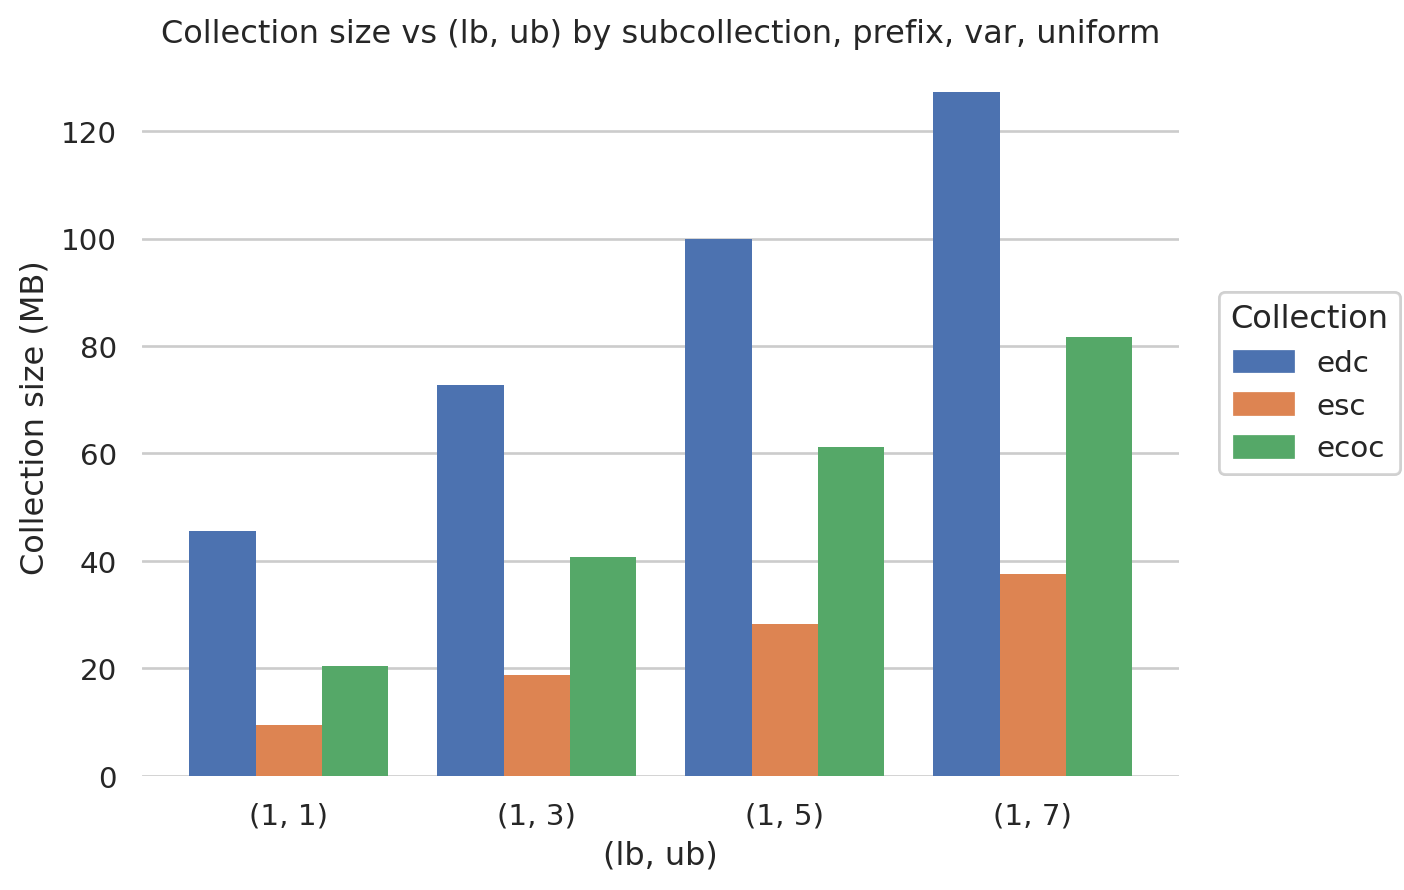

var, zipf
    index                                     name   count  failures  \
12    307  experiment11_var-zipf-16_e_8_prefix_1_1  100000         0   
13    308  experiment11_var-zipf-16_e_8_prefix_1_3  100000         0   
14    309  experiment11_var-zipf-16_e_8_prefix_1_5  100000         0   
15    310  experiment11_var-zipf-16_e_8_prefix_1_7  100000         0   
28    307  experiment11_var-zipf-16_e_8_prefix_1_1  100000         0   
29    308  experiment11_var-zipf-16_e_8_prefix_1_3  100000         0   
30    309  experiment11_var-zipf-16_e_8_prefix_1_5  100000         0   
31    310  experiment11_var-zipf-16_e_8_prefix_1_7  100000         0   
44    307  experiment11_var-zipf-16_e_8_prefix_1_1  100000         0   
45    308  experiment11_var-zipf-16_e_8_prefix_1_3  100000         0   
46    309  experiment11_var-zipf-16_e_8_prefix_1_5  100000         0   
47    310  experiment11_var-zipf-16_e_8_prefix_1_7  100000         0   

         lat_avg  lat_min    lat_max   req_per_s  fai

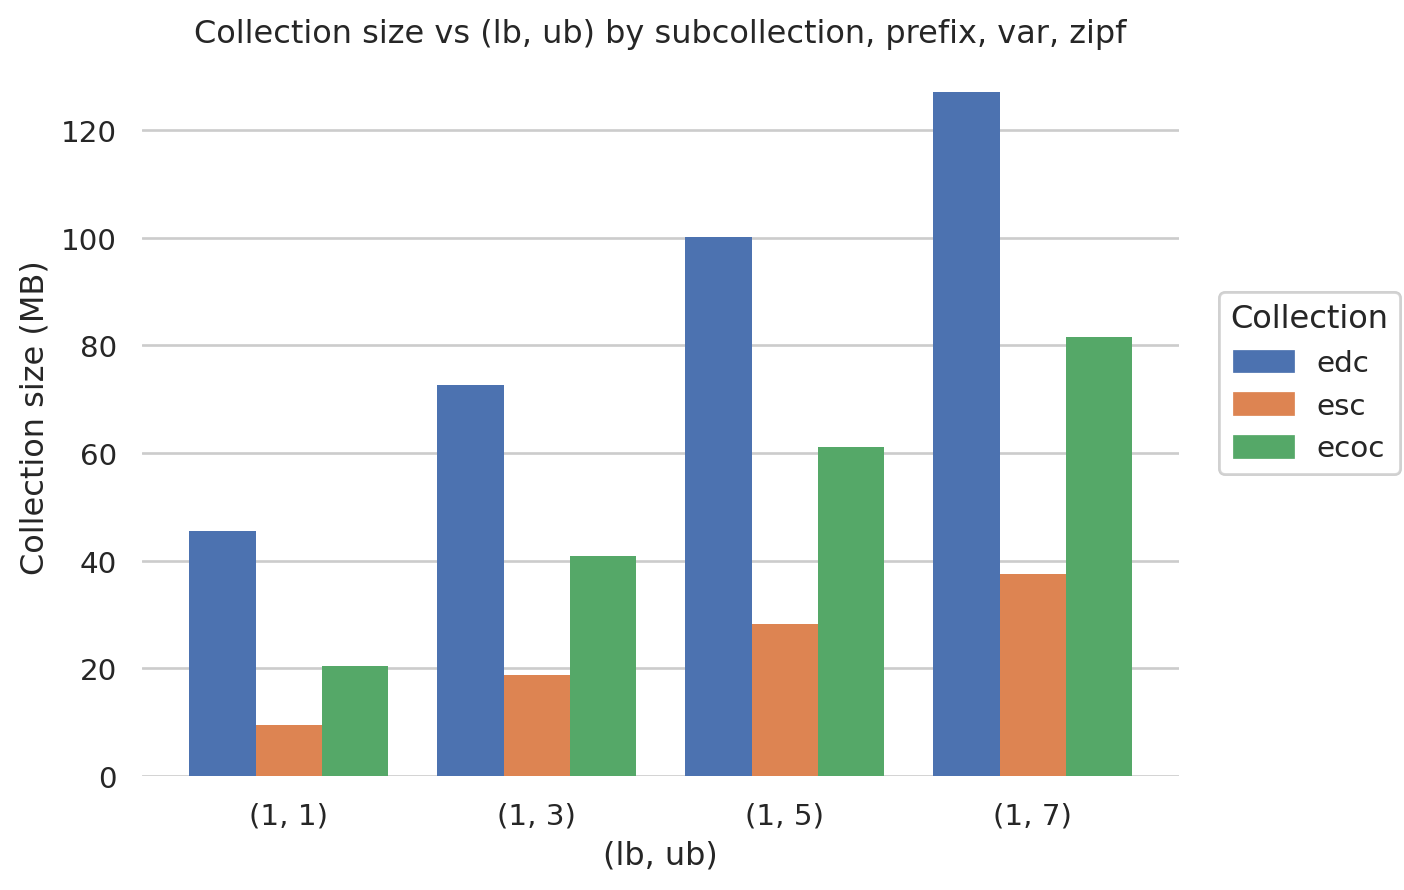

     ub  avg_tag_count        collname
74    3       15.00000  fixed, uniform
75    5       40.00000  fixed, uniform
76    7       61.00000  fixed, uniform
155   3       15.00000     fixed, zipf
156   5       40.00000     fixed, zipf
157   7       61.00000     fixed, zipf
236   3       11.55560    var, uniform
237   5       29.70715    var, uniform
238   7       43.86675    var, uniform
317   3       11.76810       var, zipf
318   5       28.81885       var, zipf
319   7       47.82525       var, zipf
fixed, uniform
    index                                             name   count  failures  \
0      74  experiment11_fixed-uniform-16_e_8_substring_3_3  100000         0   
1      75  experiment11_fixed-uniform-16_e_8_substring_3_5  100000         0   
2      76  experiment11_fixed-uniform-16_e_8_substring_3_7  100000         0   
12     74  experiment11_fixed-uniform-16_e_8_substring_3_3  100000         0   
13     75  experiment11_fixed-uniform-16_e_8_substring_3_5  100000         0  

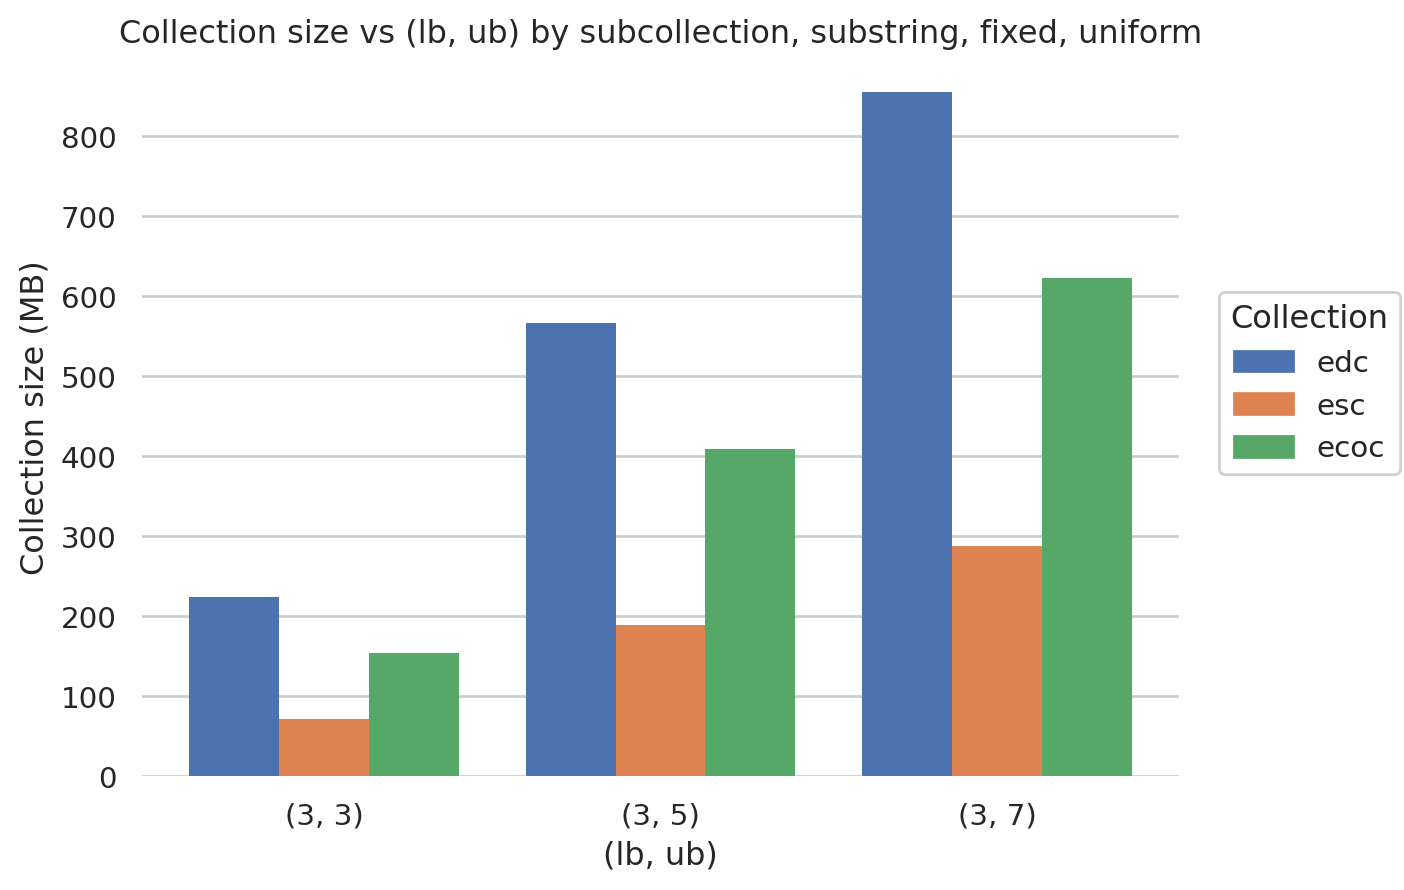

fixed, zipf
    index                                          name   count  failures  \
3     155  experiment11_fixed-zipf-16_e_8_substring_3_3  100000         0   
4     156  experiment11_fixed-zipf-16_e_8_substring_3_5  100000         0   
5     157  experiment11_fixed-zipf-16_e_8_substring_3_7  100000         0   
15    155  experiment11_fixed-zipf-16_e_8_substring_3_3  100000         0   
16    156  experiment11_fixed-zipf-16_e_8_substring_3_5  100000         0   
17    157  experiment11_fixed-zipf-16_e_8_substring_3_7  100000         0   
27    155  experiment11_fixed-zipf-16_e_8_substring_3_3  100000         0   
28    156  experiment11_fixed-zipf-16_e_8_substring_3_5  100000         0   
29    157  experiment11_fixed-zipf-16_e_8_substring_3_7  100000         0   

         lat_avg   lat_min    lat_max   req_per_s  fail_per_s     lat50  ...  \
3   7.581505e+06   4818422  241767657  670.529907         0.0   7338000  ...   
4   1.161524e+07   8324461  221366570  648.970237        

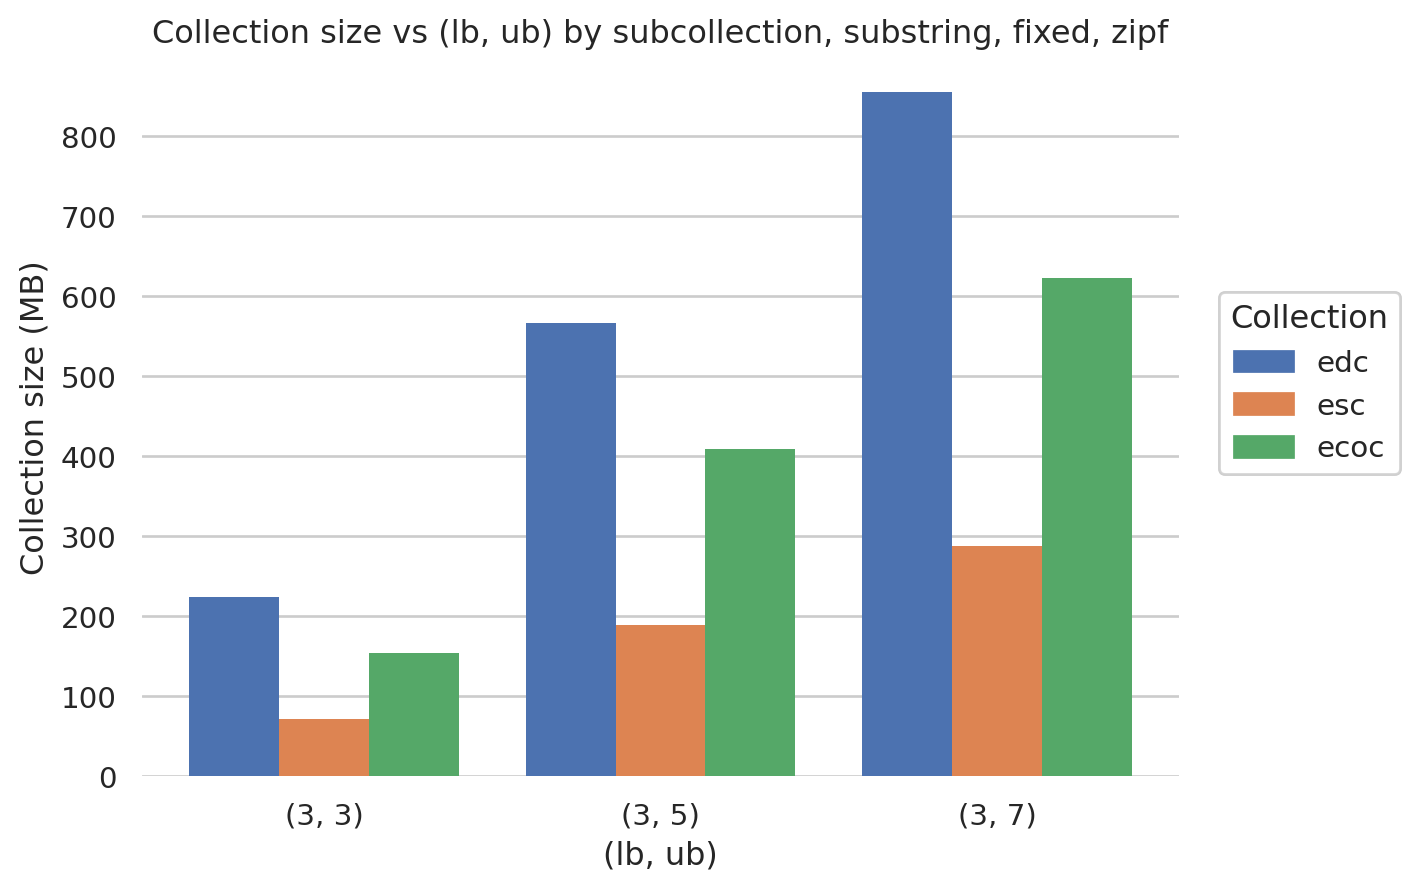

var, uniform
    index                                           name   count  failures  \
6     236  experiment11_var-uniform-16_e_8_substring_3_3  100000         0   
7     237  experiment11_var-uniform-16_e_8_substring_3_5  100000         0   
8     238  experiment11_var-uniform-16_e_8_substring_3_7  100000         0   
18    236  experiment11_var-uniform-16_e_8_substring_3_3  100000         0   
19    237  experiment11_var-uniform-16_e_8_substring_3_5  100000         0   
20    238  experiment11_var-uniform-16_e_8_substring_3_7  100000         0   
30    236  experiment11_var-uniform-16_e_8_substring_3_3  100000         0   
31    237  experiment11_var-uniform-16_e_8_substring_3_5  100000         0   
32    238  experiment11_var-uniform-16_e_8_substring_3_7  100000         0   

         lat_avg  lat_min    lat_max   req_per_s  fail_per_s     lat50  ...  \
6   6.529722e+06  3843482  219543485  661.785656         0.0   6269000  ...   
7   8.689550e+06  5356500  235186075  656.175282

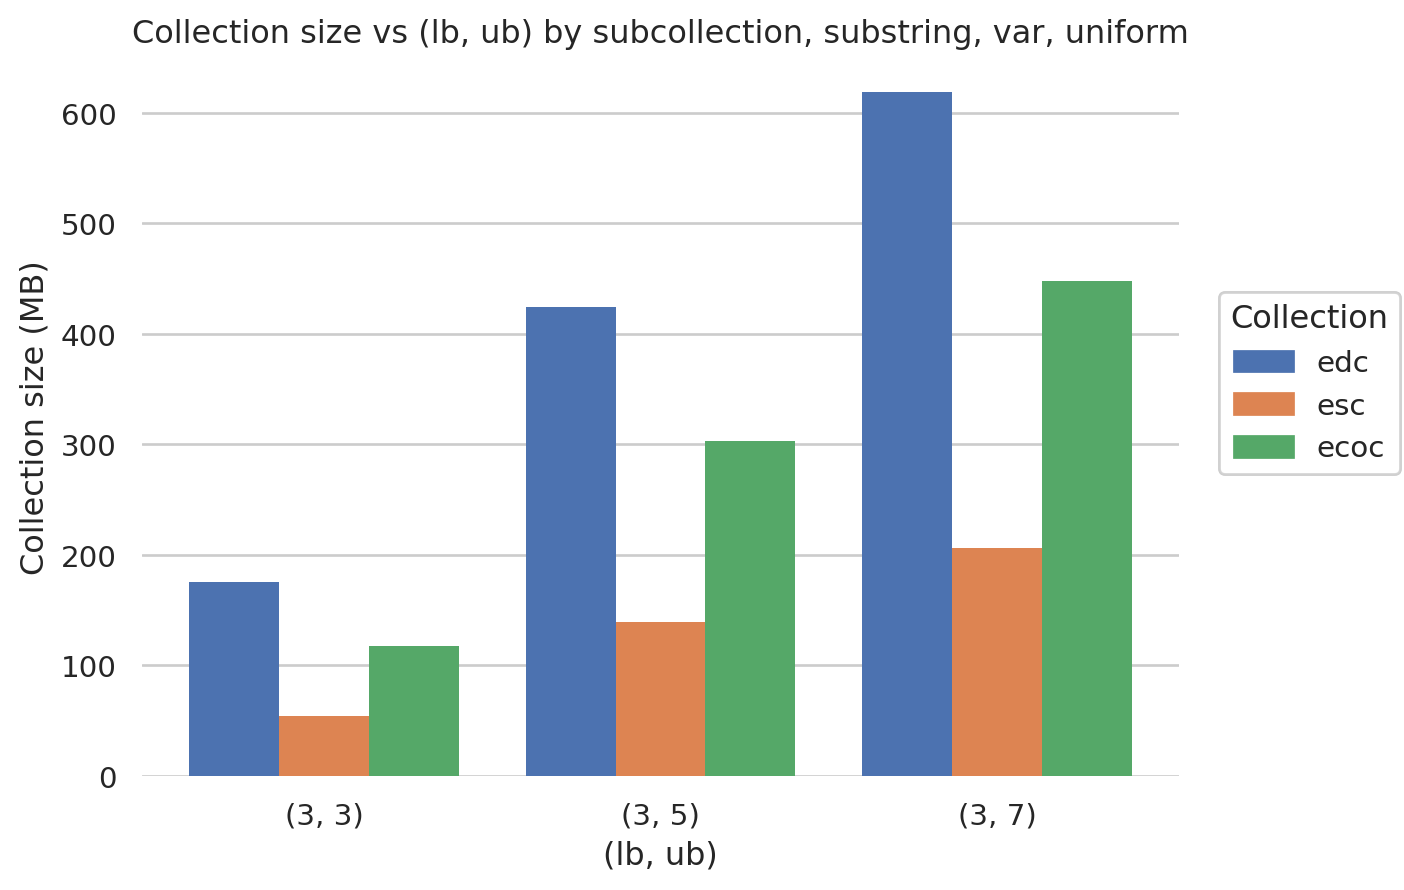

var, zipf
    index                                        name   count  failures  \
9     317  experiment11_var-zipf-16_e_8_substring_3_3  100000         0   
10    318  experiment11_var-zipf-16_e_8_substring_3_5  100000         0   
11    319  experiment11_var-zipf-16_e_8_substring_3_7  100000         0   
21    317  experiment11_var-zipf-16_e_8_substring_3_3  100000         0   
22    318  experiment11_var-zipf-16_e_8_substring_3_5  100000         0   
23    319  experiment11_var-zipf-16_e_8_substring_3_7  100000         0   
33    317  experiment11_var-zipf-16_e_8_substring_3_3  100000         0   
34    318  experiment11_var-zipf-16_e_8_substring_3_5  100000         0   
35    319  experiment11_var-zipf-16_e_8_substring_3_7  100000         0   

         lat_avg  lat_min    lat_max   req_per_s  fail_per_s     lat50  ...  \
9   7.011893e+06  4163003  238549547  666.271903         0.0   6793000  ...   
10  9.084627e+06  5494456  250520112  667.206593         0.0   8617000  ...   
11

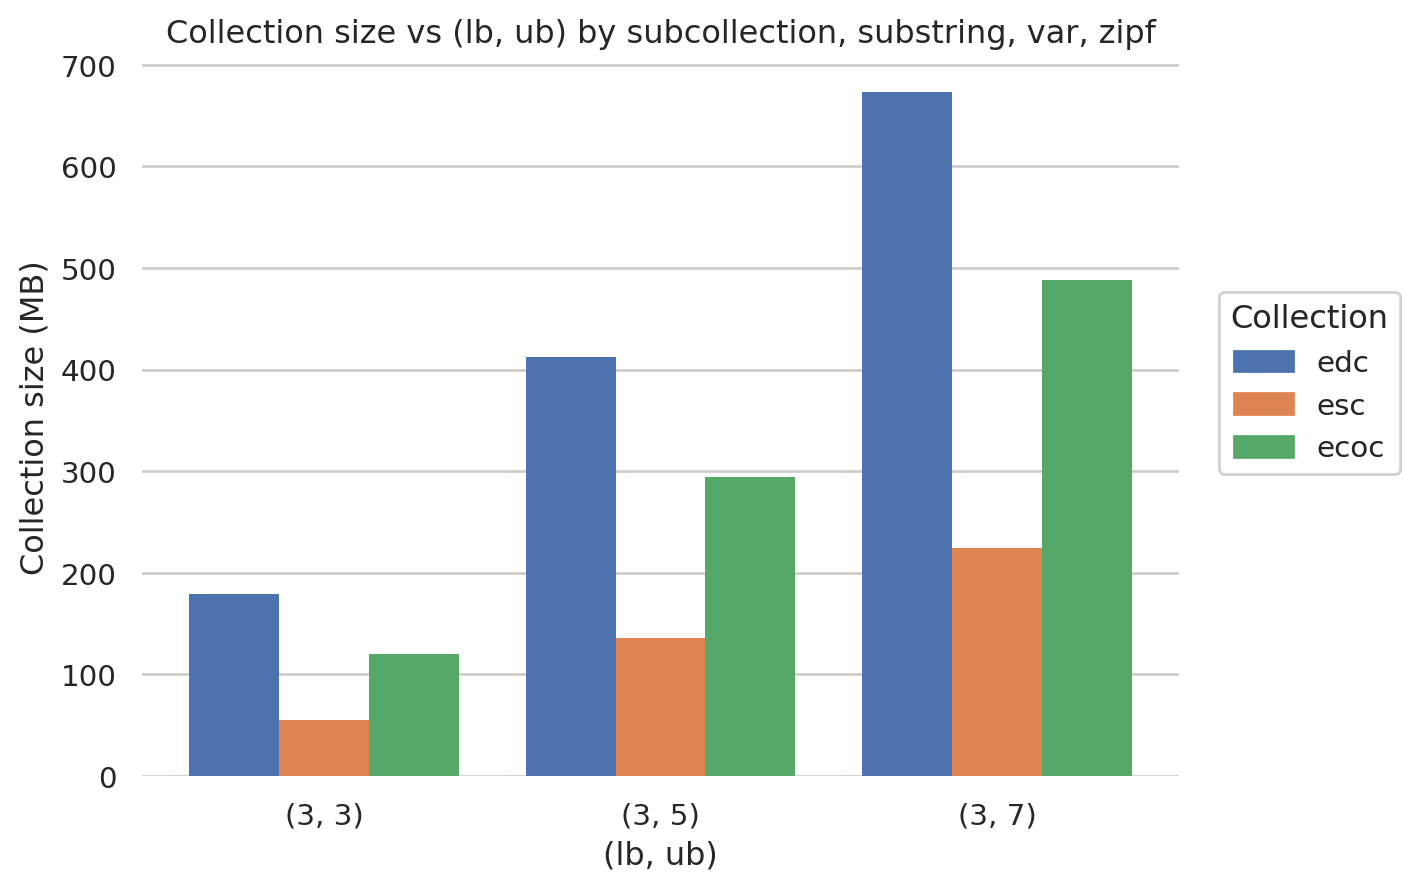

In [273]:
# Graph 3
for typ in ('prefix', 'substring'):
    lowest_lb = 1 if typ == 'prefix' else 3
    stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['cf'] == 8) & (enc_stats['lb'] == lowest_lb)].copy()

    
    stats['avg_tag_count'] = stats['esc_count'] / stats['edc_count']
    stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
    print(stats[['ub', 'avg_tag_count', 'collname']])
    stackstat = None
    for coll in ('edc', 'esc', 'ecoc'):
        cpy = stats.copy()
        cpy['whichcoll'] = [coll] * len(cpy)
        cpy['coll_data_size'] = cpy[coll + '_data_size'] / 1000000
        if stackstat is None:
            stackstat = cpy
        else:
            stackstat = pd.concat([stackstat, cpy])

    stackstat = stackstat.reset_index()
    
    # print(stackstat)

    for collname in stackstat['collname'].unique():
        title = f'Collection size vs (lb, ub) by subcollection, {typ}, {collname}'
        print(collname)
        substat = stackstat[stackstat['collname'] == collname]
        print(substat)
        plt.close()
        ax = plt.gca()
        p = so.Plot(data=substat, x='ub', y='coll_data_size', color='whichcoll')
        p = p.add(so.Bar(alpha=1), so.Dodge())
        p = p.label(title=title, x='(lb, ub)', y='Collection size (MB)', color='Collection')
        p = p.theme(sns.axes_style(style='whitegrid'))
        p = p.layout(engine='tight')
        p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
        p = p.on(ax)
        sns.despine(ax=ax, left=True, bottom=True)
        ax.grid(False, axis='x')

        p.save(f"../figures/graph3-{typ}-{collname.split(', ')[0]}-{collname.split(', ')[1]}.png", bbox_inches='tight')
        display(p)
        plt.close()
    
    # g = sns.catplot(data=stats, kind='bar', x='window_size', y='edc_data_size_mb', col='lb', sharex=False, hue='lb')
    # g.set(title=title, xlabel='Window size', ylabel='EDC size (MB)')
    # g.despine(left=True)

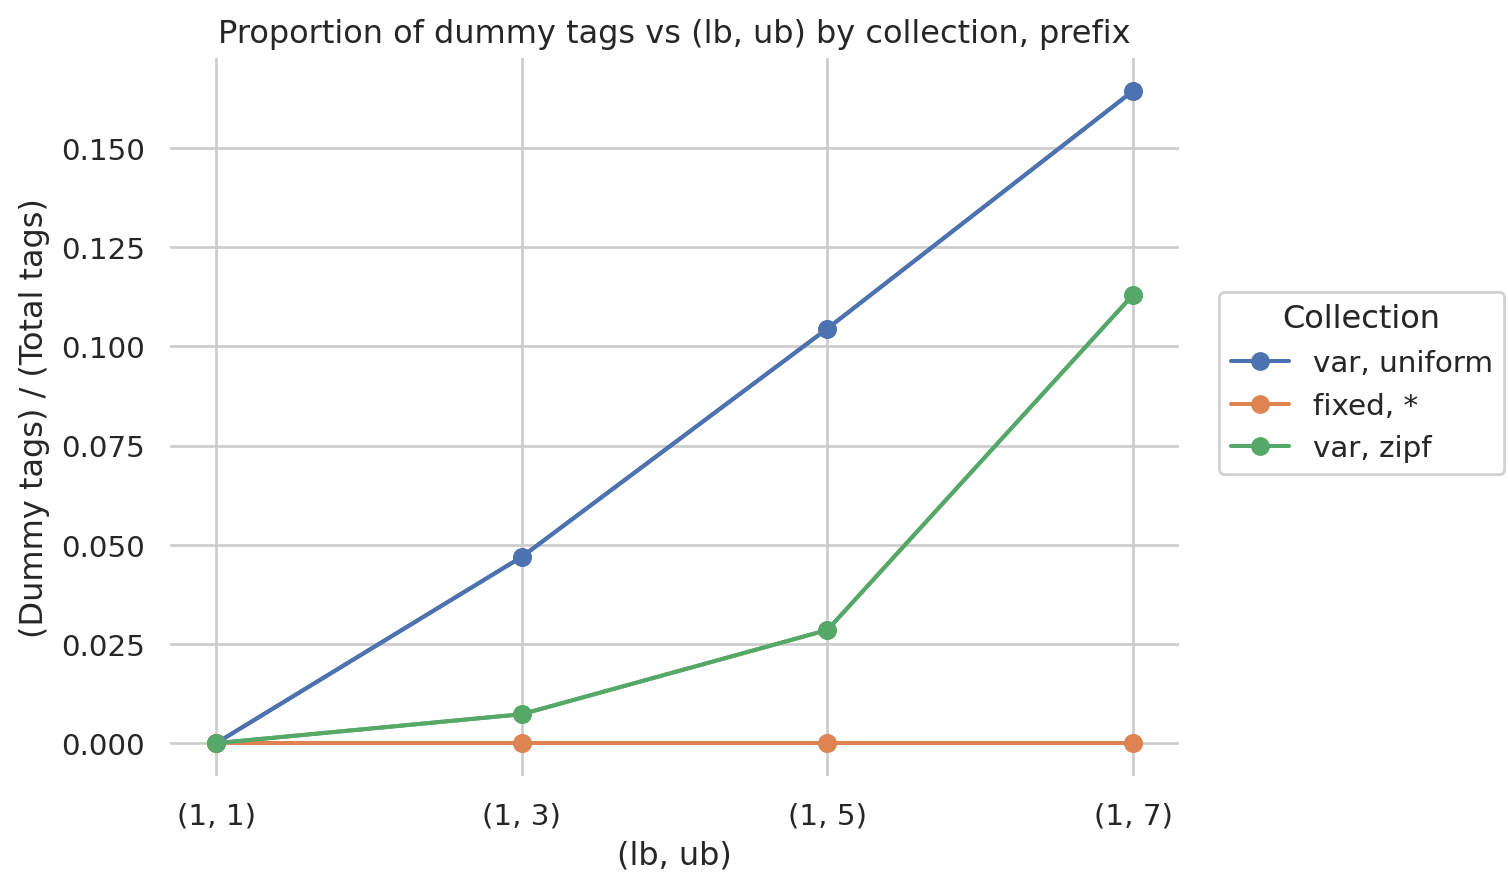

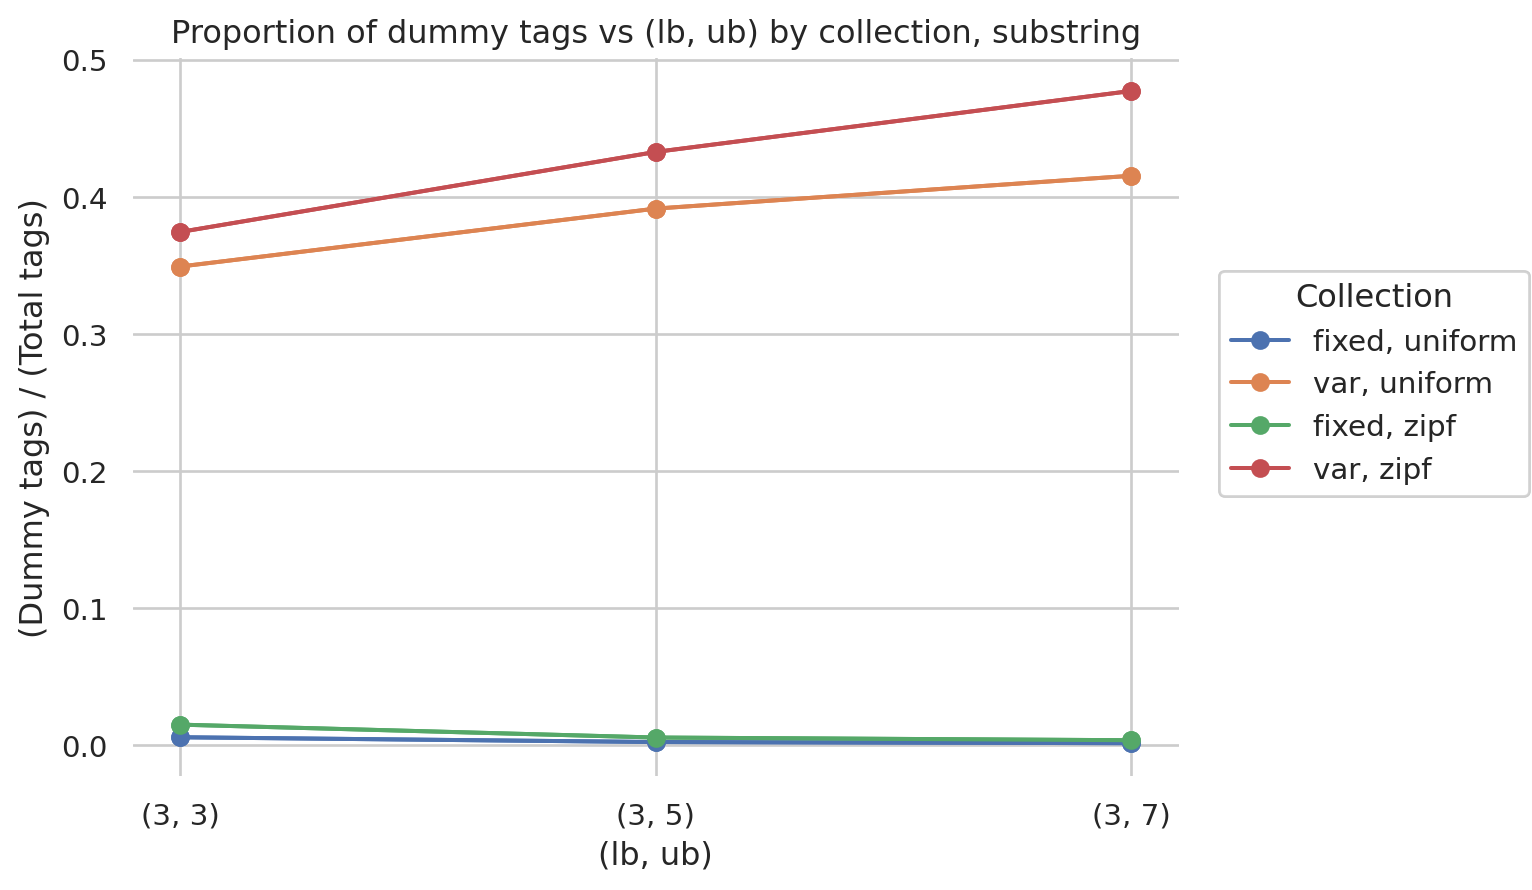

In [274]:
# Graph 4
for typ in ('prefix', 'substring'):
    lowest_lb = 1 if typ == 'prefix' else 3
    stats = mydata[(mydata['itype'] == typ) & (mydata['lb'] == lowest_lb) & (mydata['colltype'].map(lambda c: c.endswith('-16')))].copy()

    title = f'Proportion of dummy tags vs (lb, ub) by collection, {typ}'
    stats['collname'] = stats['colltype'].map(lambda s: s[:-3].replace('-', ', '))
    stats['ratio'] = stats['ndummy'] / stats['ntotal']
    if typ == 'prefix':
        stats = stats[stats['collname'] != 'fixed, uniform']
        stats['collname'] = stats['collname'].replace('fixed, zipf', 'fixed, *')
    plt.close()
    ax = plt.gca()
    p = so.Plot(stats, x='ub', y='ratio', color='collname')
    p = p.add(so.Line(alpha=1, marker='o'))
    p = p.label(title=title, x='(lb, ub)', y='(Dummy tags) / (Total tags)', color='Collection')
    p = p.theme(sns.axes_style(style='whitegrid'))
    p = p.layout(engine='tight')
    p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
    p = p.on(ax)
    sns.despine(ax=ax, left=True, bottom=True)
    # ax.grid(False, axis='x')

    p.save(f'../figures/graph4-{typ}.png', bbox_inches='tight')
    display(p)
    plt.close()
    

80     7385088
161    6983680
242    7184384
323    7131136
Name: edc_total_size, dtype: int64
64      62492672
65      88911872
66     154488832
67     225865728
145     51015680
146     94576640
147    129110016
148    212103168
226     55156736
227    103858176
228    152244224
229    194633728
307     43130880
308     94339072
309    107380736
310    177569792
Name: edc_total_size, dtype: int64


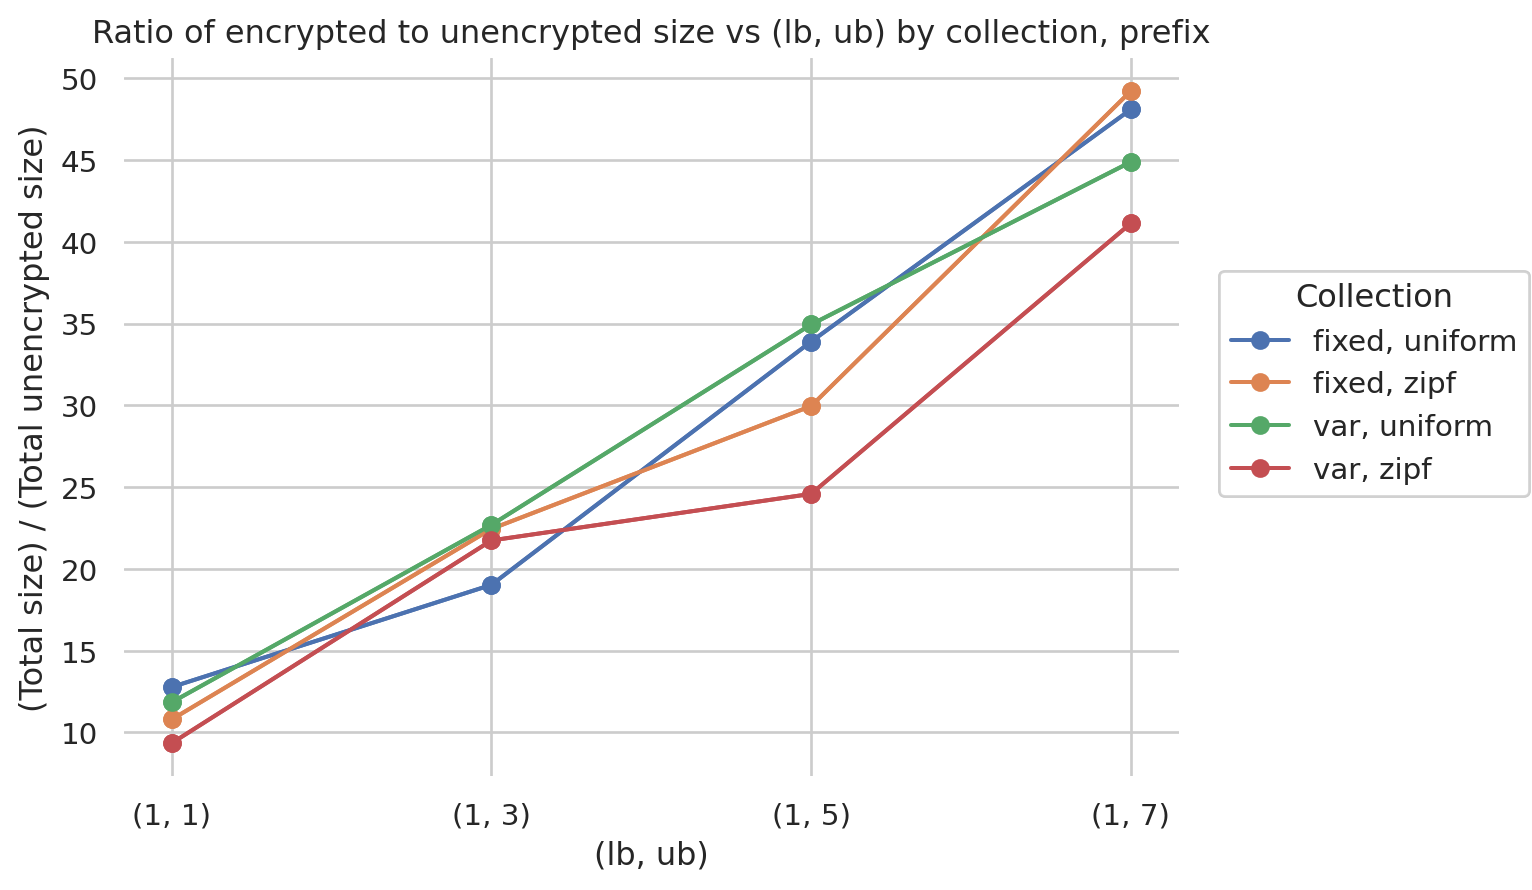

80     7385088
161    6983680
242    7184384
323    7131136
Name: edc_total_size, dtype: int64
74      308457472
75     1023586304
76     1438109696
155     390467584
156     935084032
157    1539846144
236     302551040
237     662544384
238    1102786560
317     236269568
318     650973184
319    1203224576
Name: edc_total_size, dtype: int64


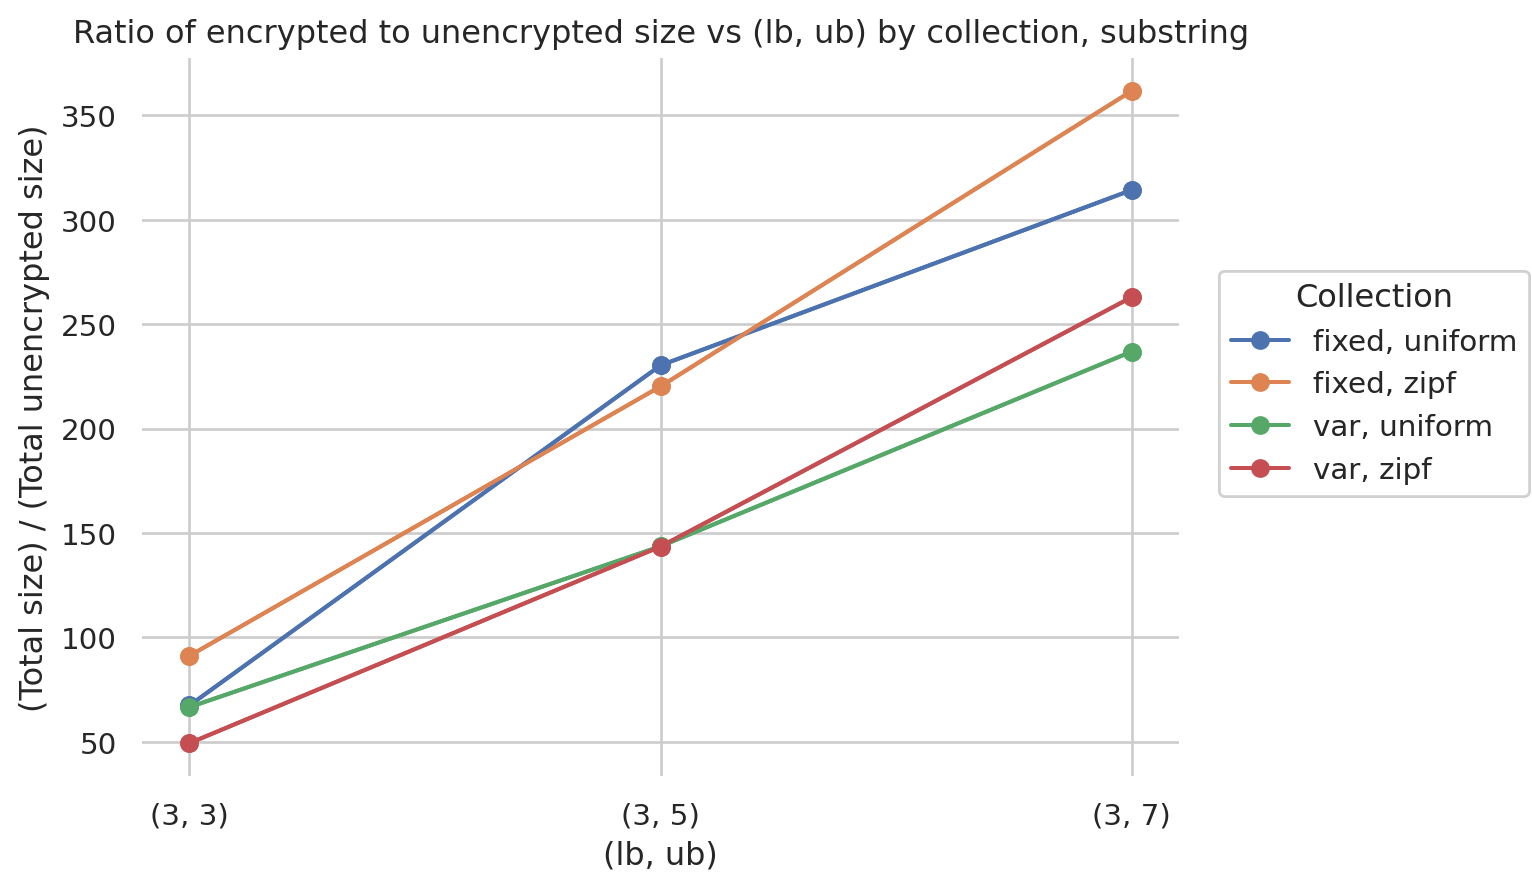

In [278]:
# Graph 5
for typ in ('prefix', 'substring'):
    lowest_lb = 1 if typ == 'prefix' else 3
    stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['cf'] == 8) & (enc_stats['lb'] == lowest_lb)].copy()

    title = f'Ratio of encrypted to unencrypted size vs (lb, ub) by collection, {typ}'
    stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
    sub_unenc_stats = unenc_stats.copy()
    sub_unenc_stats['collname'] = sub_unenc_stats['var_or_fixed'] + ', ' + sub_unenc_stats['zipf_or_uniform']
    print(sub_unenc_stats['edc_total_size'])
    print(stats['edc_total_size'])
    stats['ratio'] = stats.apply(lambda row: (row['edc_total_size'] + row['esc_total_size'] + row['ecoc_total_size']) / sub_unenc_stats[sub_unenc_stats['collname'] == row['collname']]['edc_total_size'].mean(), axis=1)
    # print(stats[['ub', 'avg_tag_count', 'collname']])
    # if typ == 'prefix':
    #     stats = stats[stats['collname'] == 'fixed, uniform']
    #     stats['collname'] = '*'
    # else:
    #     stats = stats[stats['collname'] != 'fixed, uniform']
    #     stats['collname'] = stats['collname'].replace('fixed, zipf', 'fixed, *')
    plt.close()
    ax = plt.gca()
    p = so.Plot(stats, x='ub', y='ratio', color='collname')
    p = p.add(so.Line(alpha=1, marker='o'))
    p = p.label(title=title, x='(lb, ub)', y='(Total size) / (Total unencrypted size)', color='Collection')
    p = p.theme(sns.axes_style(style='whitegrid'))
    p = p.layout(engine='tight')
    p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
    p = p.on(ax)
    sns.despine(ax=ax, left=True, bottom=True)
    # ax.grid(False, axis='x')

    p.save(f'../figures/graph5-{typ}.png', bbox_inches='tight')
    display(p)
    plt.close()
    
    # g = sns.catplot(data=stats, kind='bar', x='window_size', y='edc_data_size_mb', col='lb', sharex=False, hue='lb')
    # g.set(title=title, xlabel='Window size', ylabel='EDC size (MB)')
    # g.despine(left=True)


            colltype   itype  lb  ub   nreal  ndummy  ntotal
64  fixed-uniform-32  prefix   1   1  200000       0  200000
65  fixed-uniform-32  prefix   1   3  400000       0  400000
66  fixed-uniform-32  prefix   1   5  600000       0  600000
67  fixed-uniform-32  prefix   1   7  800000       0  800000
80    var-uniform-32  prefix   1   1  200000       0  200000
81    var-uniform-32  prefix   1   3  390522    9478  400000
82    var-uniform-32  prefix   1   5  568569   31431  600000
83    var-uniform-32  prefix   1   7  734011   65989  800000


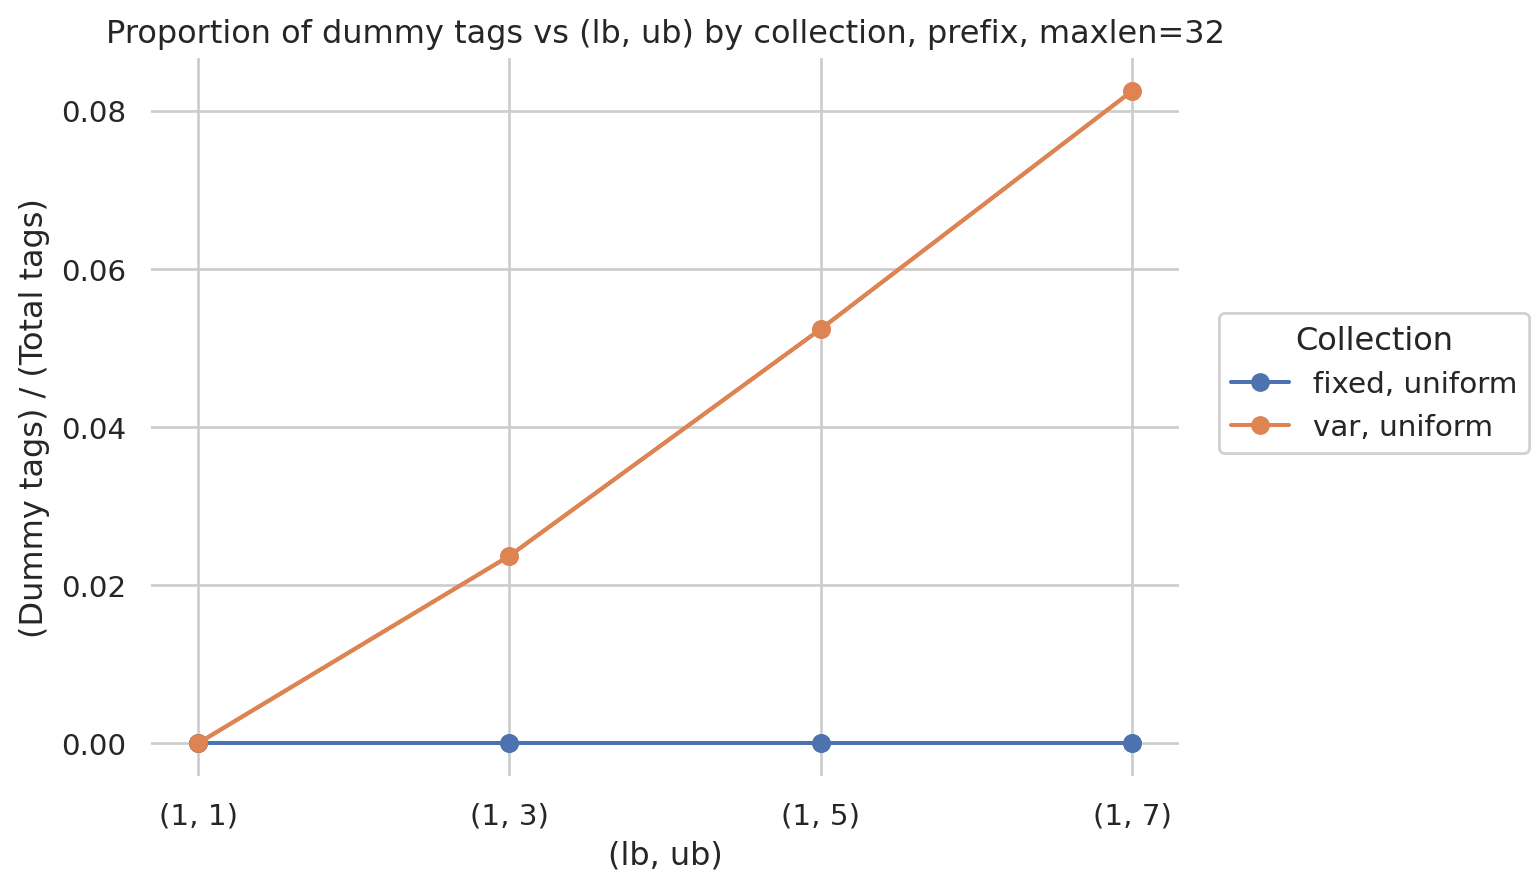

            colltype      itype  lb  ub     nreal   ndummy    ntotal
74  fixed-uniform-32  substring   3   3   3057239    42761   3100000
75  fixed-uniform-32  substring   3   5   8752887    47113   8800000
76  fixed-uniform-32  substring   3   7  14052858    47142  14100000
90    var-uniform-32  substring   3   3   1538411   588745   2127156
91    var-uniform-32  substring   3   5   4163624  1717844   5881468
92    var-uniform-32  substring   3   7   6440438  2795342   9235780


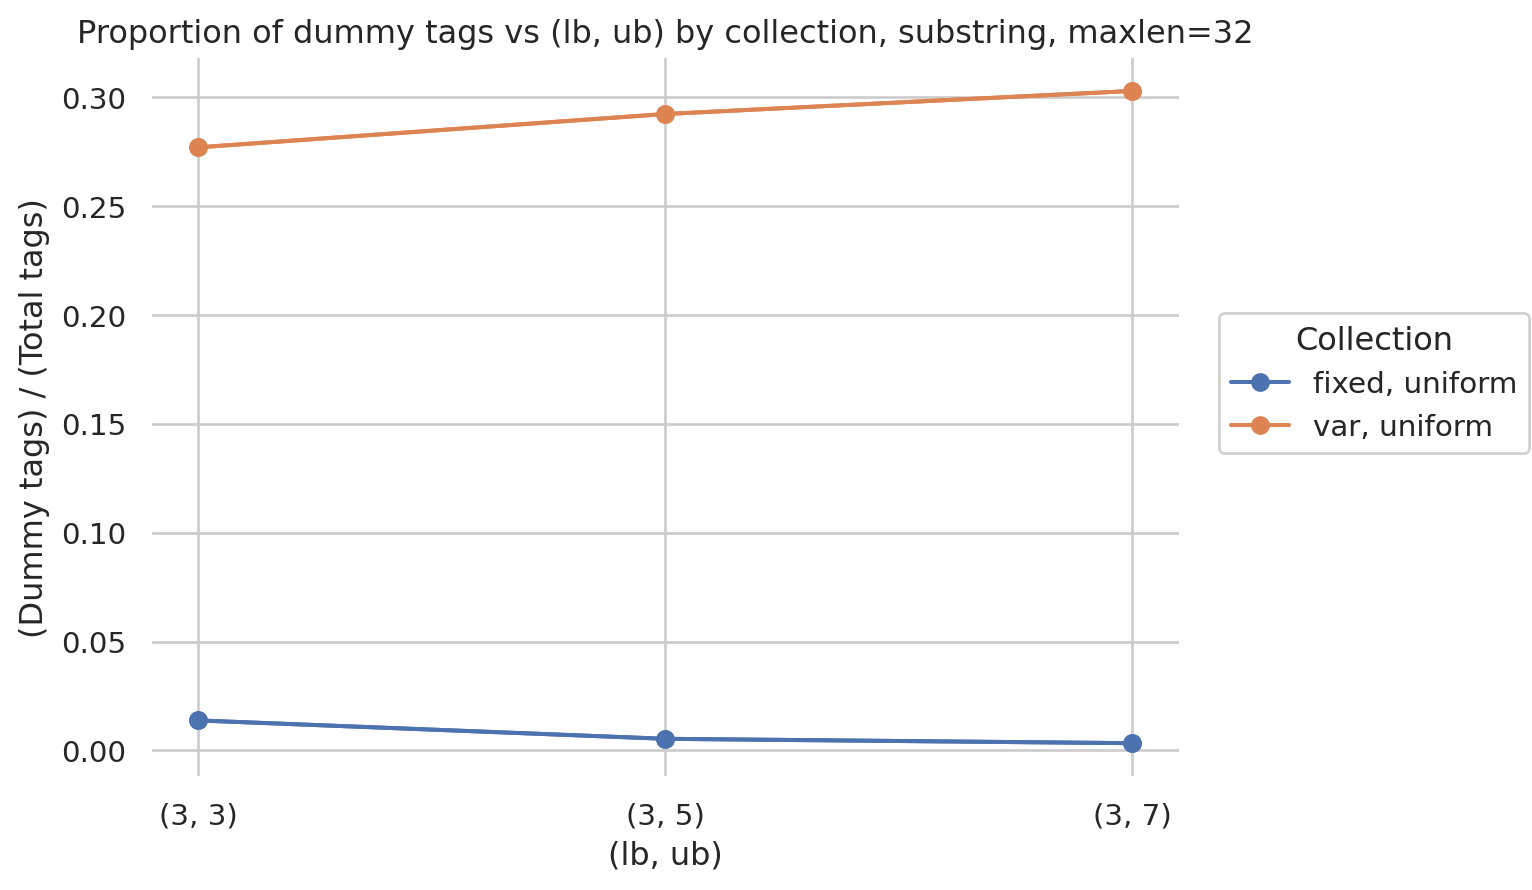

In [279]:
# Graph 6
for typ in ('prefix', 'substring'):
    lowest_lb = 1 if typ == 'prefix' else 3
    stats = mydata[(mydata['itype'] == typ) & (mydata['lb'] == lowest_lb) & (mydata['colltype'].map(lambda s: s.endswith('-32')))].copy()
    print(stats)
    title = f'Proportion of dummy tags vs (lb, ub) by collection, {typ}, maxlen=32'
    stats['collname'] = stats['colltype'].map(lambda s: s[:-3].replace('-', ', '))
    stats['ratio'] = stats['ndummy'] / stats['ntotal']
    # if typ == 'prefix':
    #     stats = stats[stats['collname'] != 'fixed, uniform']
    #     stats['collname'] = stats['collname'].replace('fixed, zipf', 'fixed, *')
    plt.close()
    ax = plt.gca()
    p = so.Plot(stats, x='ub', y='ratio', color='collname')
    p = p.add(so.Line(alpha=1, marker='o'))
    p = p.label(title=title, x='(lb, ub)', y='(Dummy tags) / (Total tags)', color='Collection')
    p = p.theme(sns.axes_style(style='whitegrid'))
    p = p.layout(engine='tight')
    p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
    p = p.on(ax)
    sns.despine(ax=ax, left=True, bottom=True)
    # ax.grid(False, axis='x')

    p.save(f'../figures/graph6-{typ}.png', bbox_inches='tight')
    display(p)
    plt.close()
    

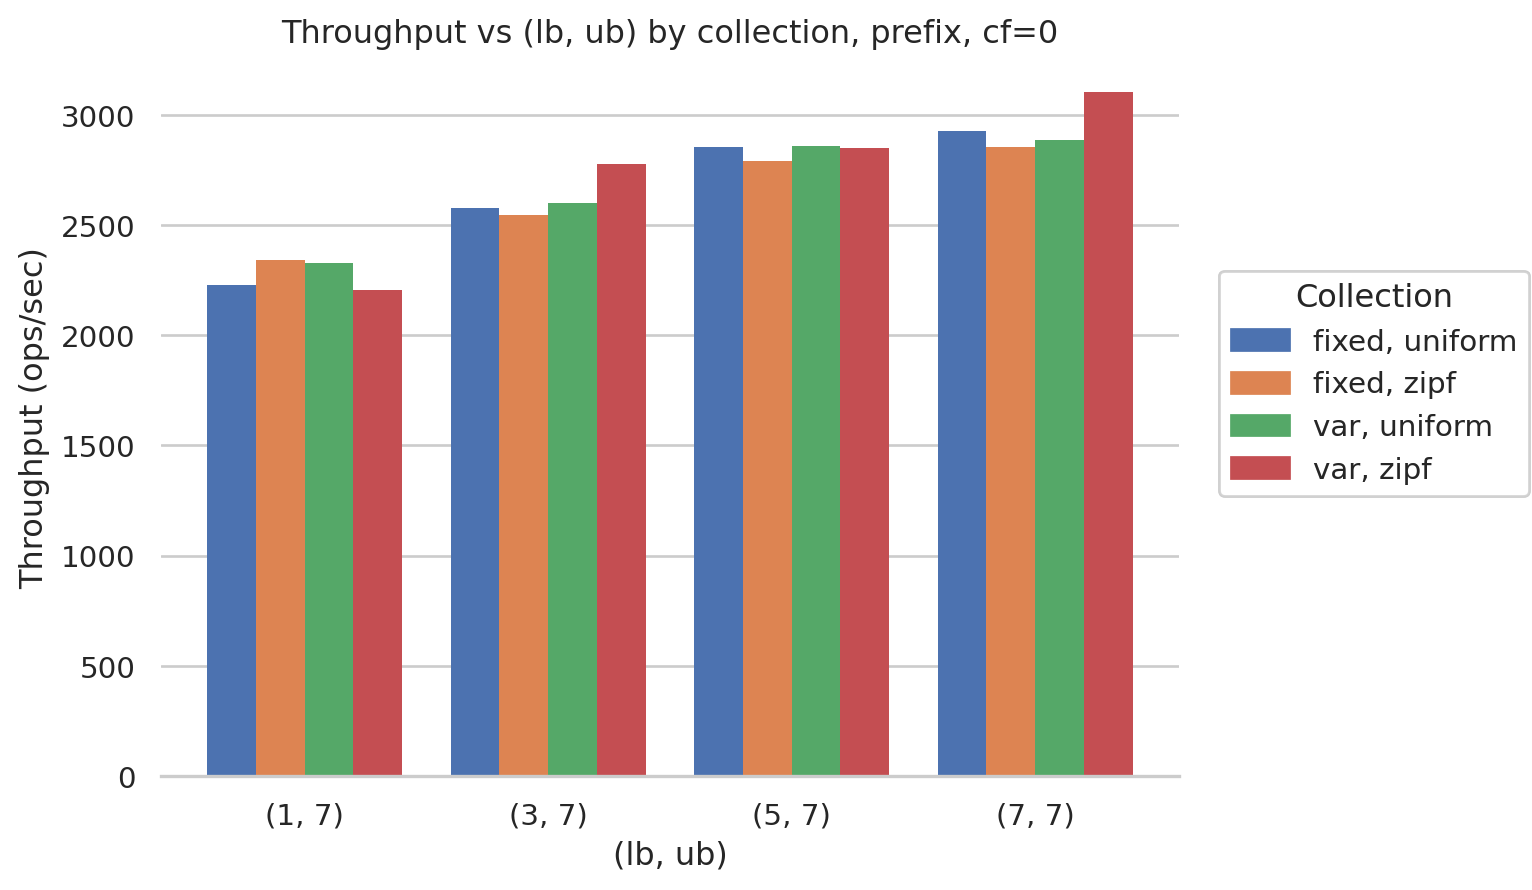

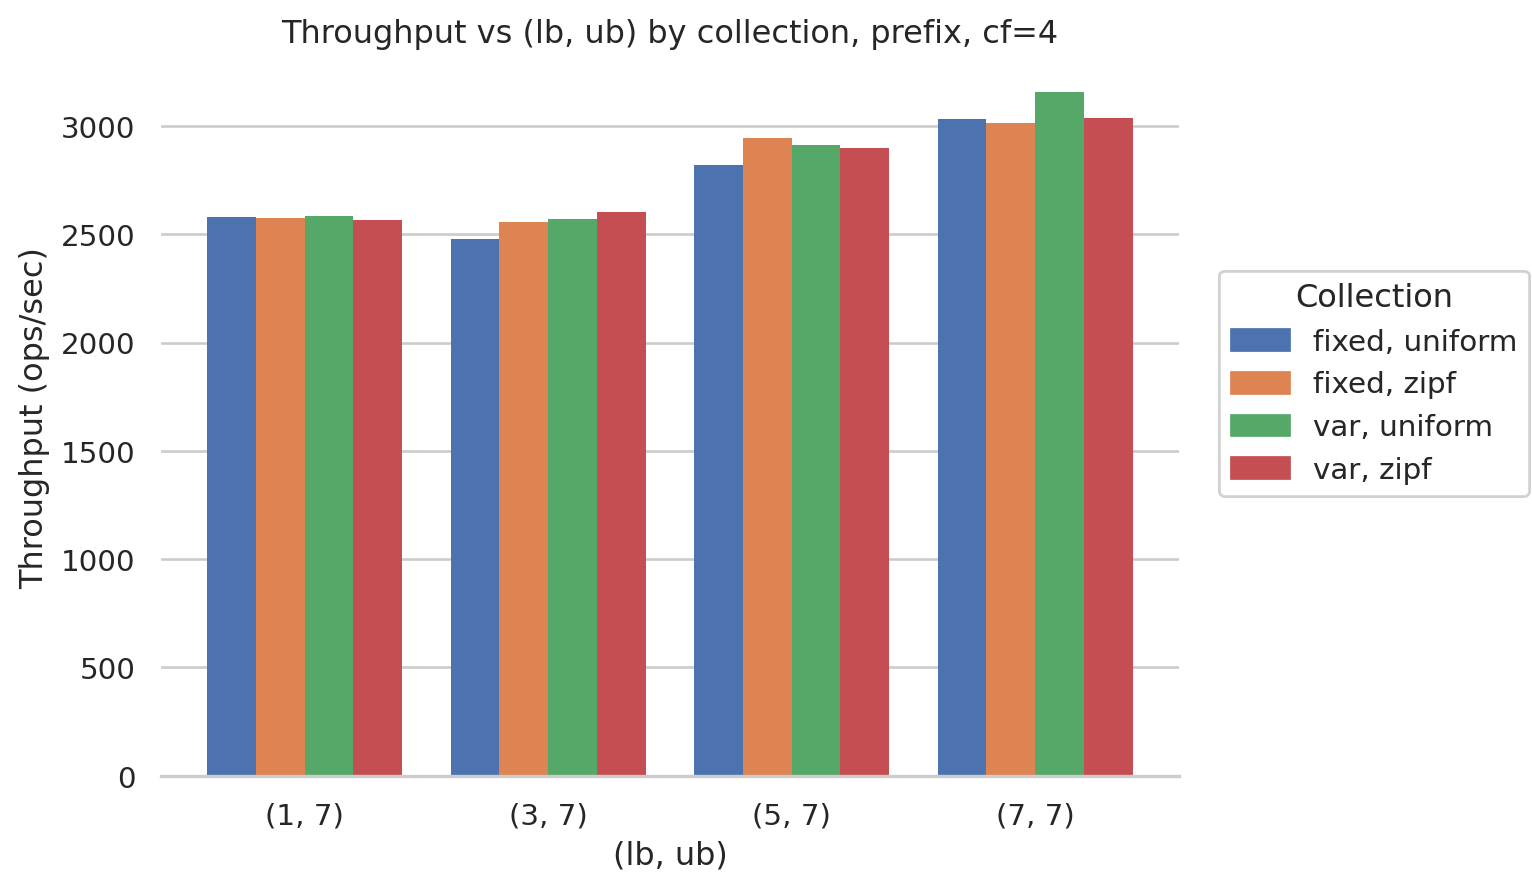

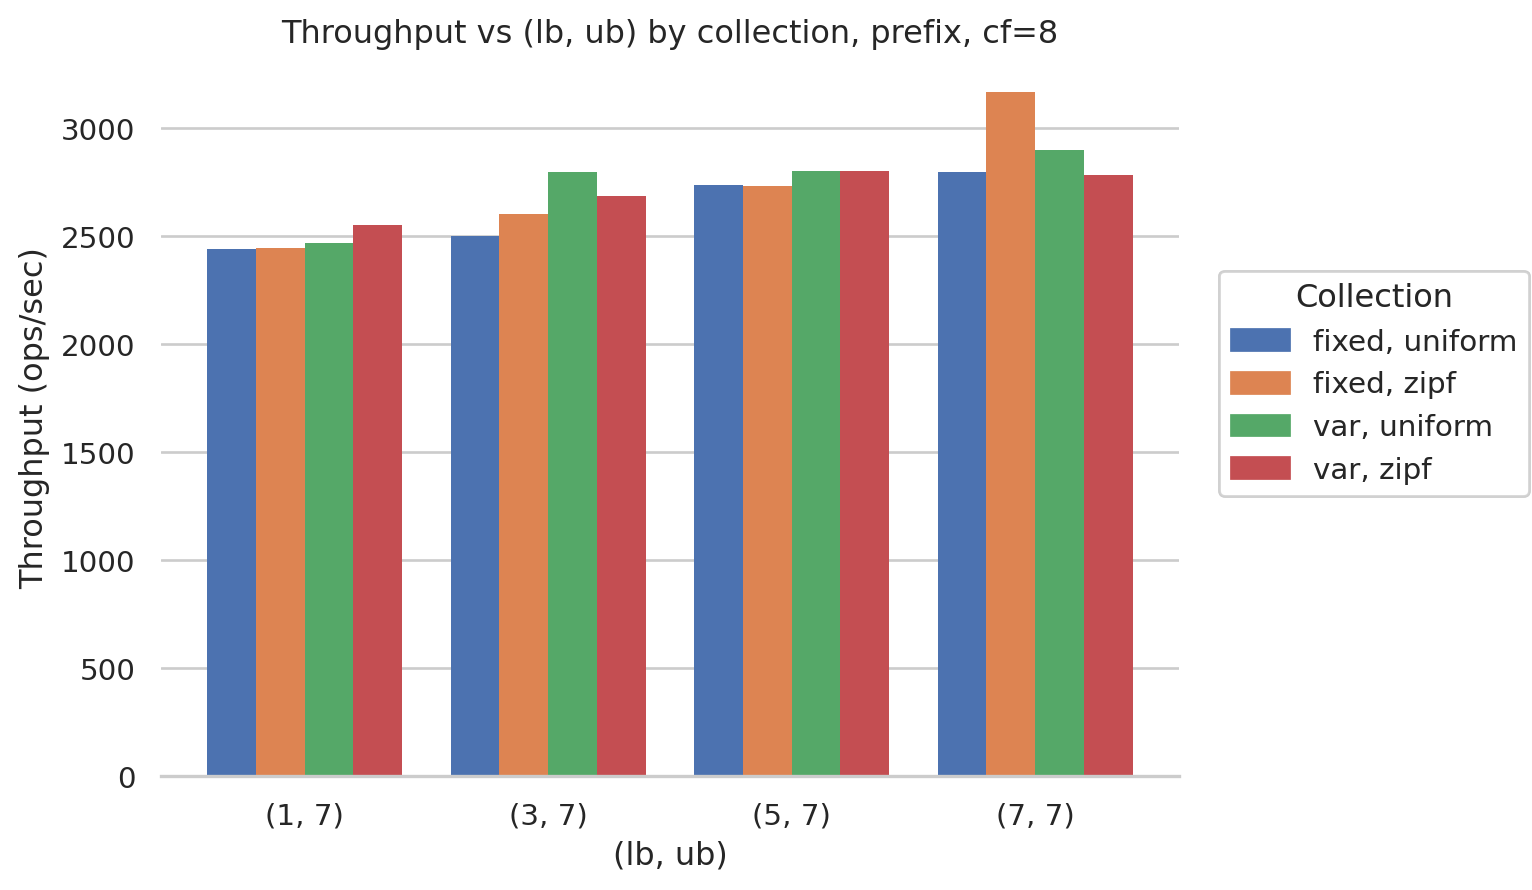

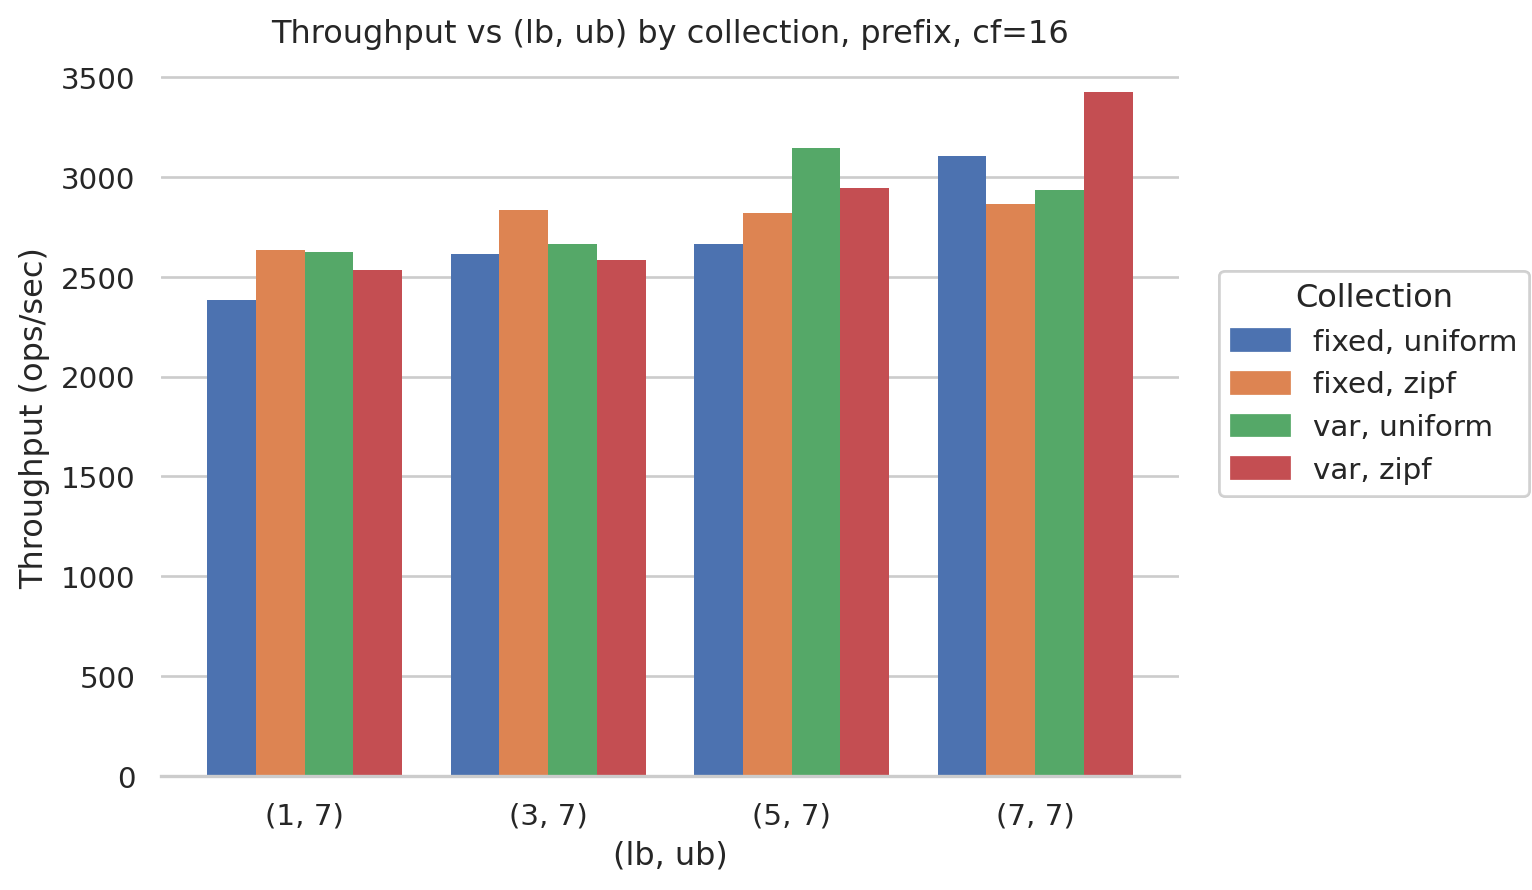

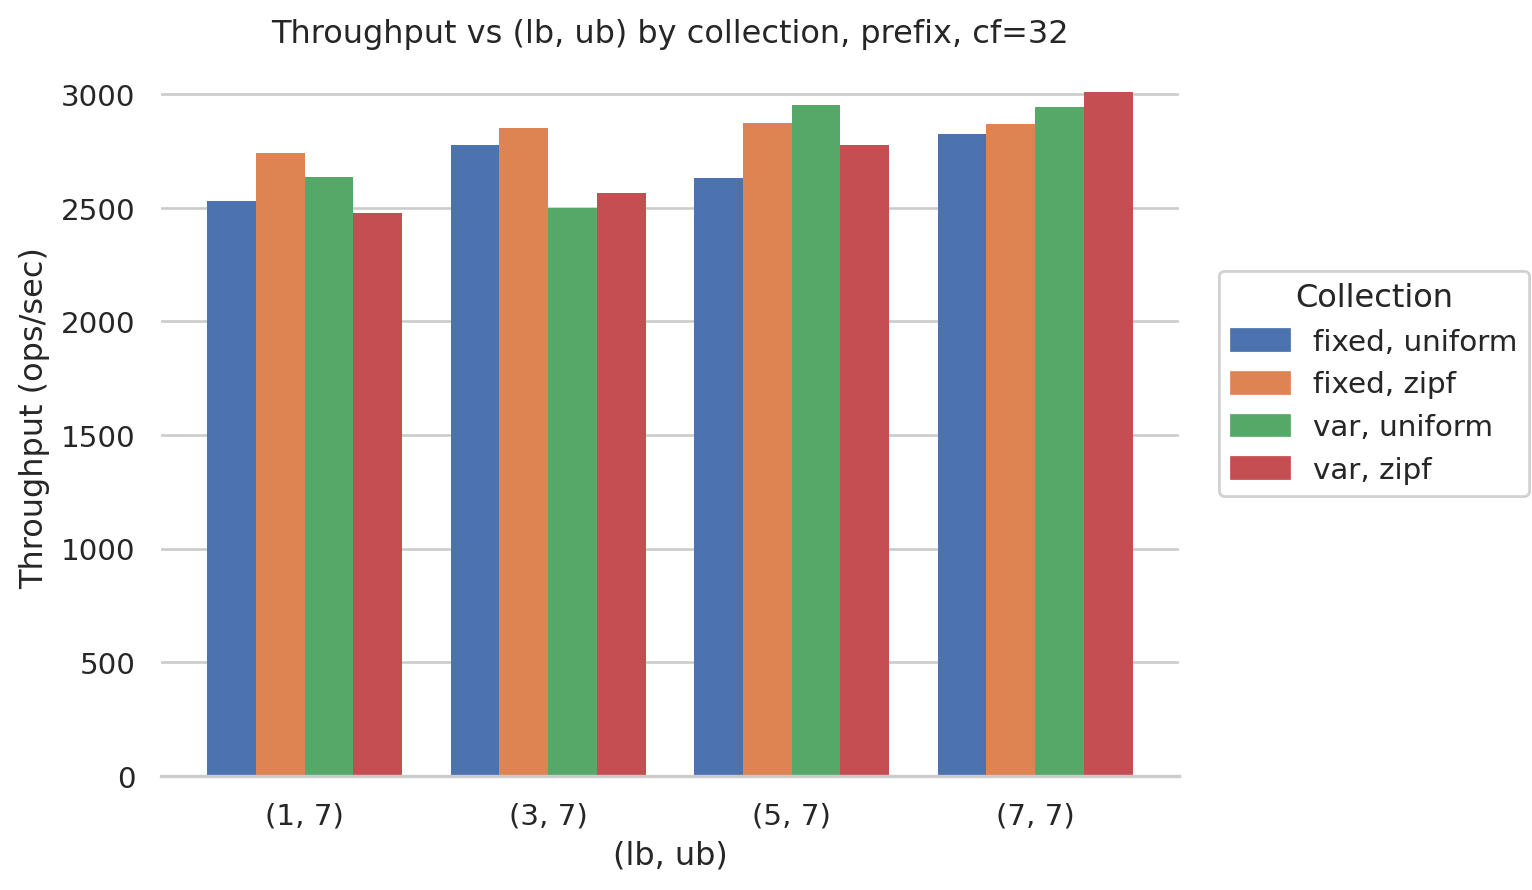

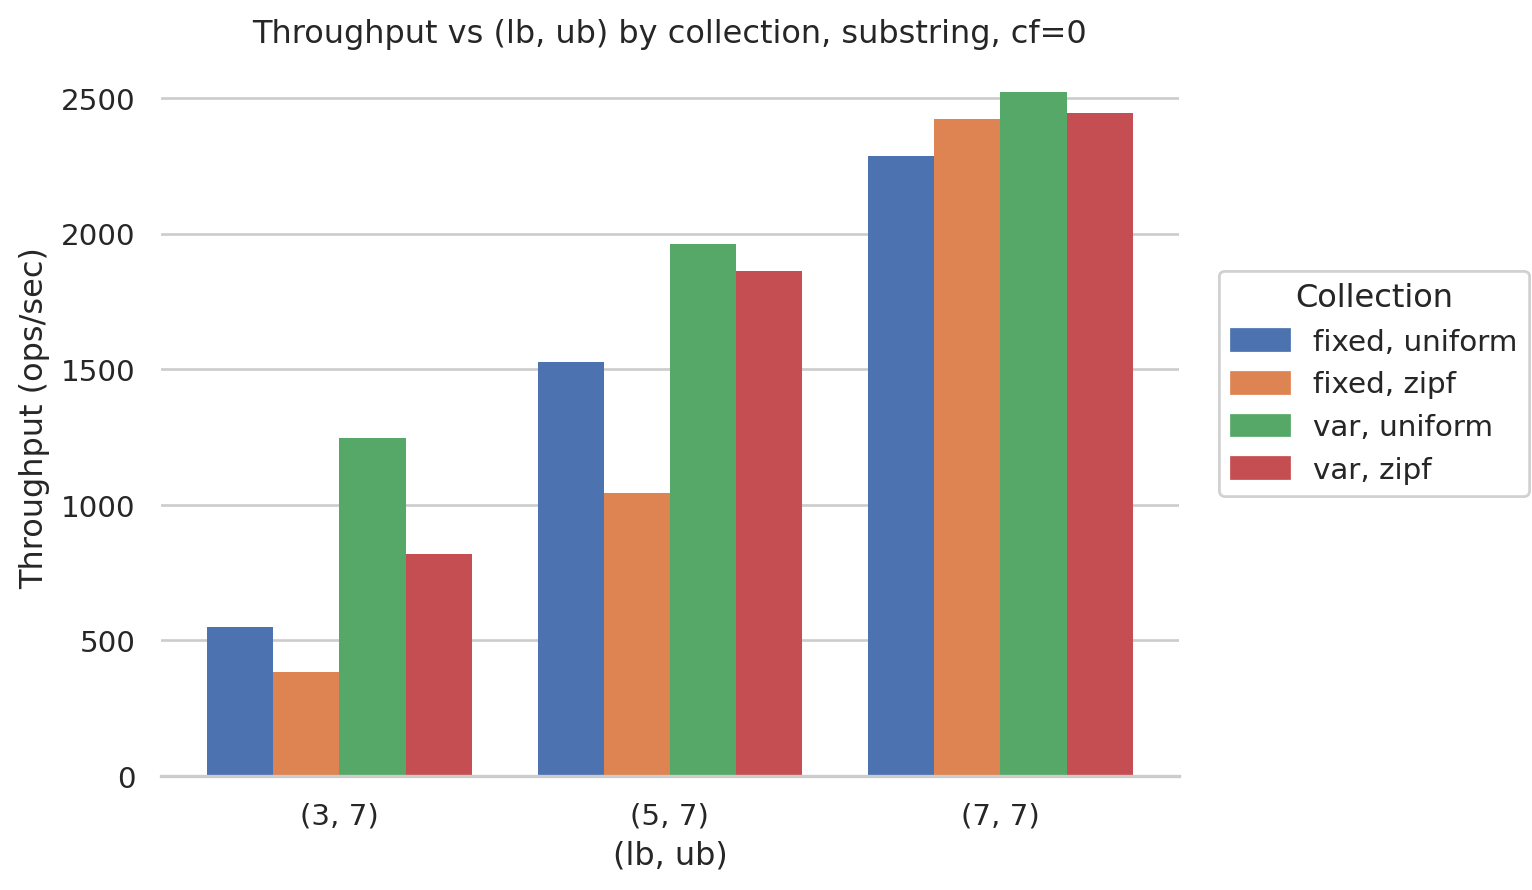

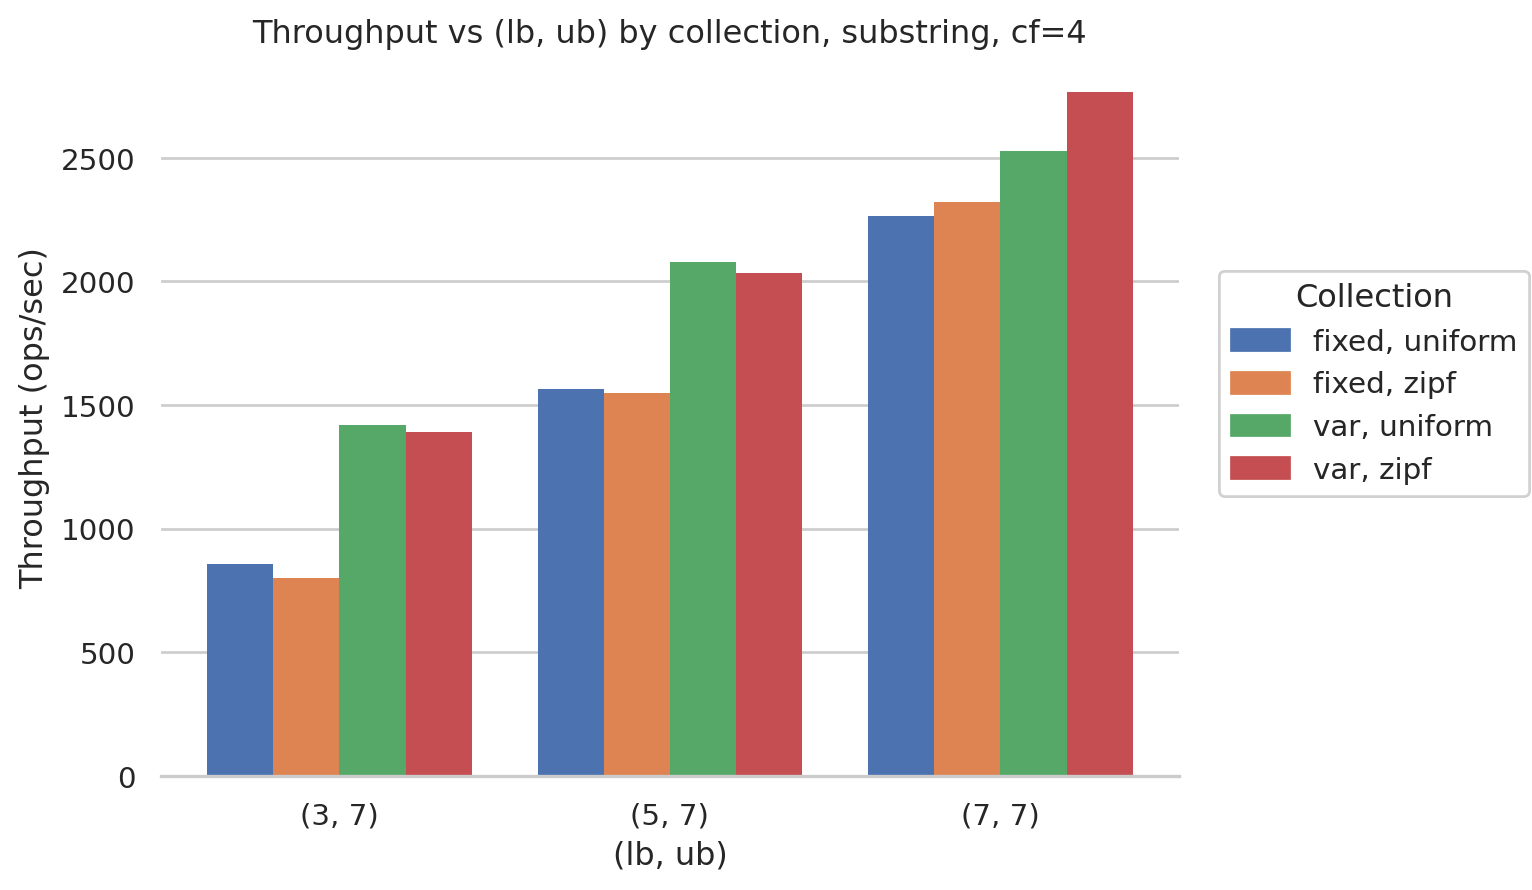

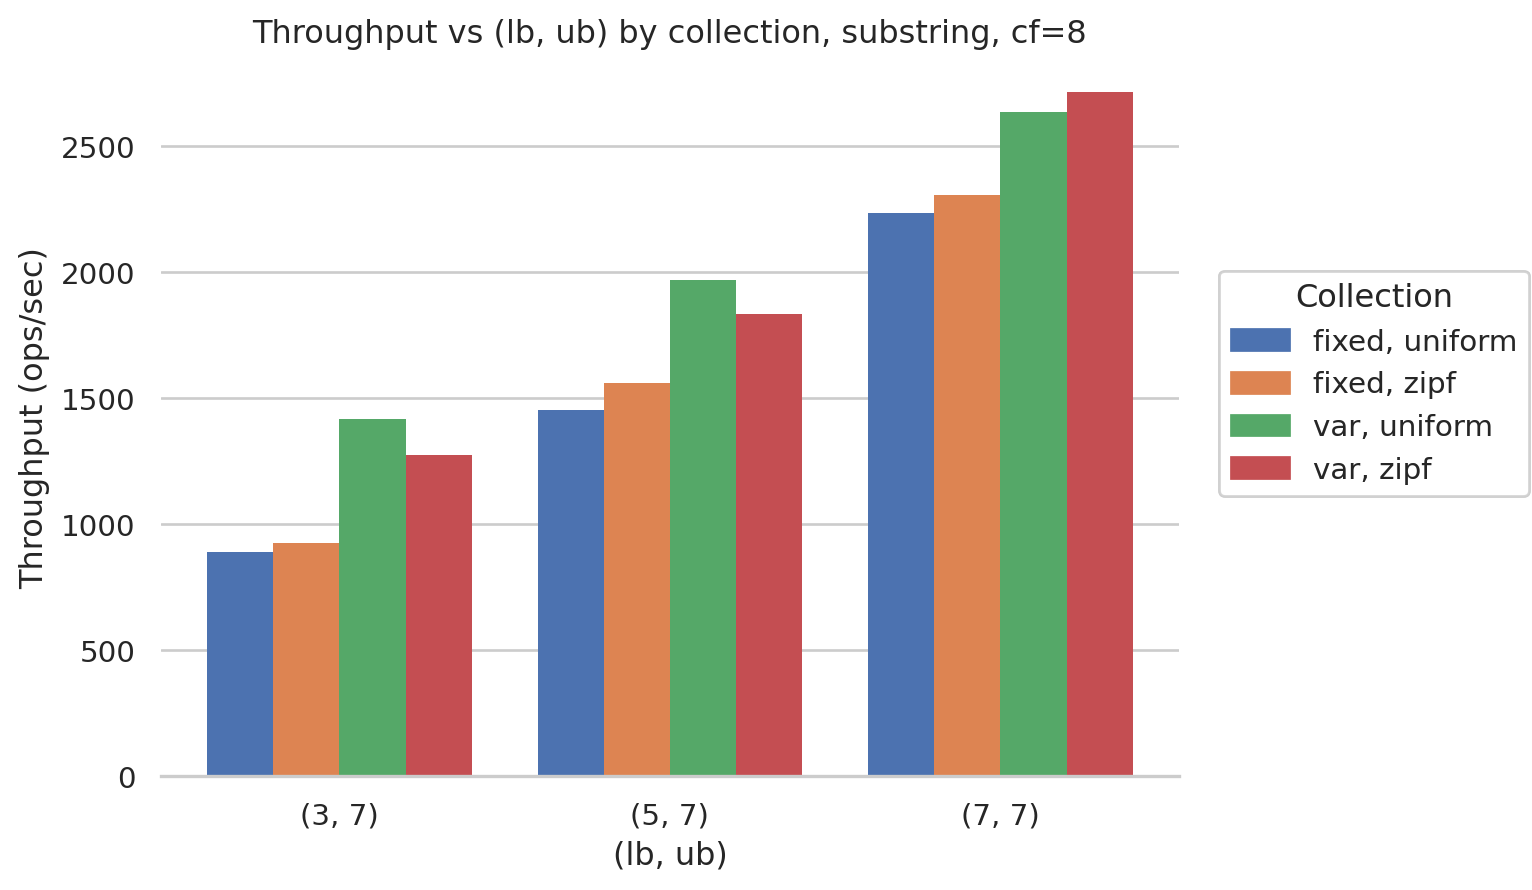

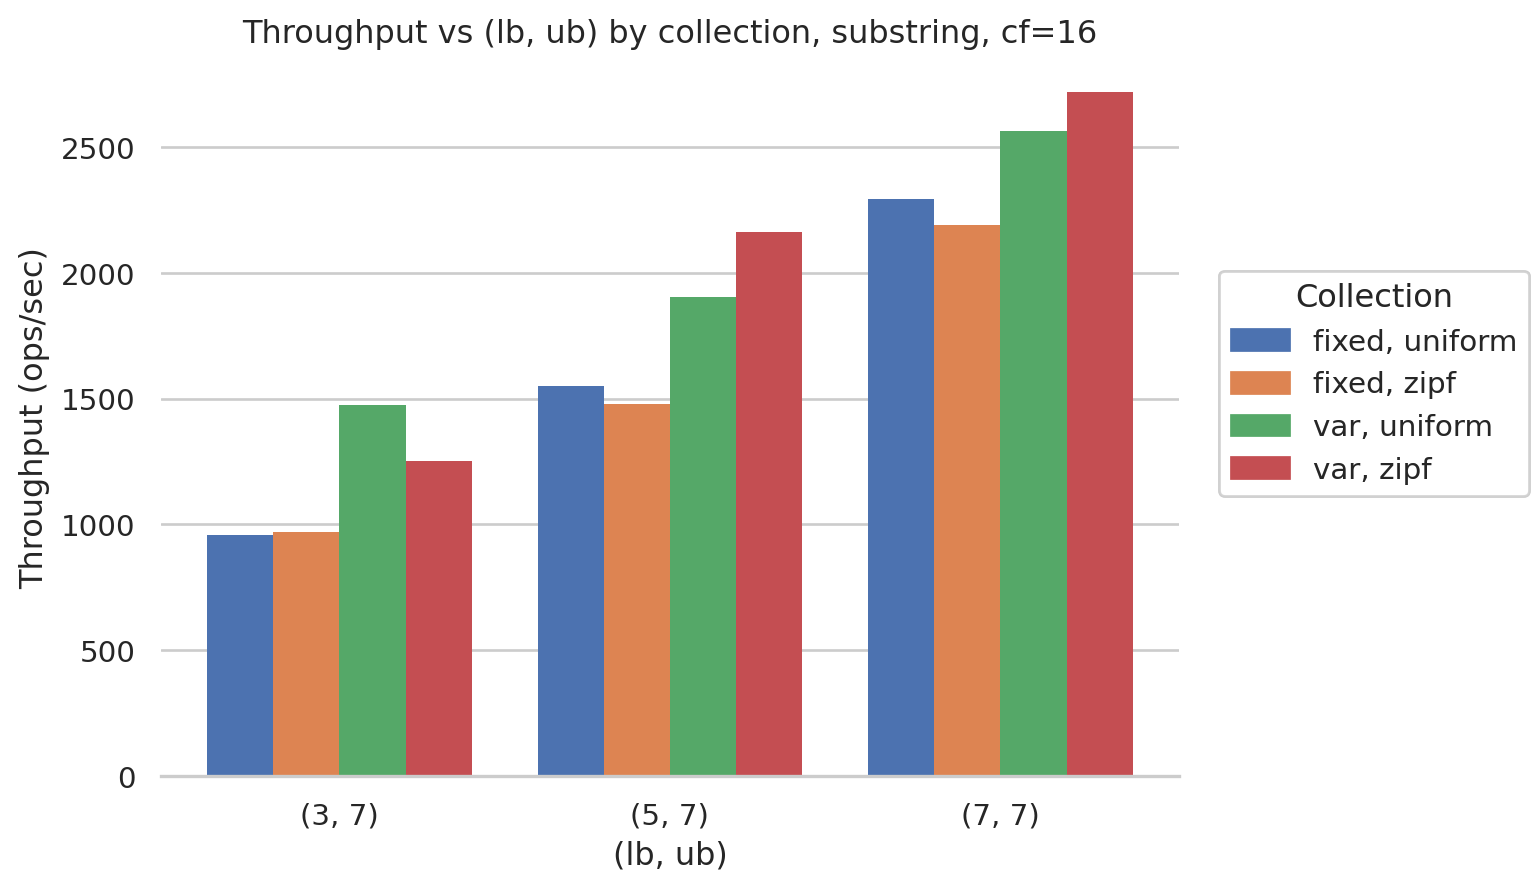

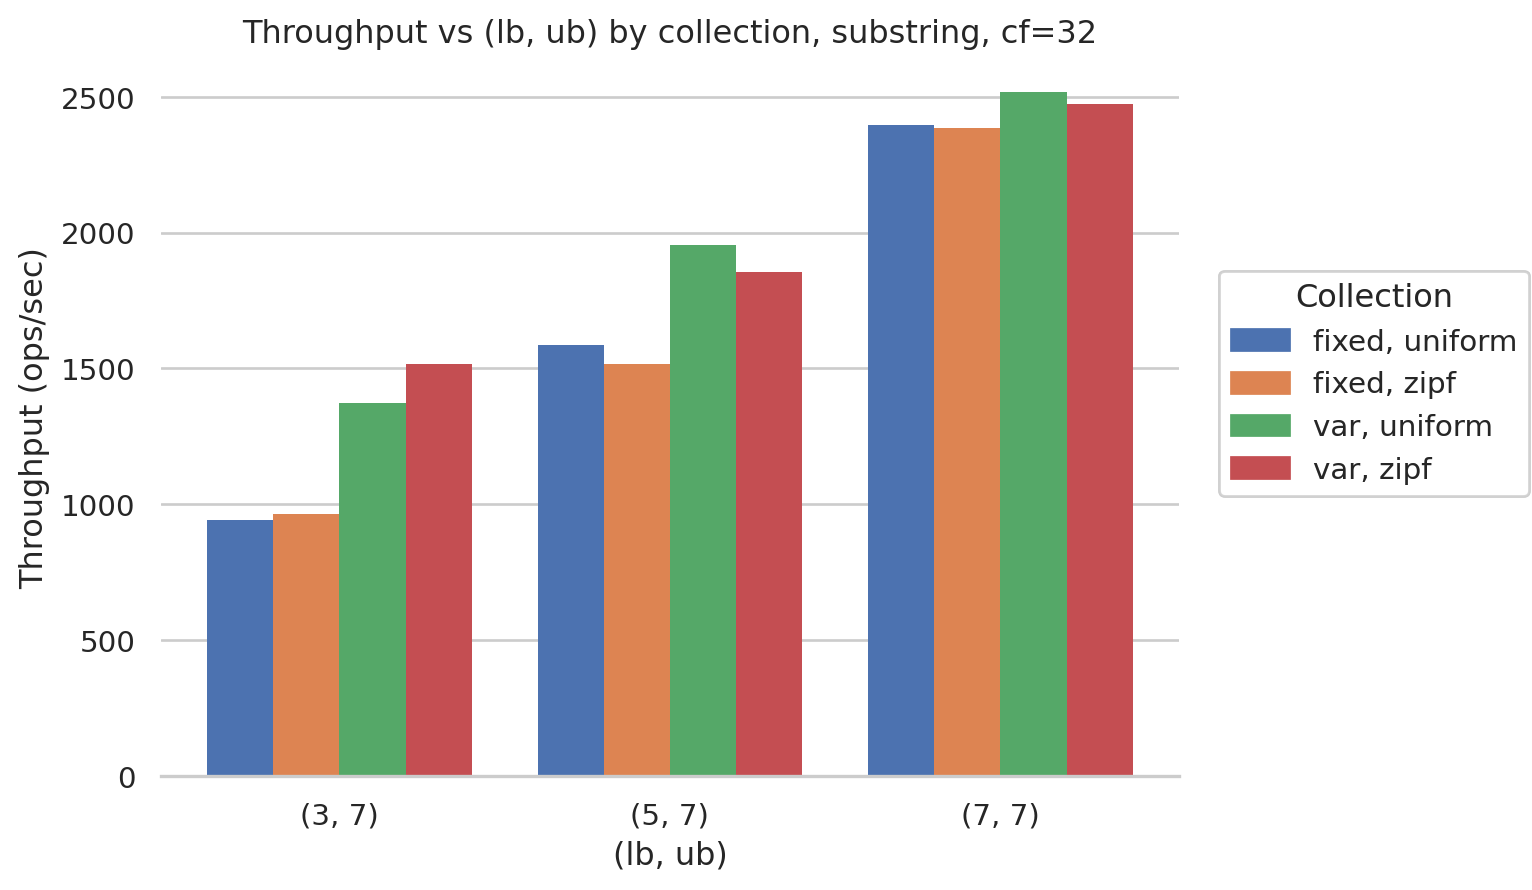

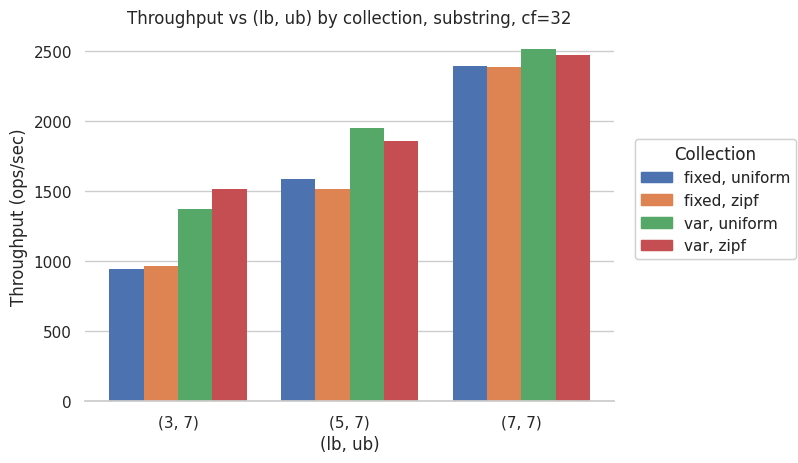

In [293]:
# Graph i1
for typ in ('prefix', 'substring'):
    for cf in (0, 4, 8, 16, 32):
        stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['cf'] == cf) & (enc_stats['ub'] == 7)].copy()
        stats['tp'] = 16. * 1e9 / stats['lat_avg']
        stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
        title = f'Throughput vs (lb, ub) by collection, {typ}, cf={cf}'
        plt.close()
        ax = plt.gca()
        p = so.Plot(stats, x='lb', y='tp', color='collname')
        p = p.add(so.Bar(alpha=1), so.Dodge(empty='drop'))
        p = p.label(title=title, x='(lb, ub)', y='Throughput (ops/sec)', color='Collection')
        p = p.theme(sns.axes_style(style='whitegrid'))
        p = p.layout(engine='tight')
        p = p.scale(x=so.Continuous().tick(at=stats['lb'].unique()).label(like='({x}, 7)'))
        p = p.on(ax)
        sns.despine(ax=ax, left=True)
        ax.grid(False, axis='x')

        p.save(f'../figures/graphi1-{typ}-{cf}.png', bbox_inches='tight')
        display(p)


In [22]:
# uncompressed vs compressed vs total investigation
stats = enc_stats.copy()
stats['esc_c_ratio'] = stats['esc_compressed_size'] / stats['esc_data_size']
stats['edc_c_ratio'] = stats['edc_compressed_size'] / stats['edc_data_size']
stats['ecoc_c_ratio'] = stats['ecoc_compressed_size'] / stats['ecoc_data_size']
stats['total_c_ratio'] = (
    stats['esc_compressed_size'] + stats['edc_compressed_size'] + stats['ecoc_compressed_size']
) / (
    stats['esc_data_size'] + stats['edc_data_size'] + stats['ecoc_data_size']
)

esc_sort = stats.sort_values(by='esc_c_ratio')


edc_sort = stats.sort_values(by='edc_c_ratio')


ecoc_sort = stats.sort_values(by='ecoc_c_ratio')
ecoc_sort[['ecoc_c_ratio', 'name']], edc_sort[['edc_c_ratio', 'name']], esc_sort[['esc_c_ratio', 'name']], len(stats[stats['edc_c_ratio'] > 1]), len(stats[stats['total_c_ratio'] > 1])


(     ecoc_c_ratio                                            name
 209      0.385362   experiment11_var-uniform-16_e_0_substring_7_7
 305      0.392254     experiment11_var-zipf-16_e_16_substring_5_7
 318      0.398470     experiment11_var-zipf-16_e_32_substring_3_5
 205      0.409552   experiment11_var-uniform-16_e_0_substring_3_5
 239      0.411270  experiment11_var-uniform-16_e_32_substring_5_5
 ..            ...                                             ...
 279      0.832050         experiment11_var-zipf-16_e_0_prefix_3_3
 242      0.832653      experiment11_var-uniform-16_e_4_prefix_1_1
 348      0.833255         experiment11_var-zipf-16_e_8_prefix_7_7
 29       0.833456     experiment11_var-uniform-32_e_16_prefix_5_5
 332      0.833857         experiment11_var-zipf-16_e_4_prefix_7_7
 
 [352 rows x 2 columns],
      edc_c_ratio                                            name
 339     0.597869         experiment11_var-zipf-16_e_8_prefix_1_1
 249     0.612368      experiment11_v

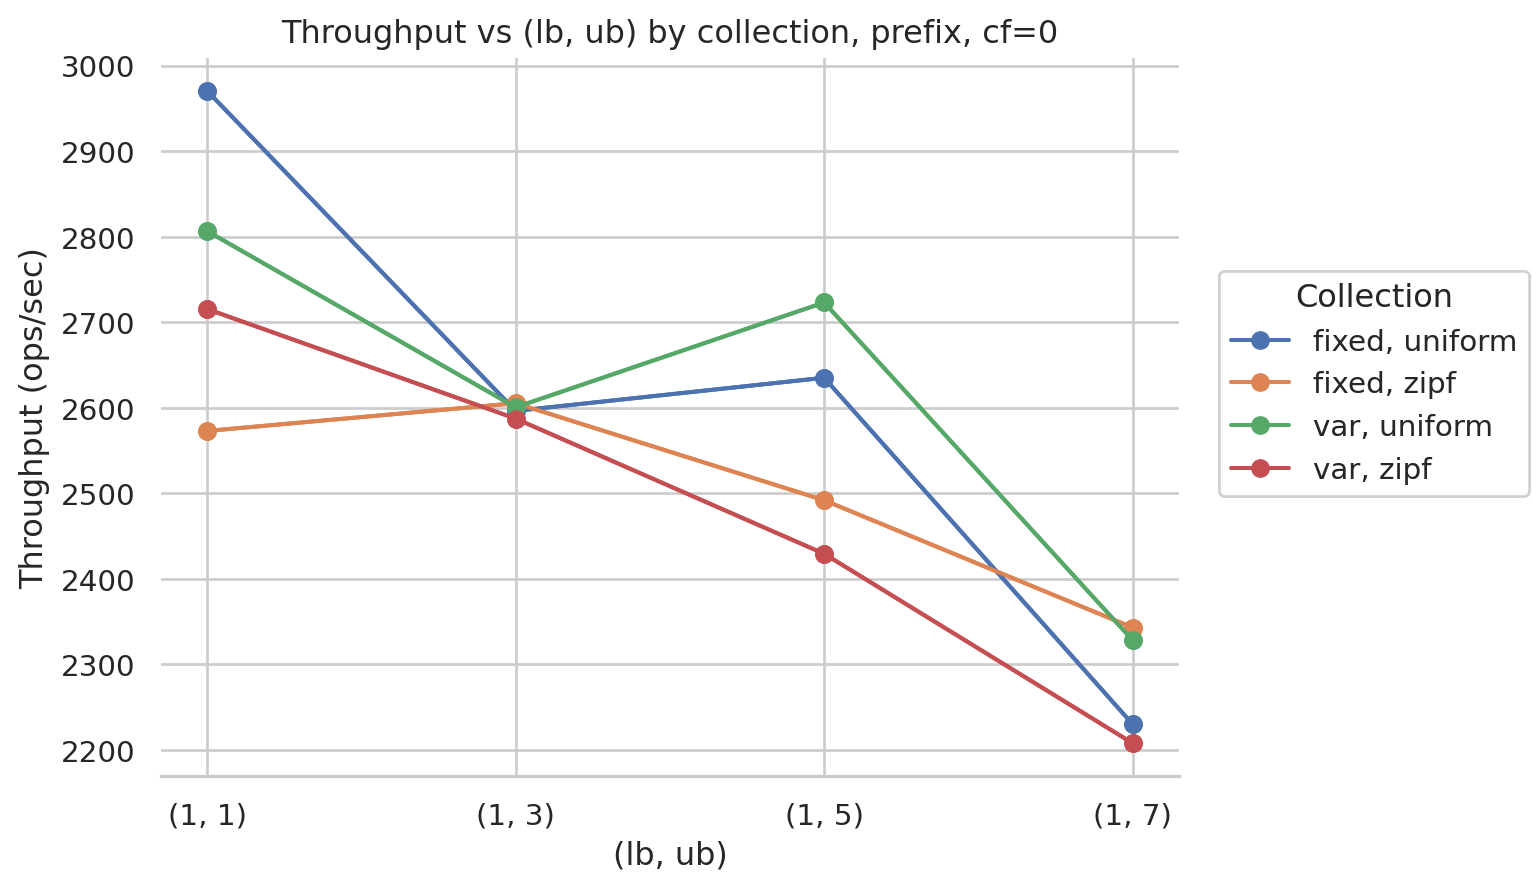

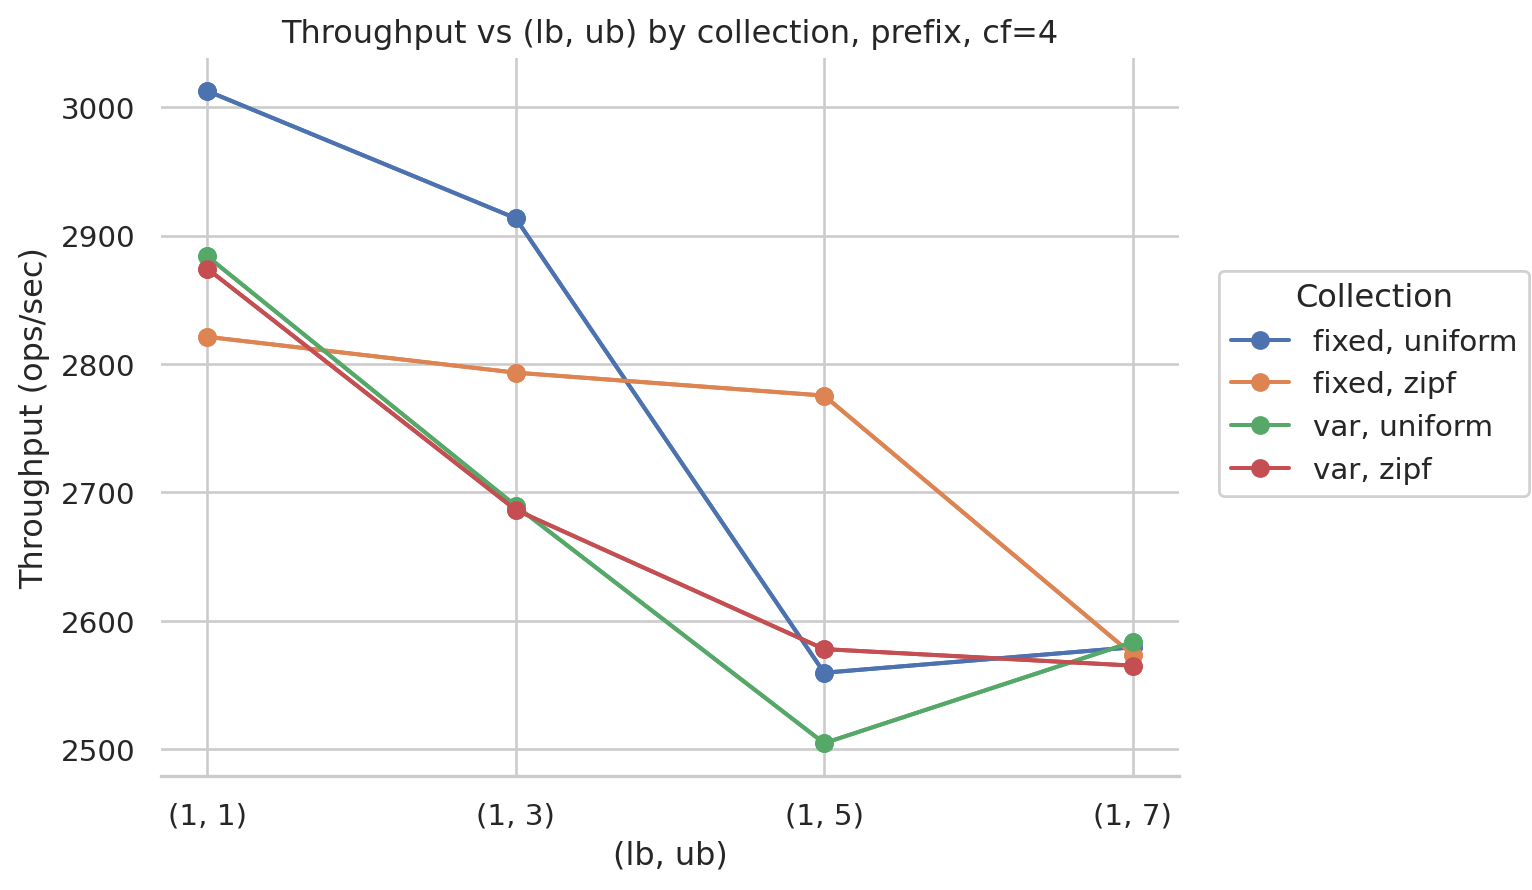

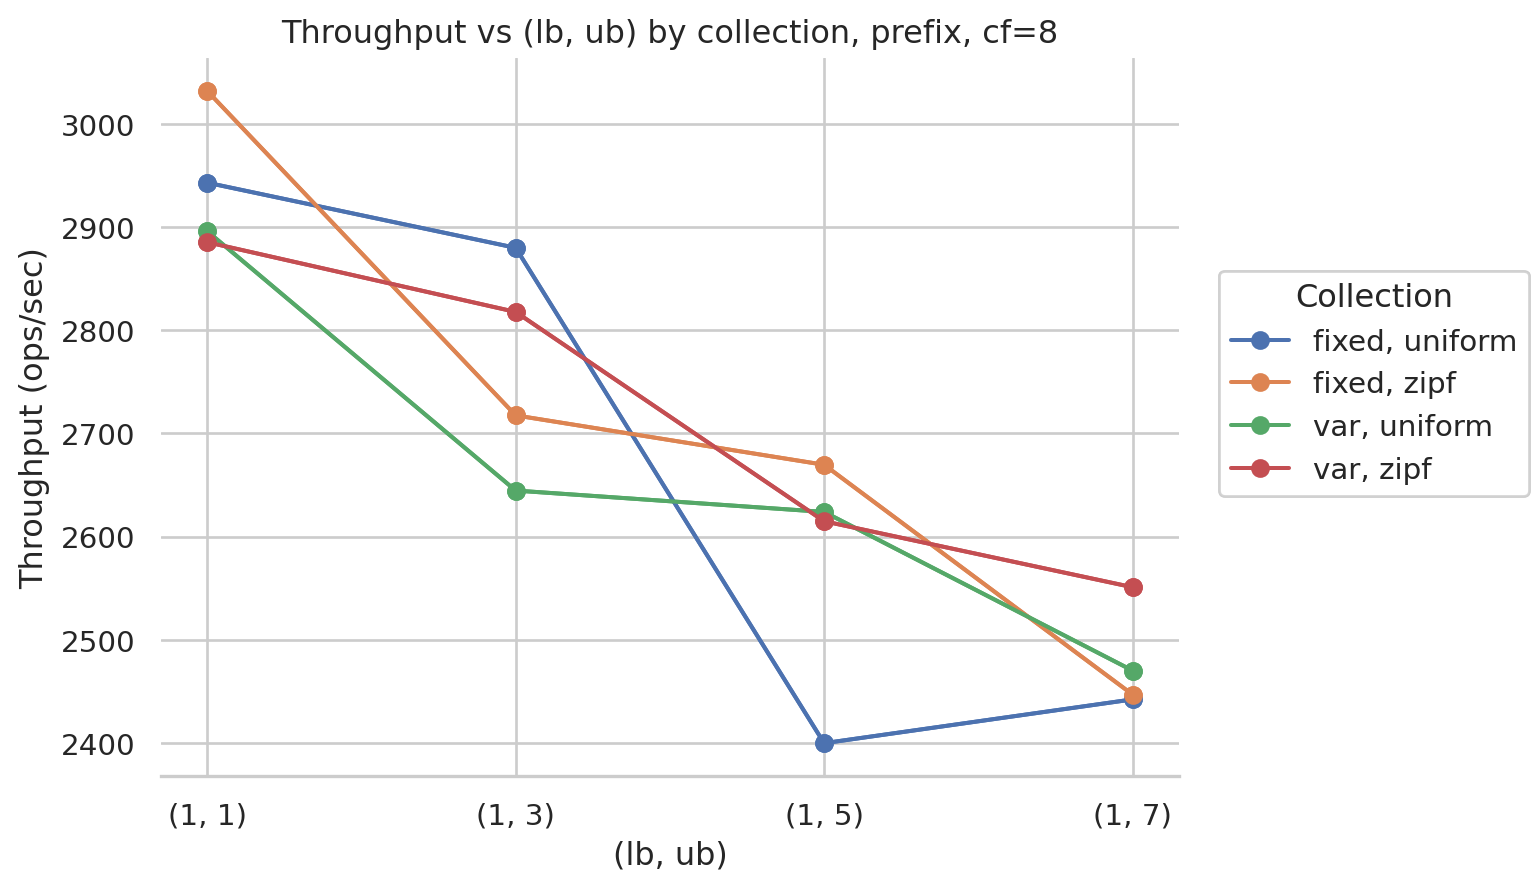

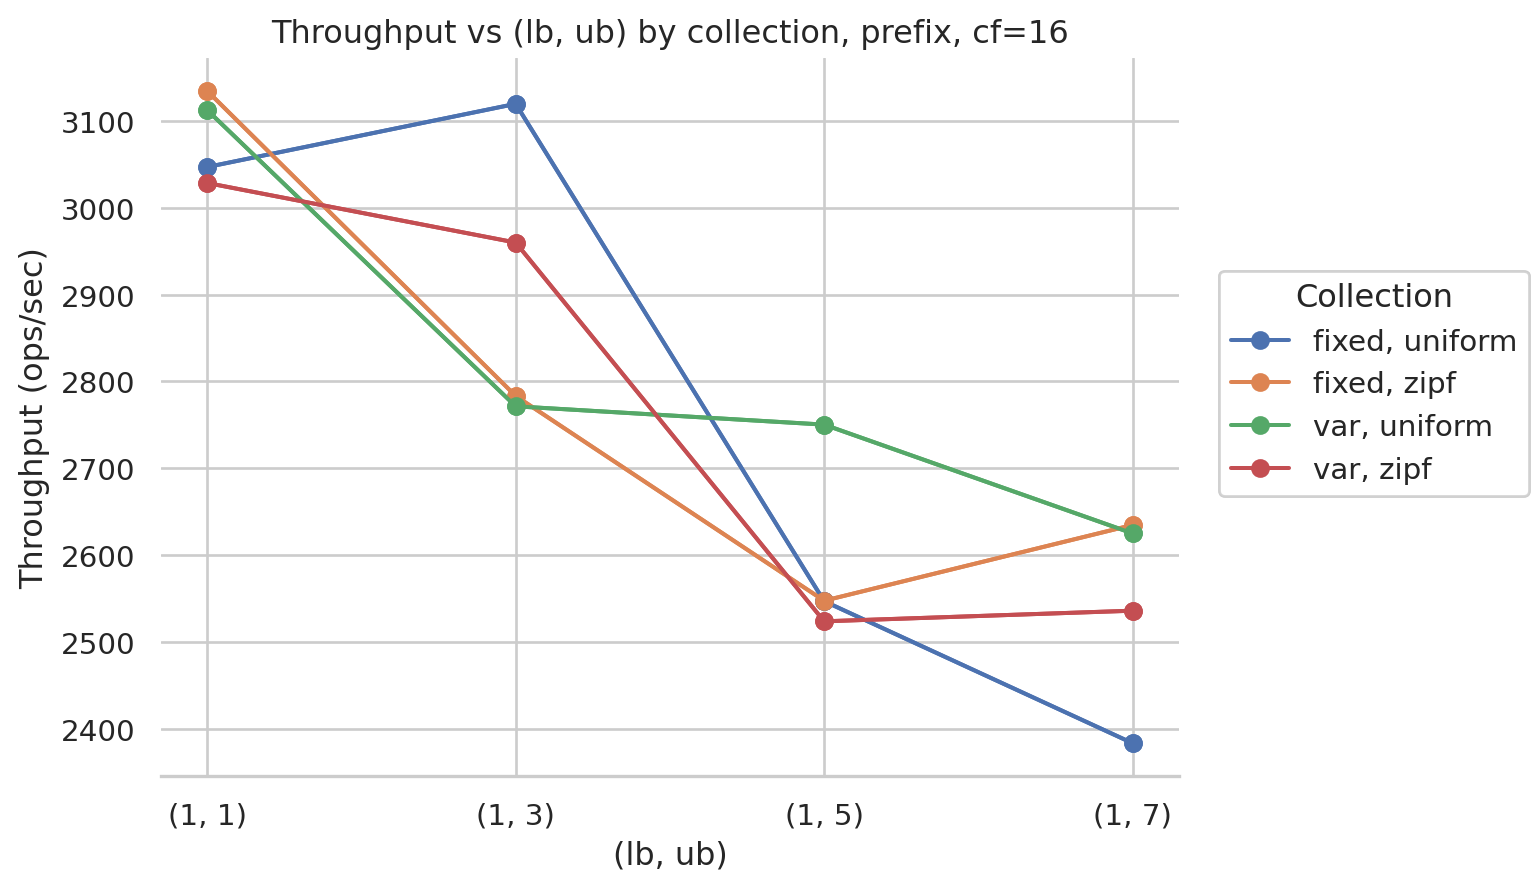

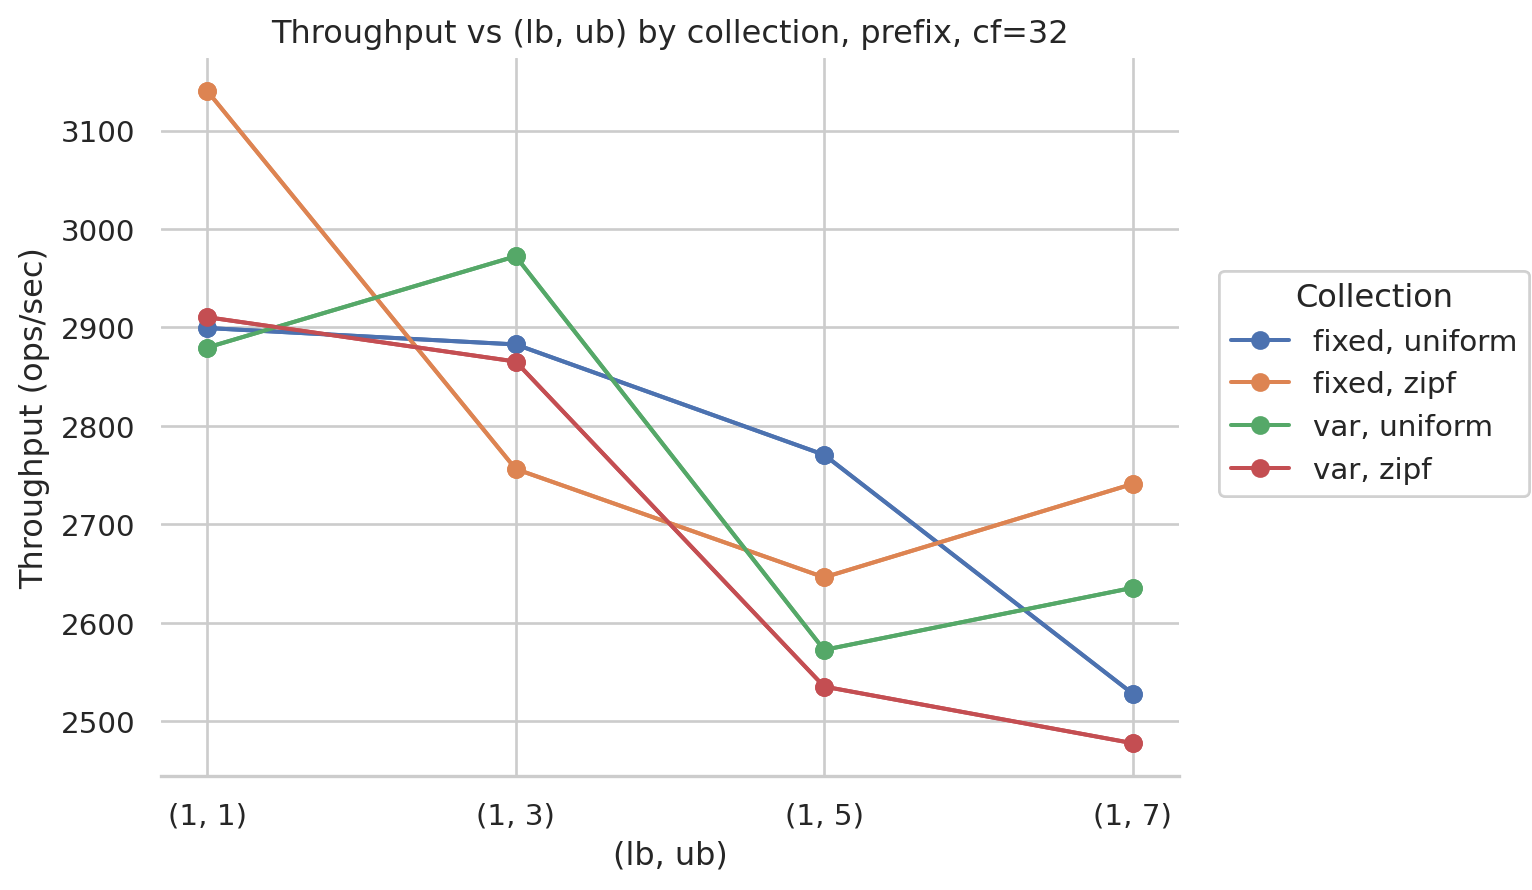

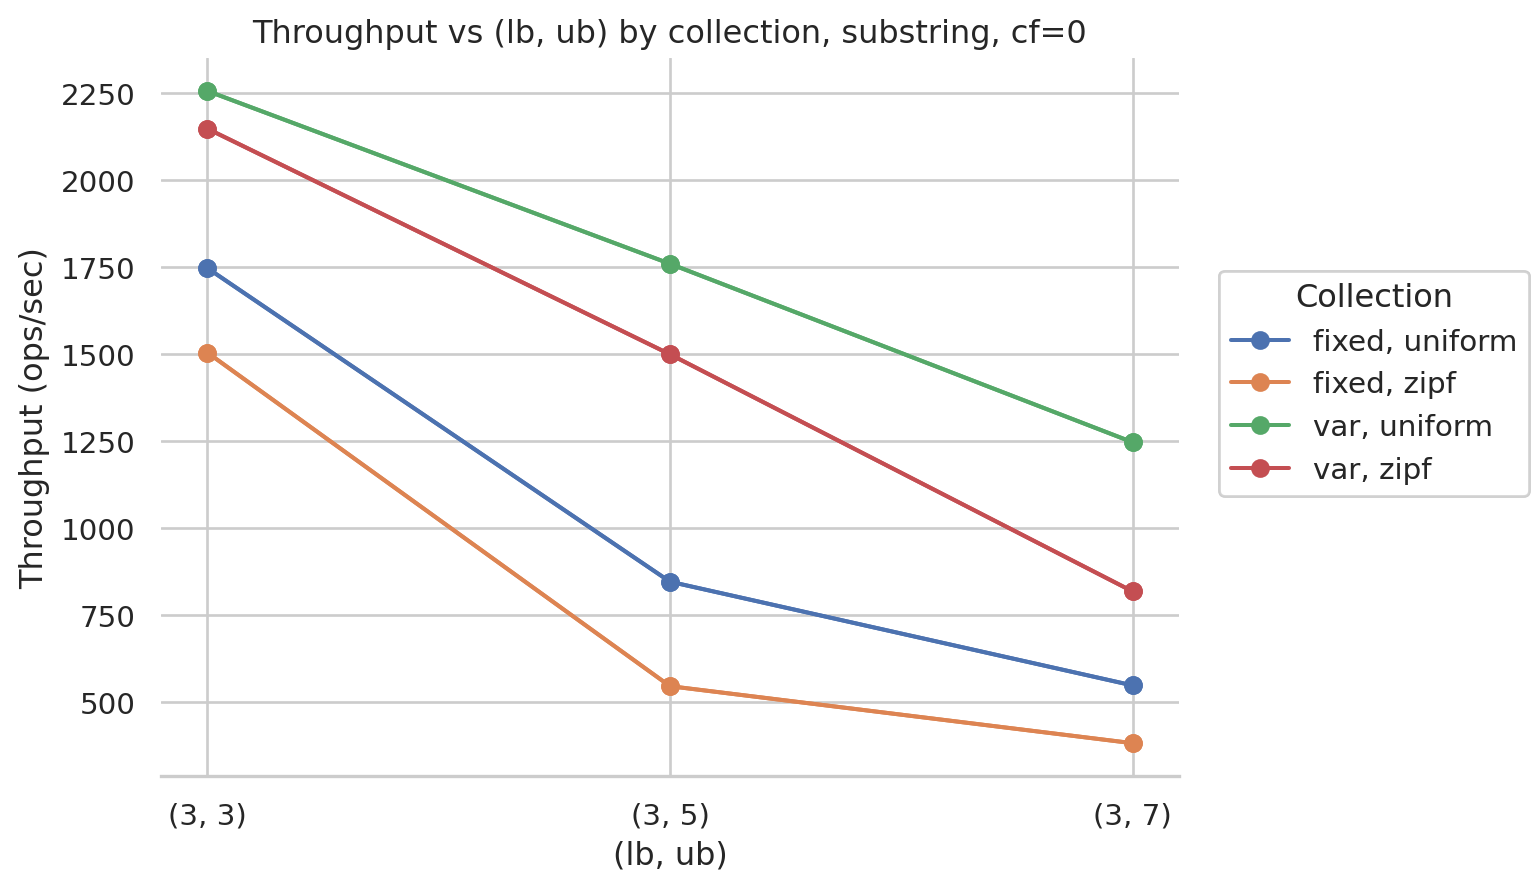

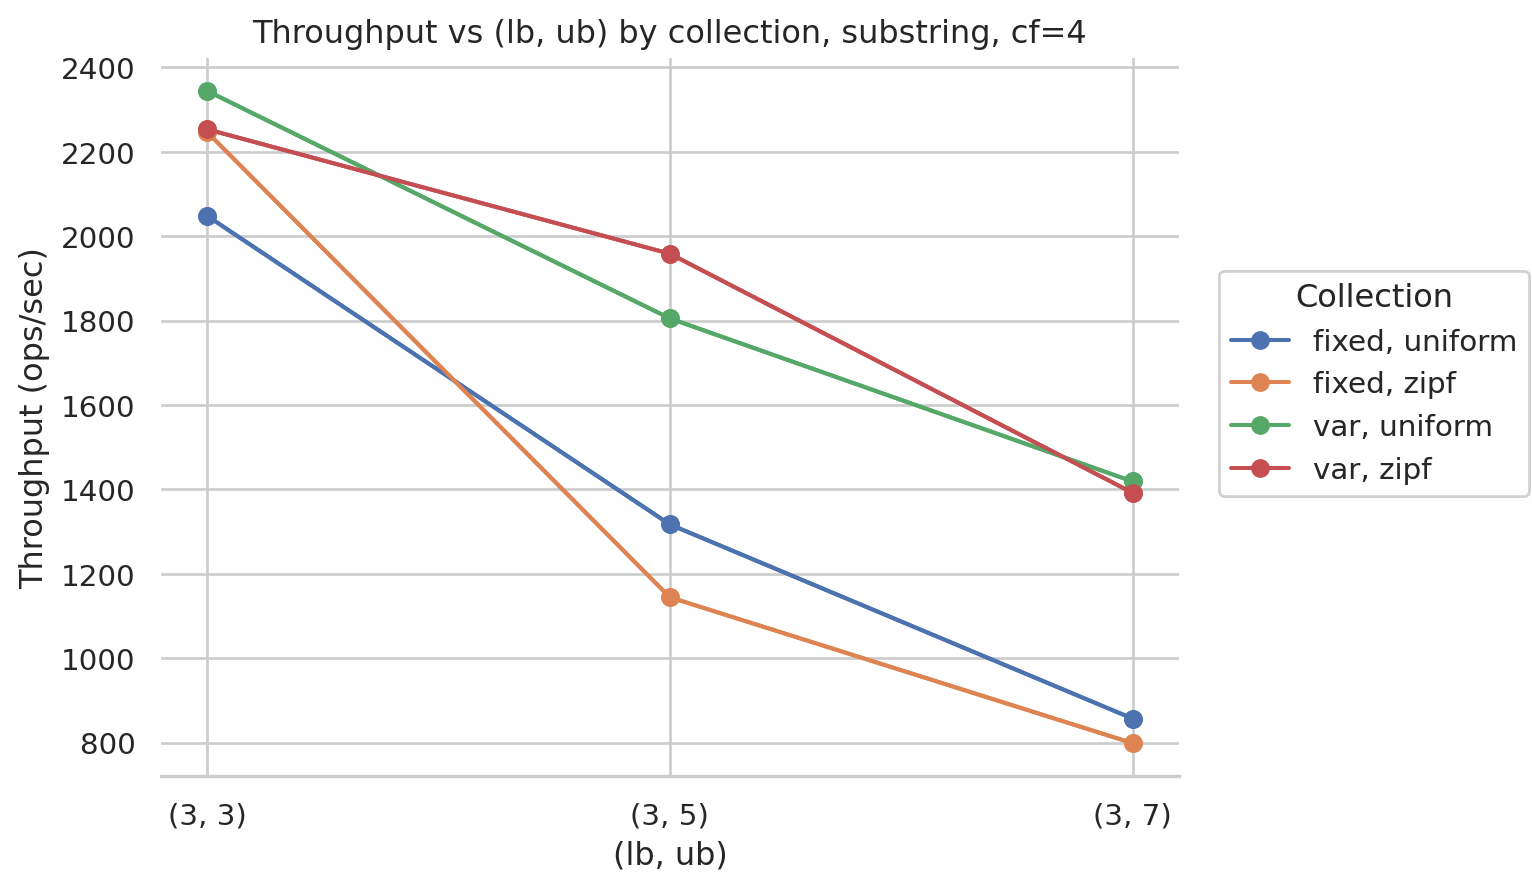

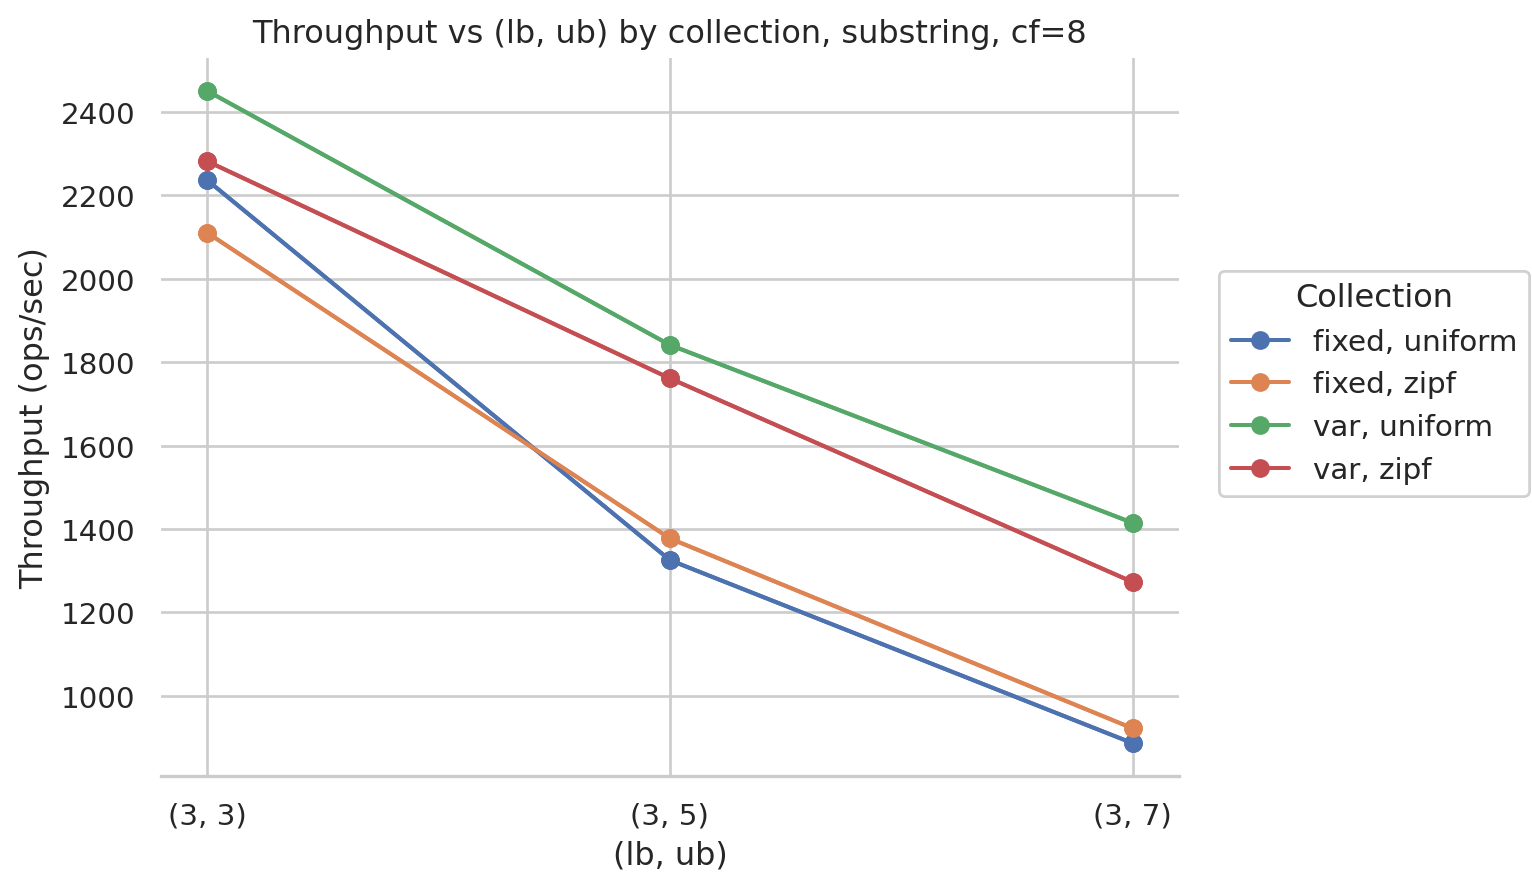

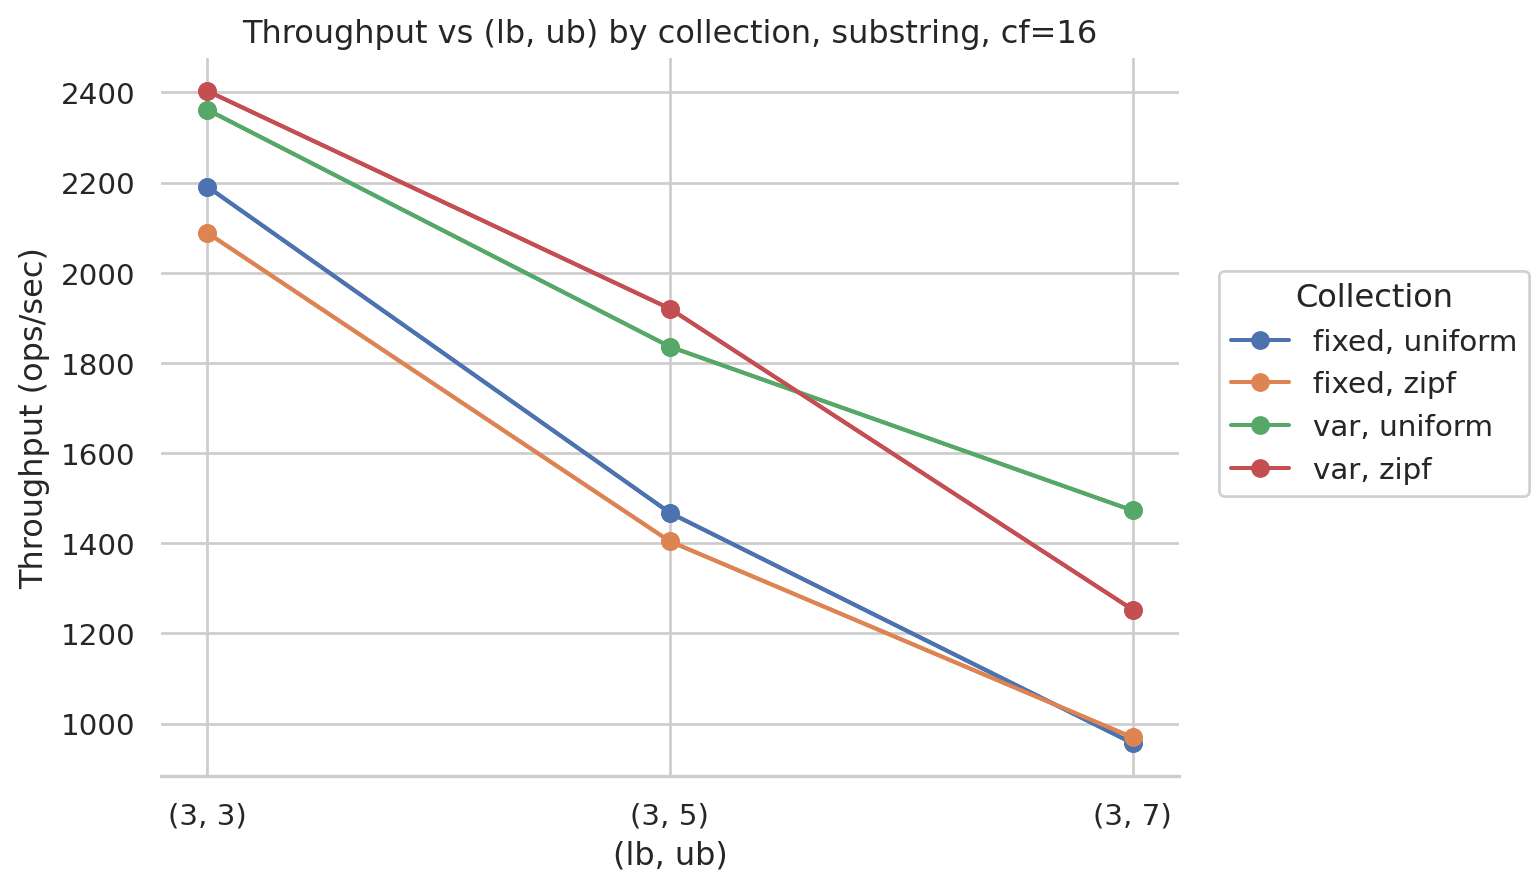

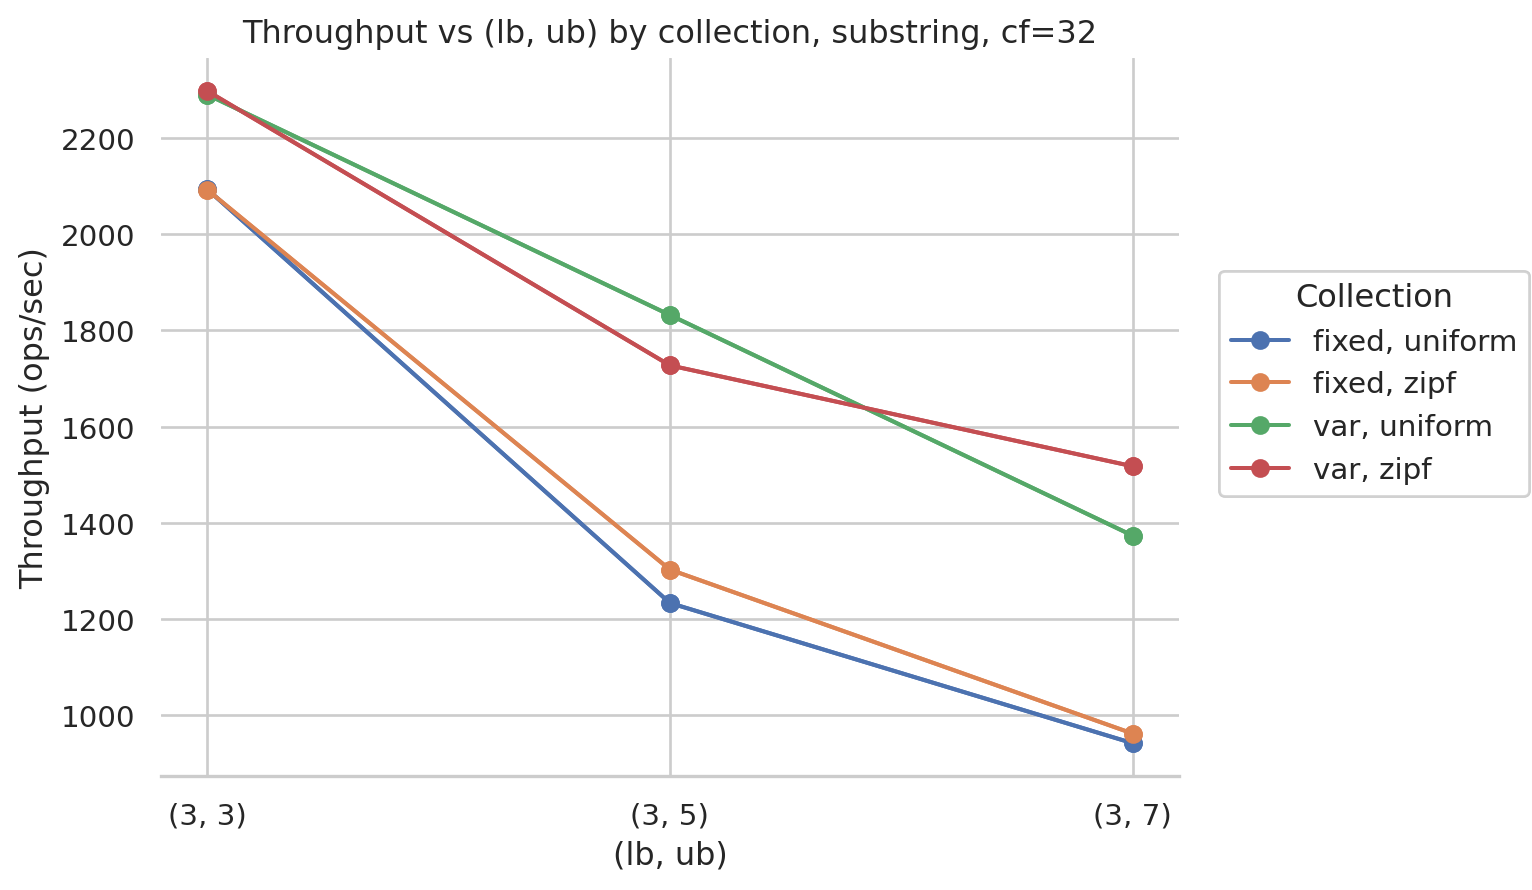

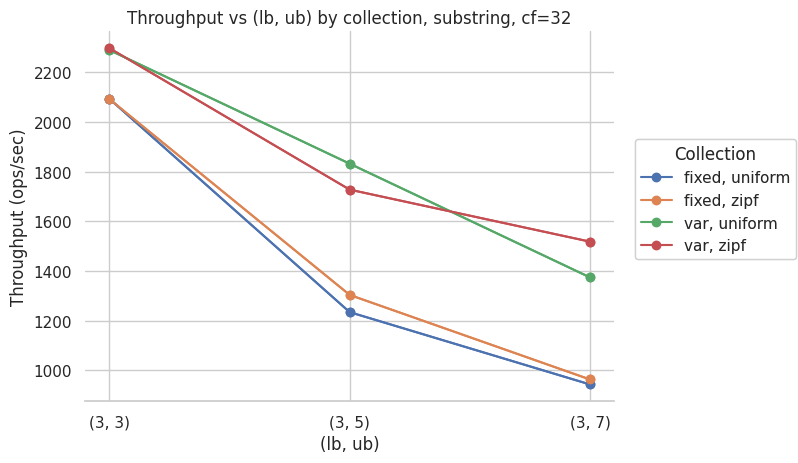

In [294]:
# Graph i2
for typ in ('prefix', 'substring'):
    for cf in (0, 4, 8, 16, 32):
        lowest_lb = 1 if typ == 'prefix' else 3
        stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['cf'] == cf) & (enc_stats['lb'] == lowest_lb)].copy()
        stats['tp'] = 16. * 1e9 / stats['lat_avg']
        stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
        title = f'Throughput vs (lb, ub) by collection, {typ}, cf={cf}'
        plt.close()
        ax = plt.gca()
        p = so.Plot(stats, x='ub', y='tp', color='collname')
        p = p.add(so.Line(marker='o', alpha=1))
        p = p.label(title=title, x='(lb, ub)', y='Throughput (ops/sec)', color='Collection')
        p = p.theme(sns.axes_style(style='whitegrid'))
        p = p.layout(engine='tight')
        p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()).label(like=f'({lowest_lb}, {{x}})'))
        p = p.on(ax)
        sns.despine(ax=ax, left=True)

        p.save(f'../figures/graphi2-{typ}-{cf}.png', bbox_inches='tight')
        display(p)


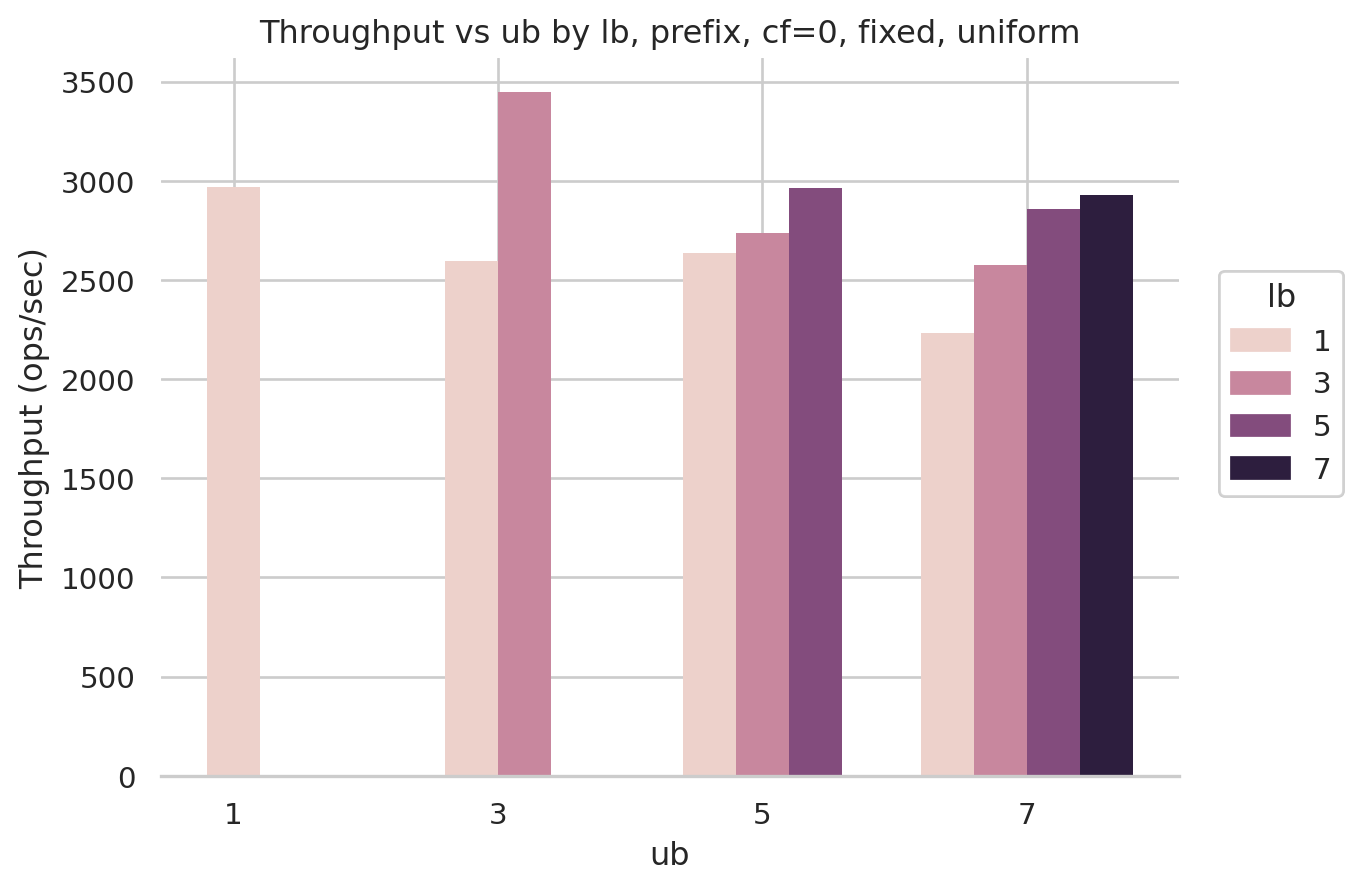

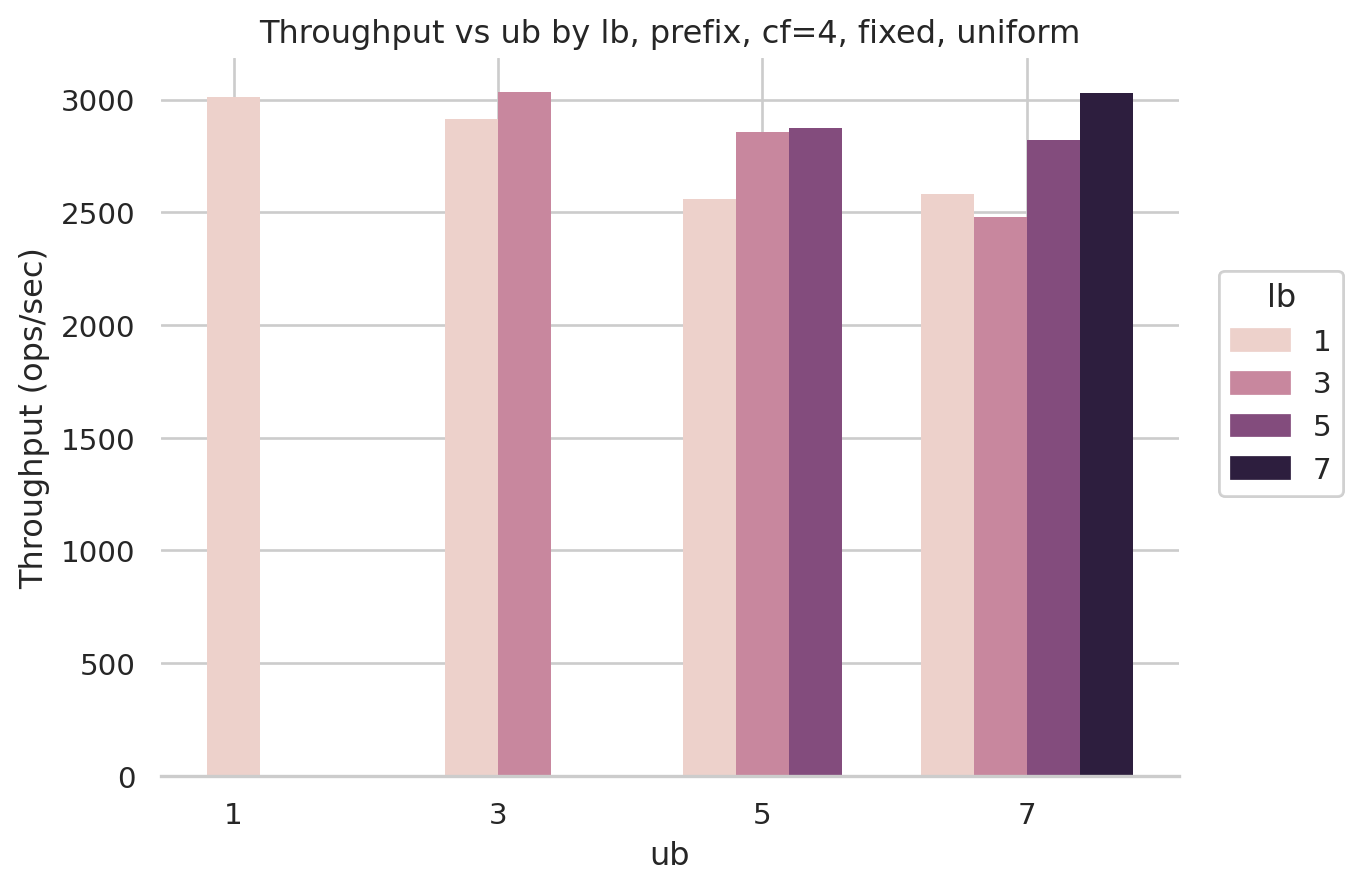

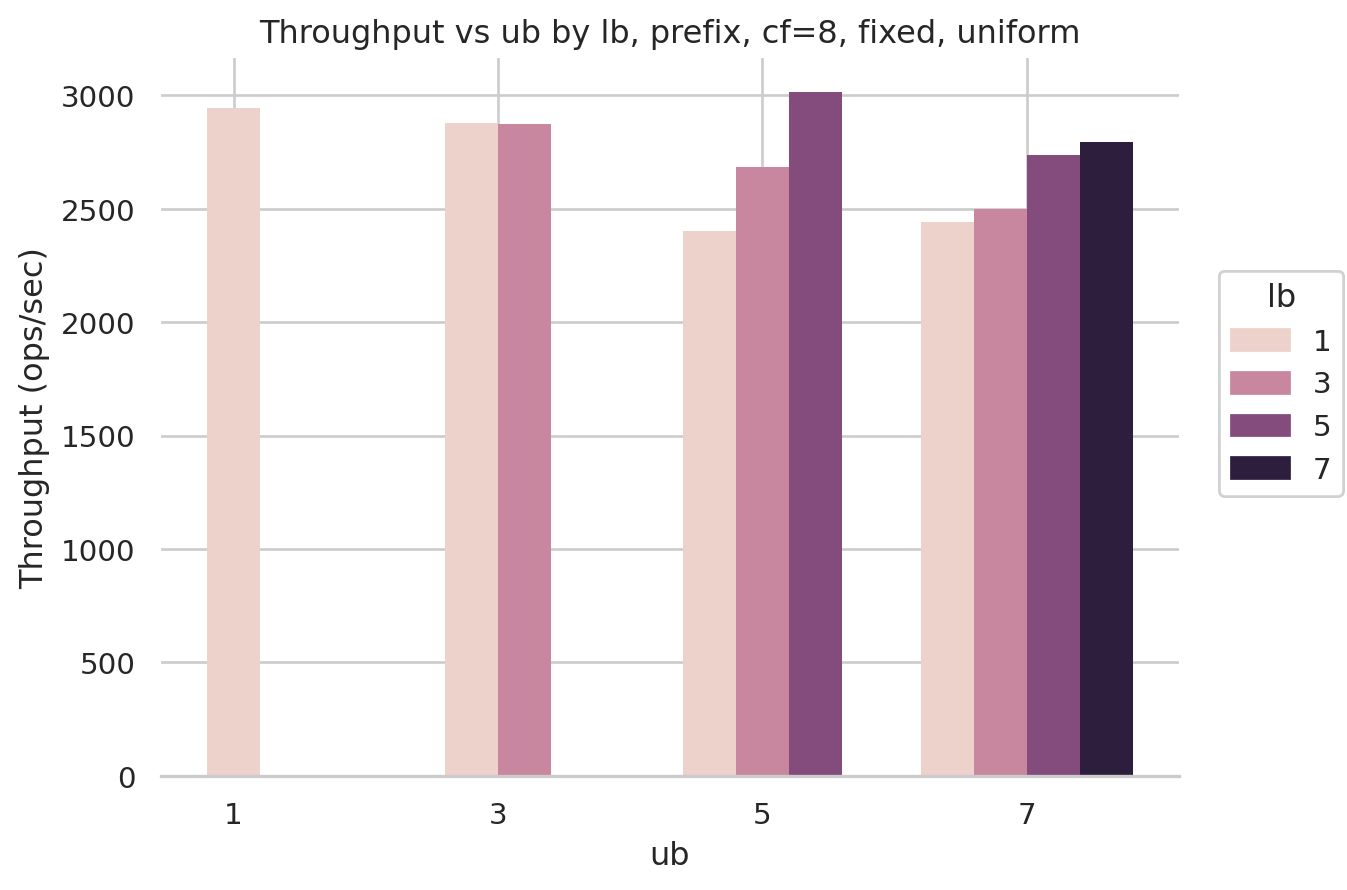

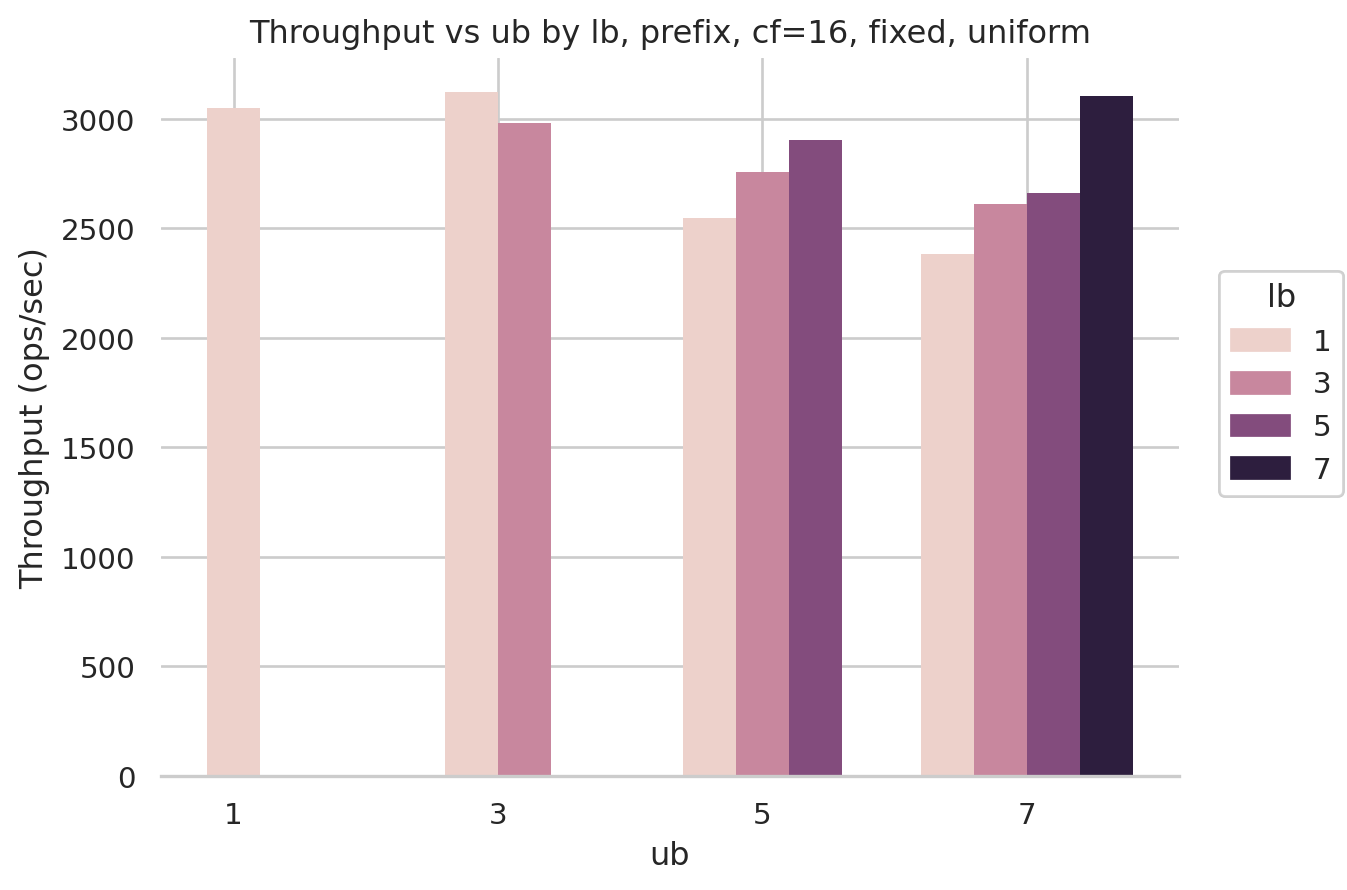

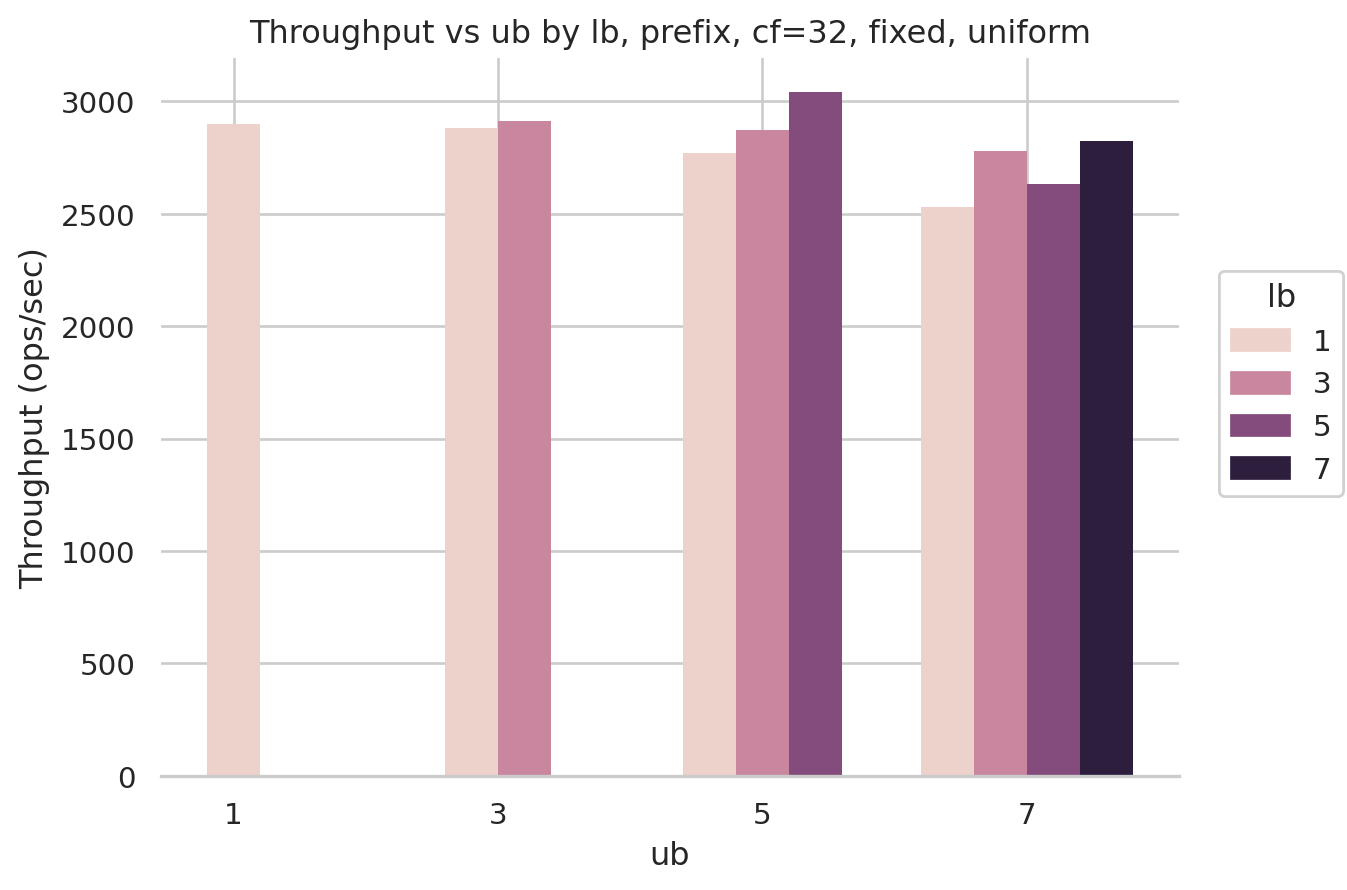

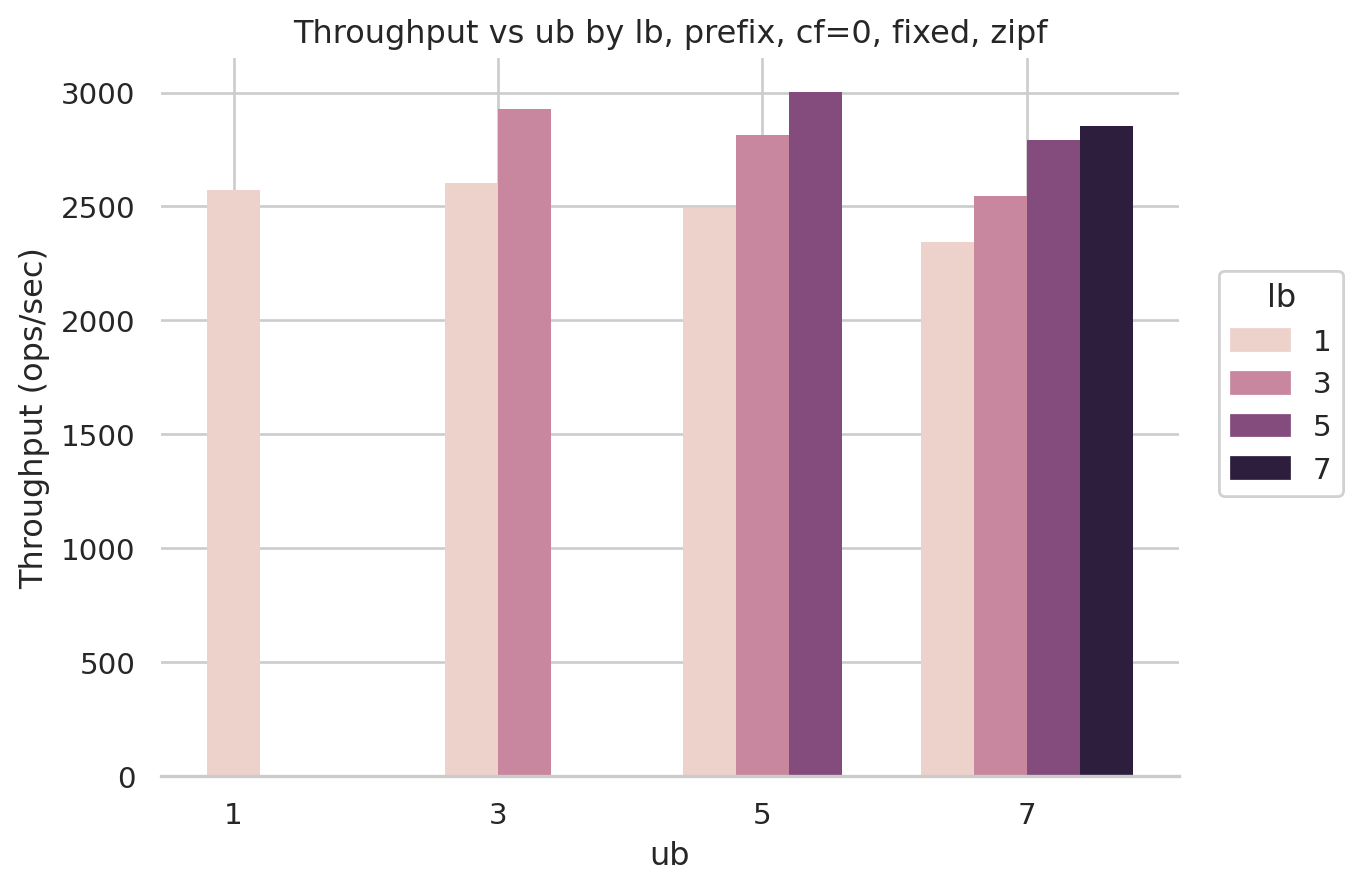

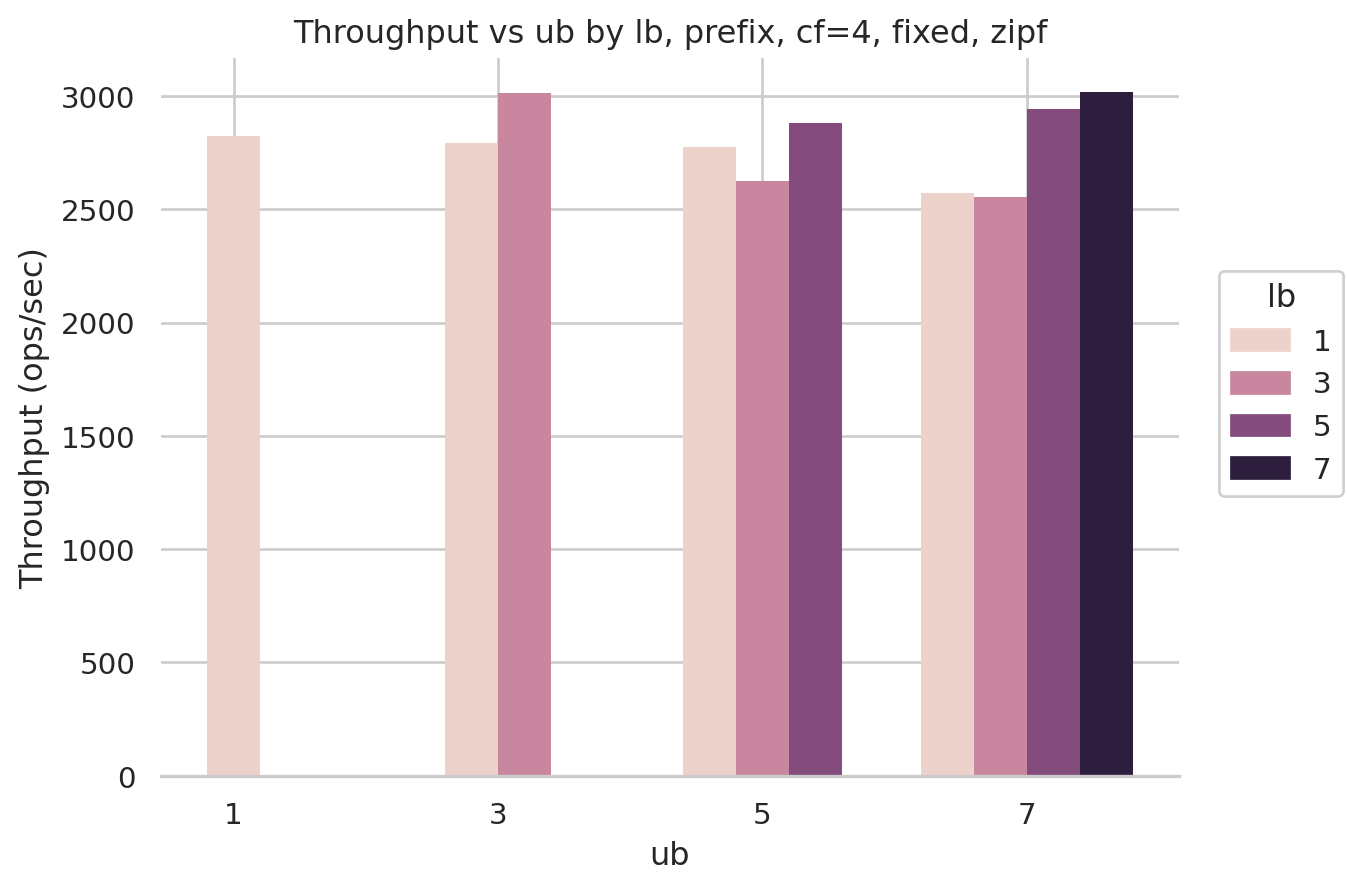

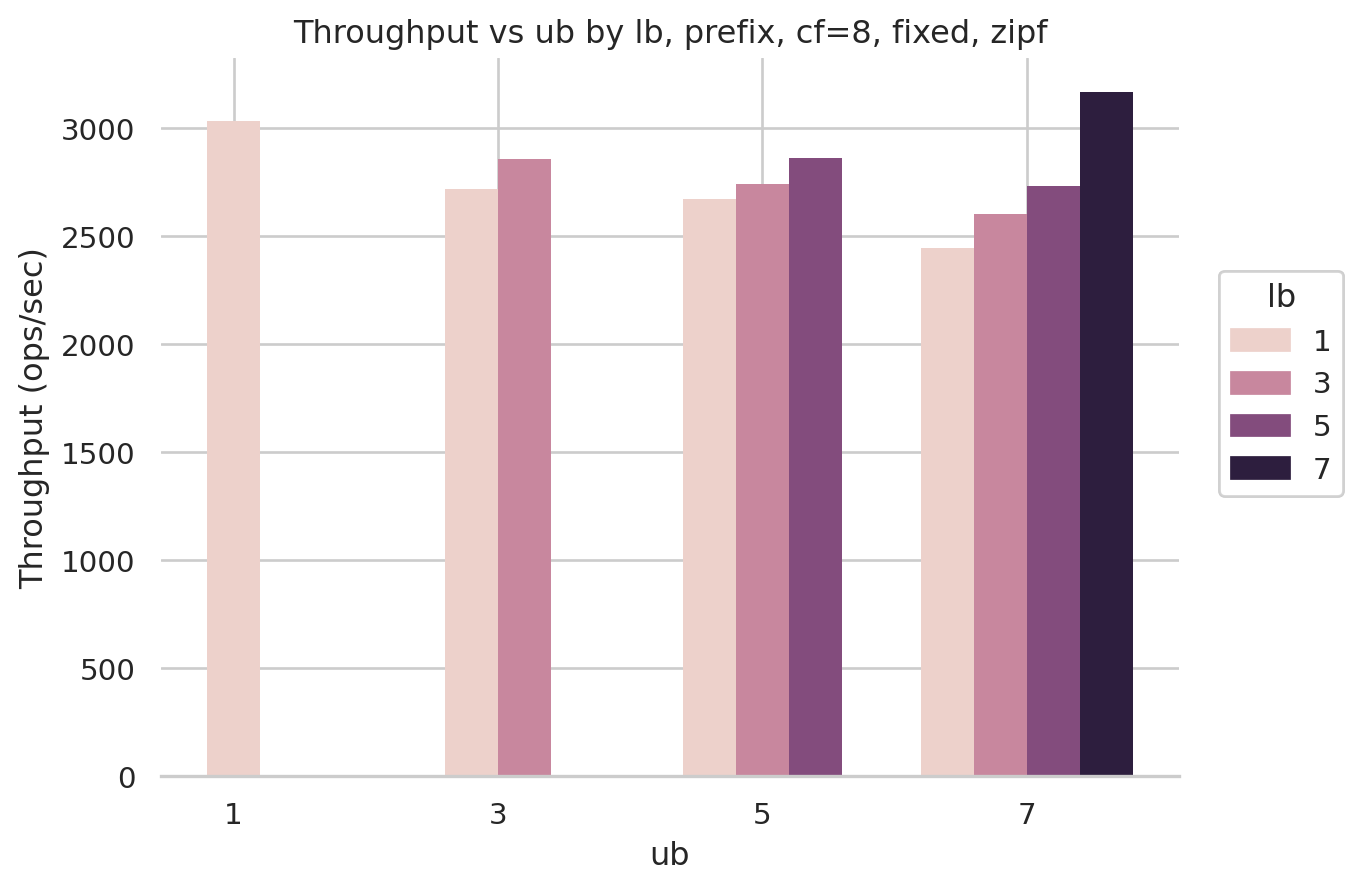

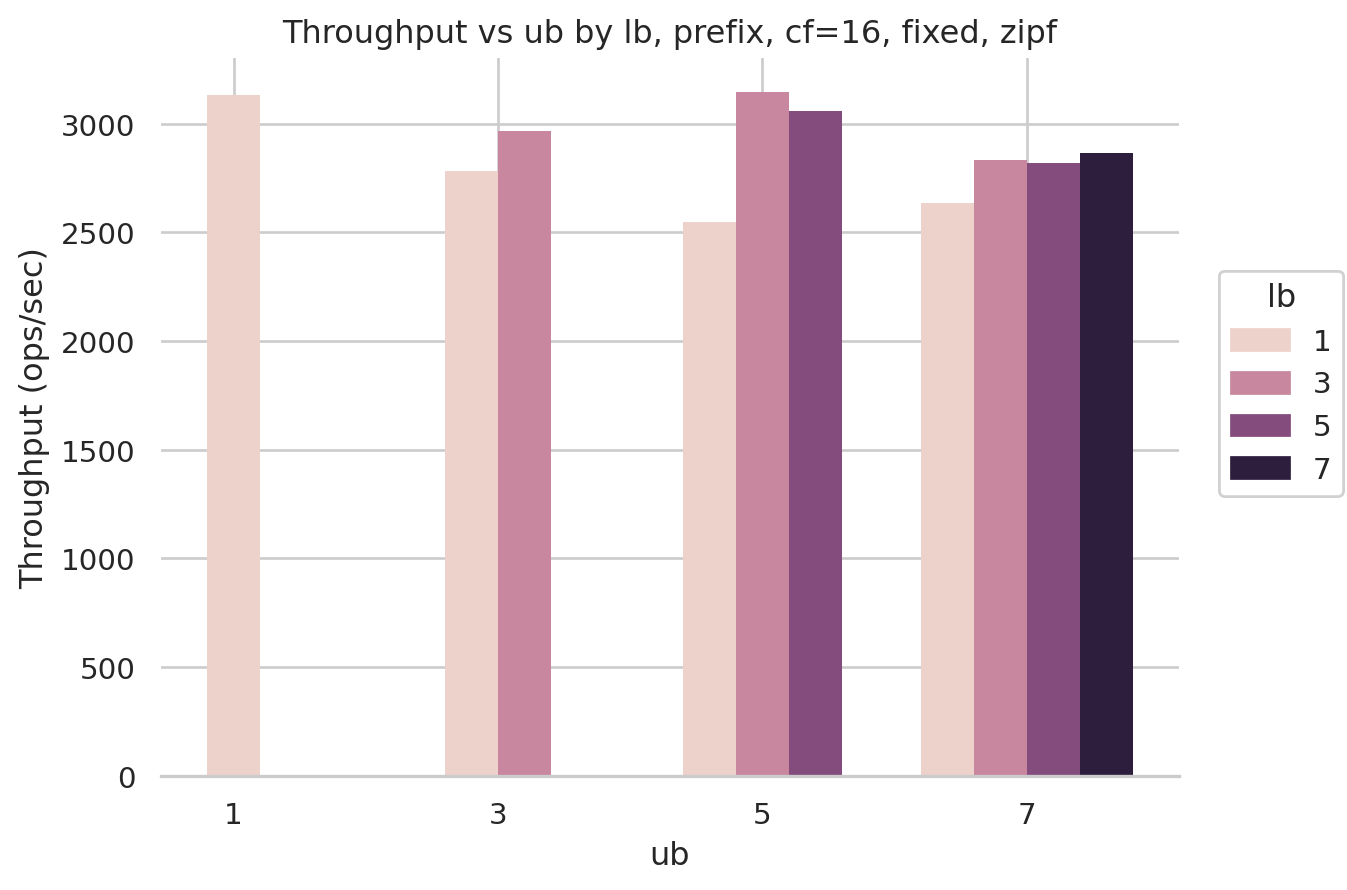

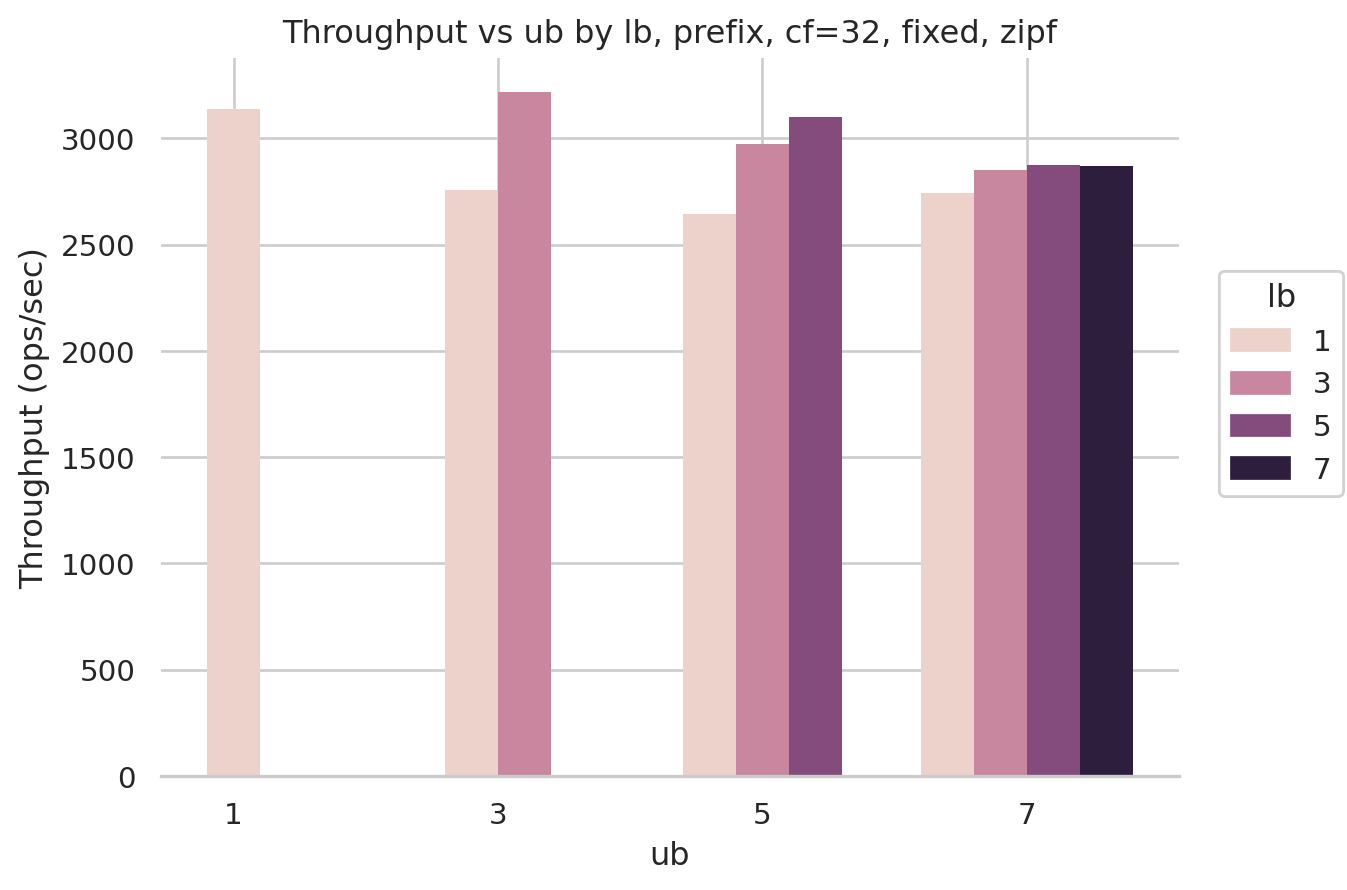

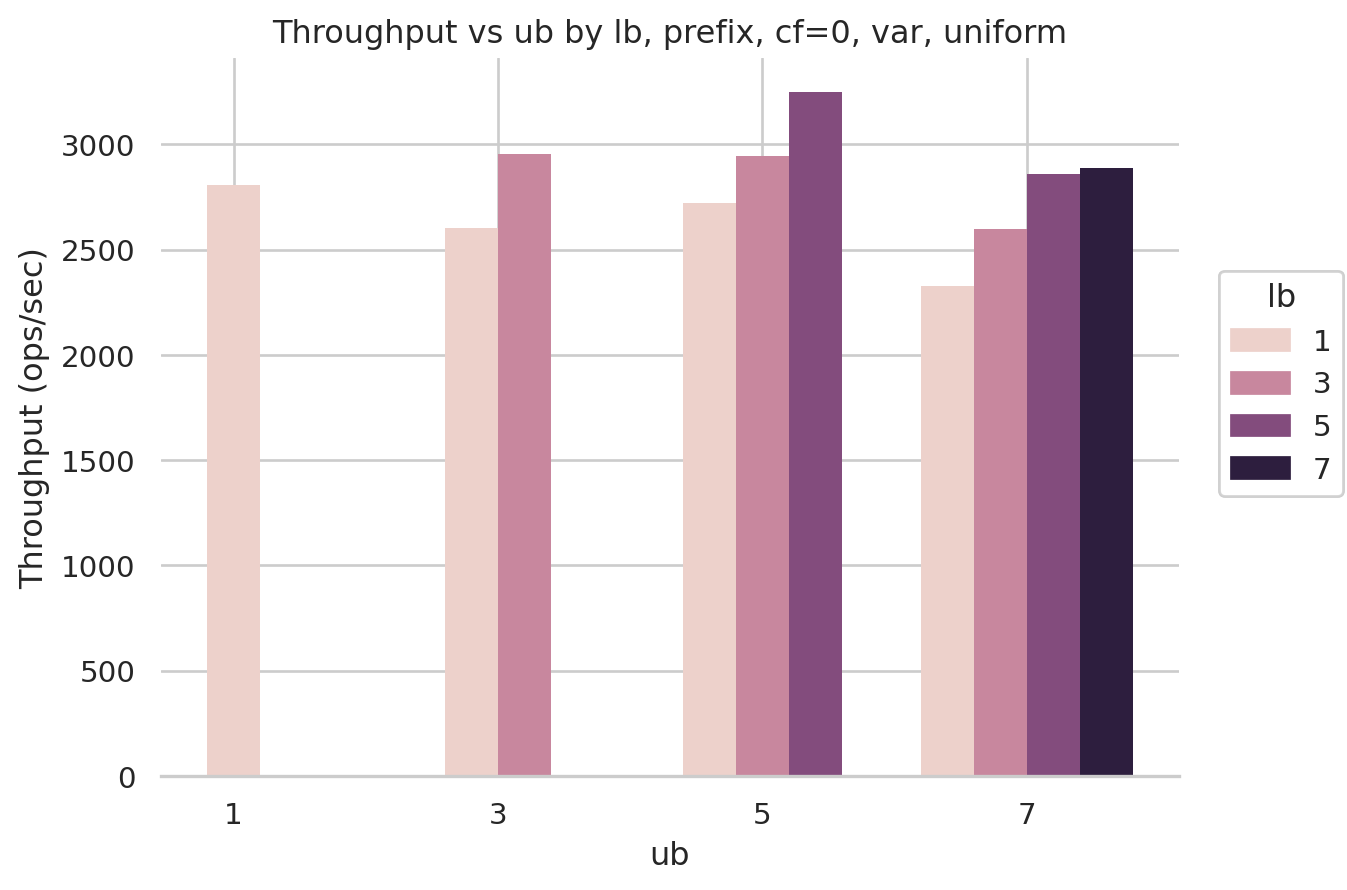

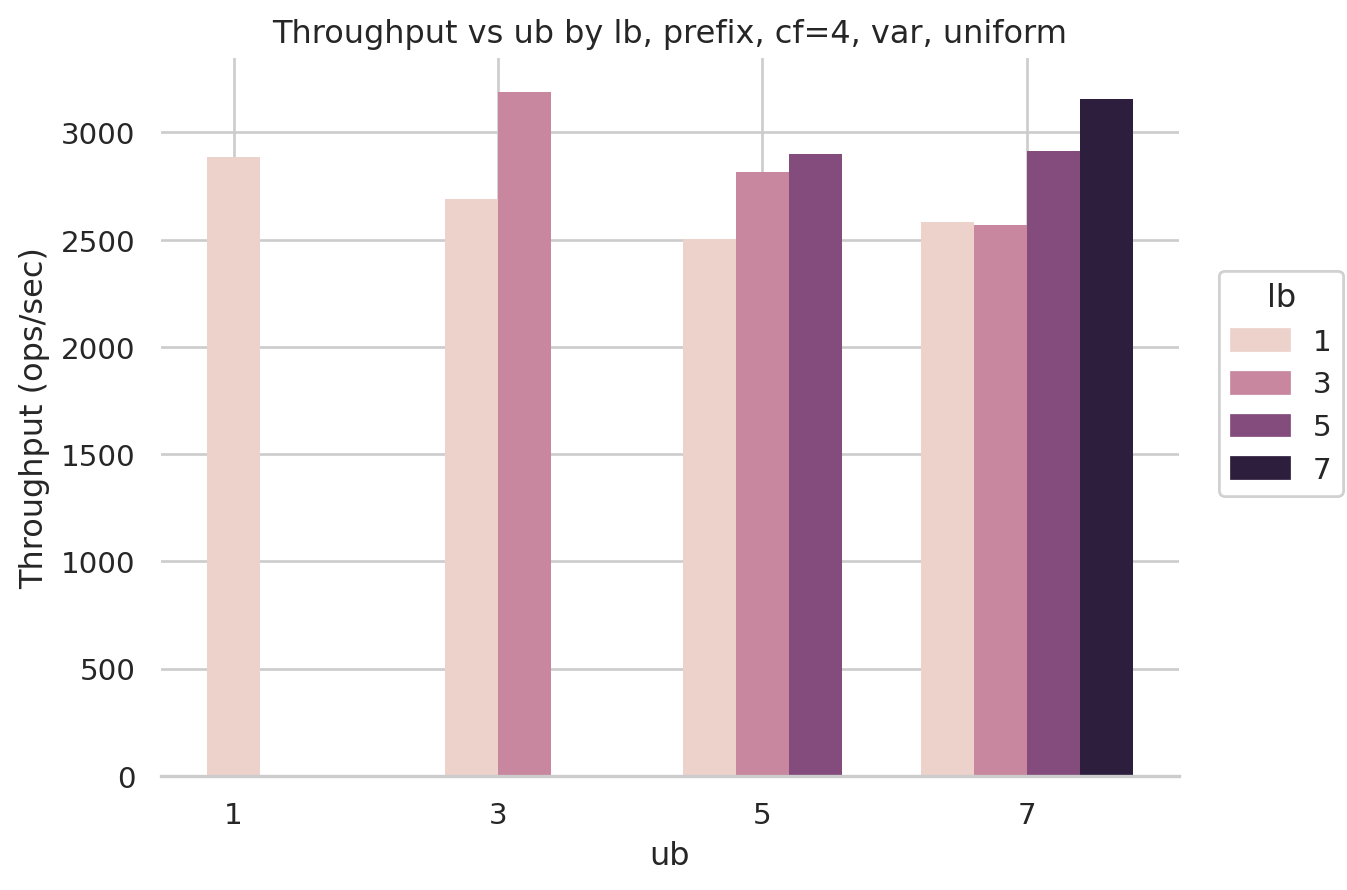

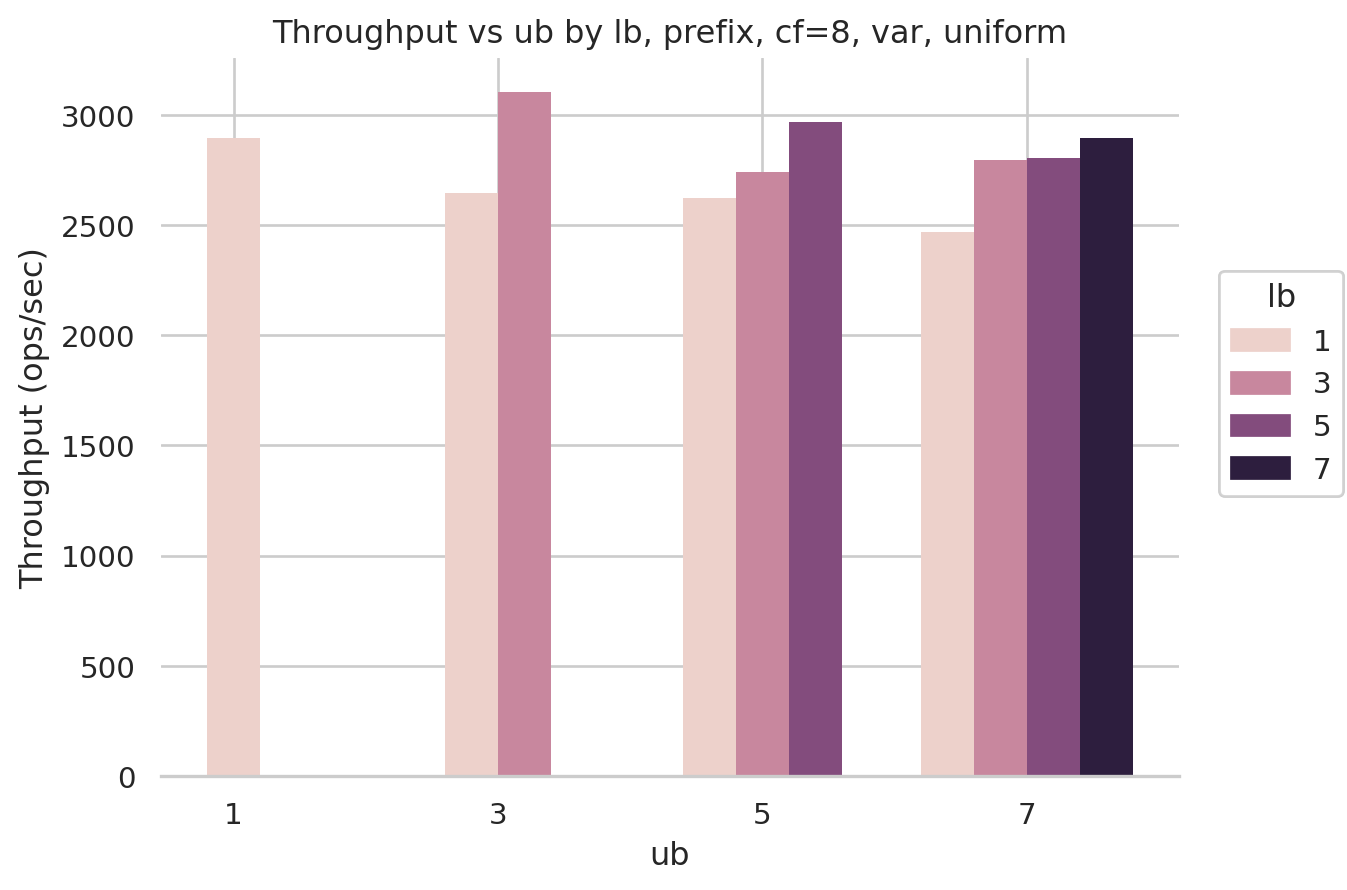

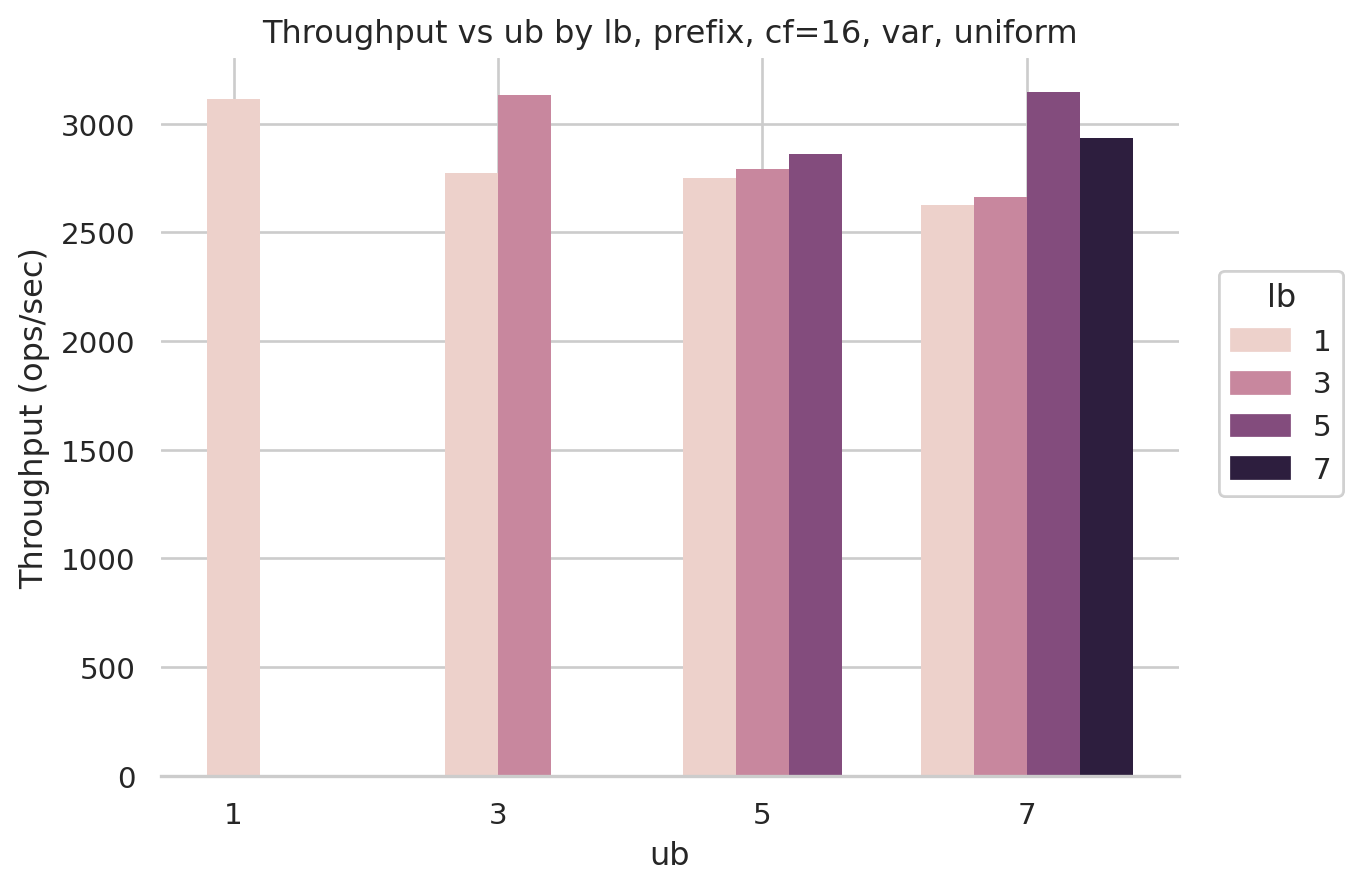

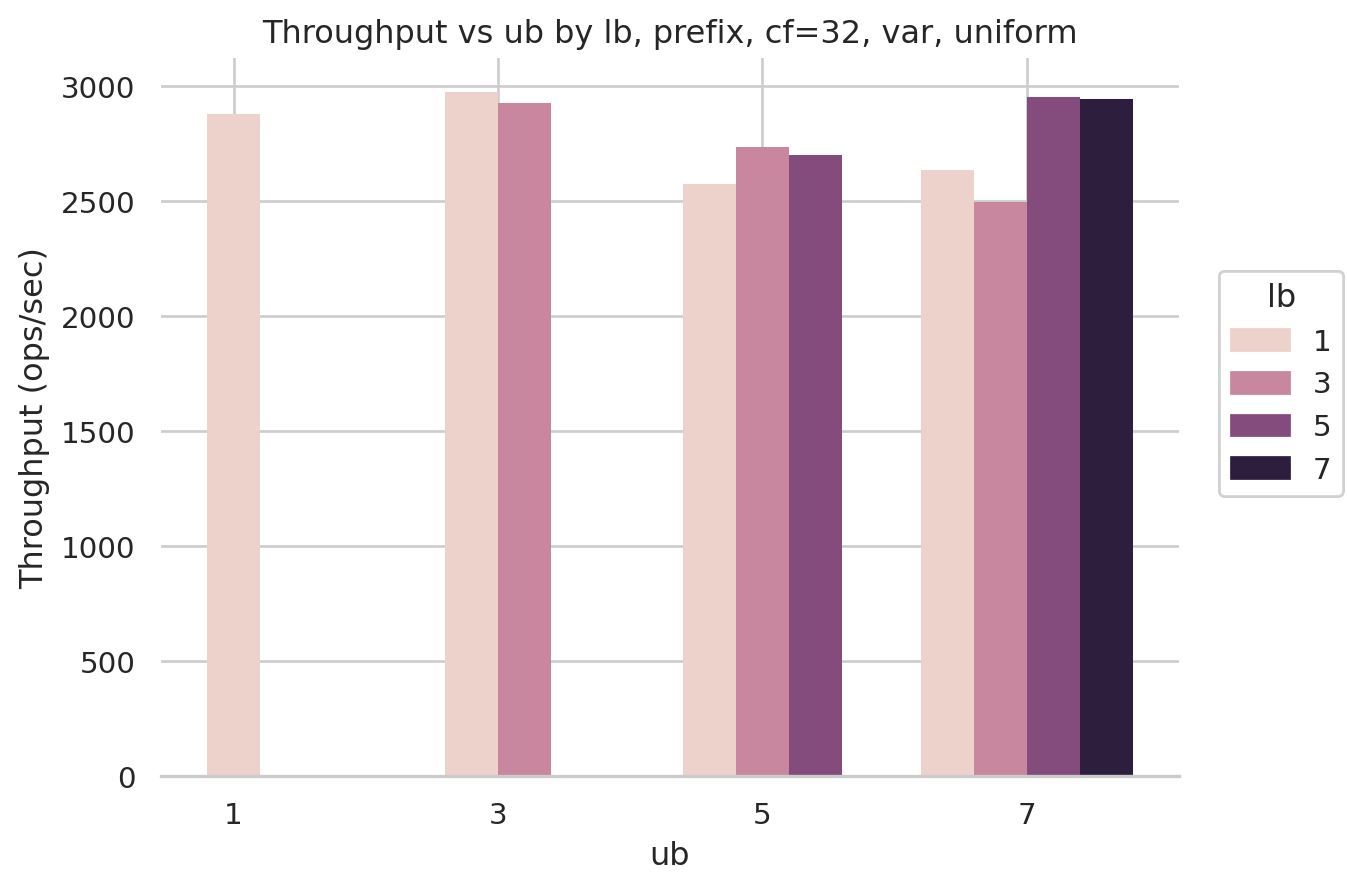

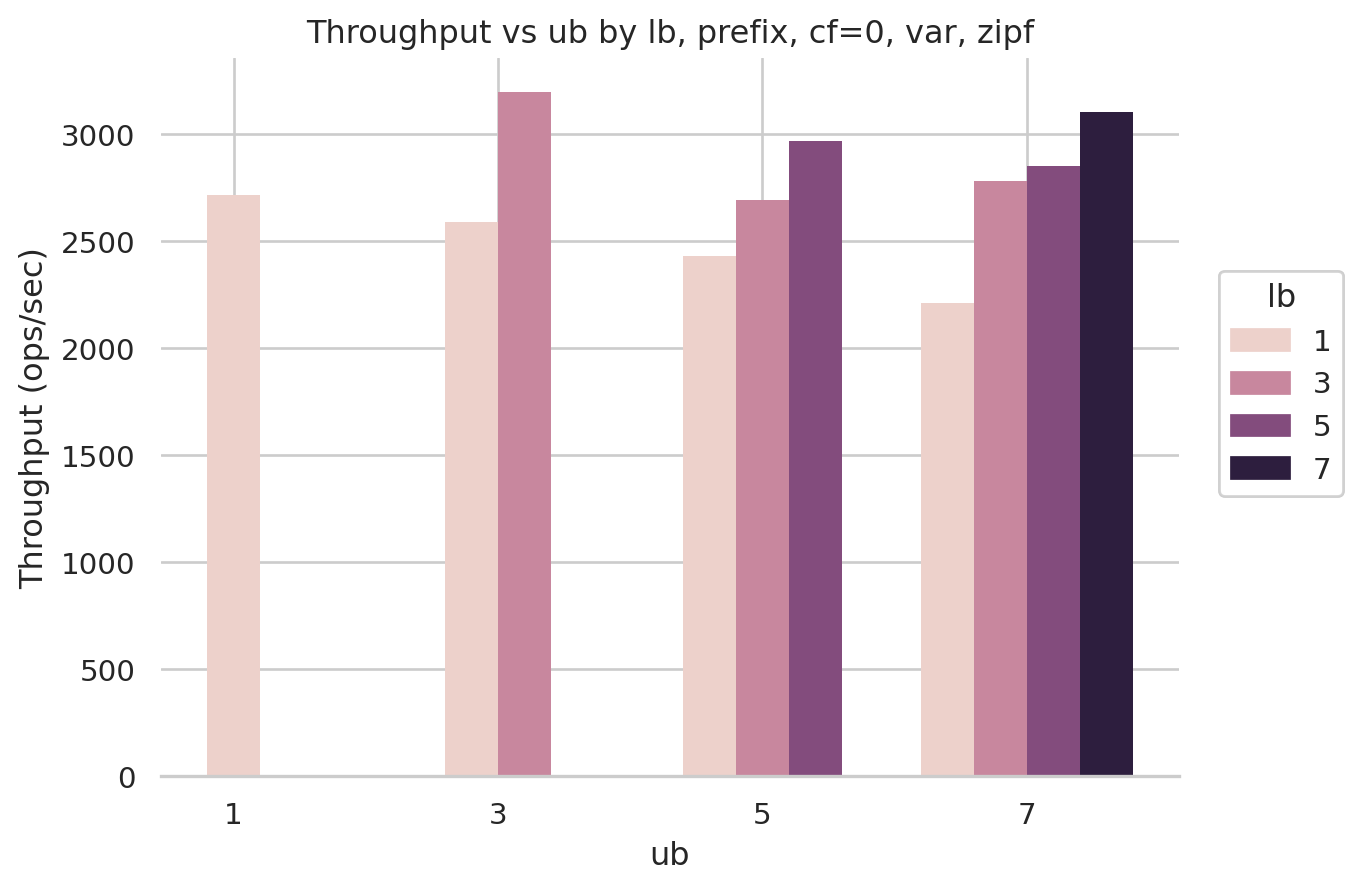

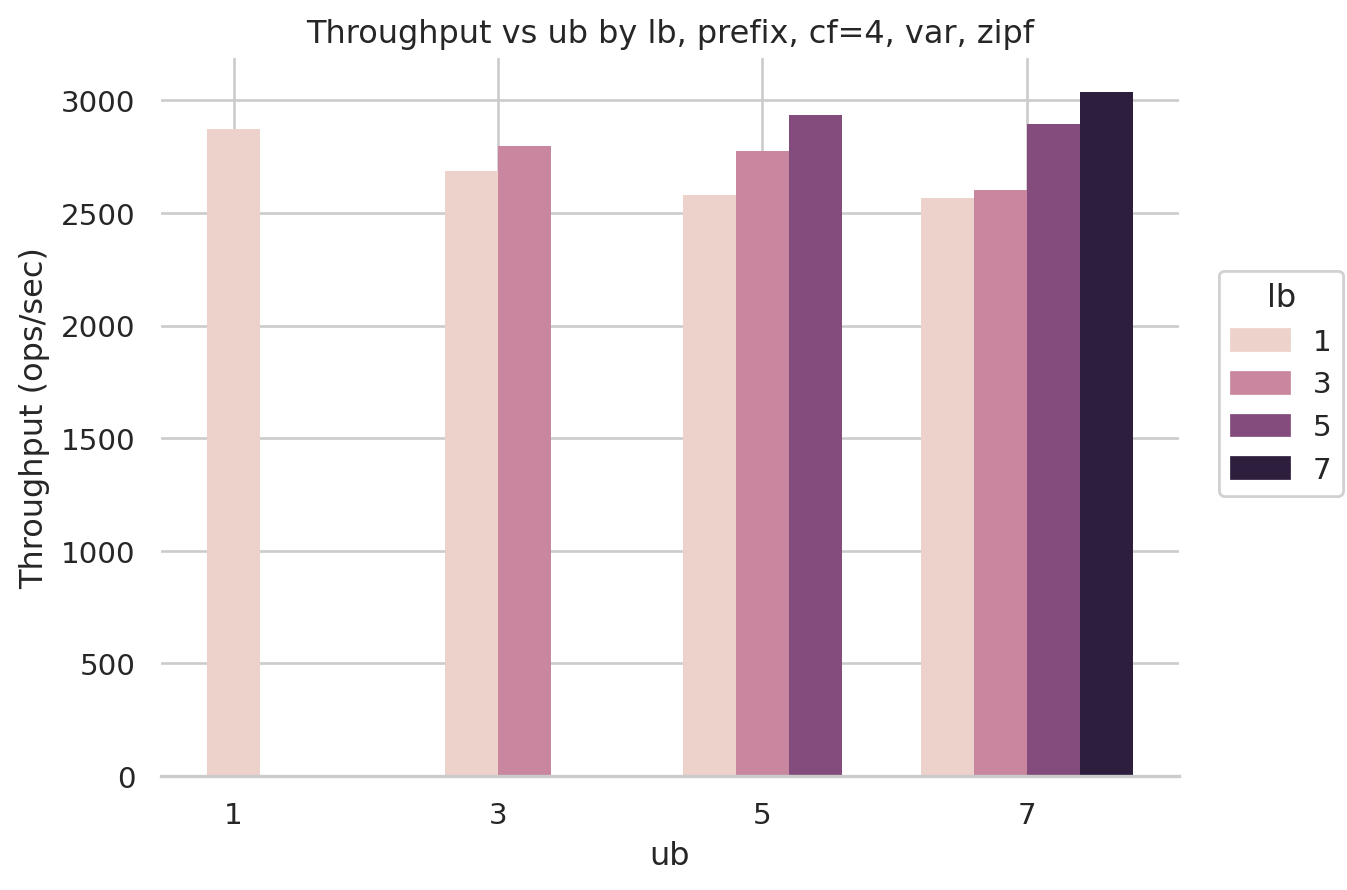

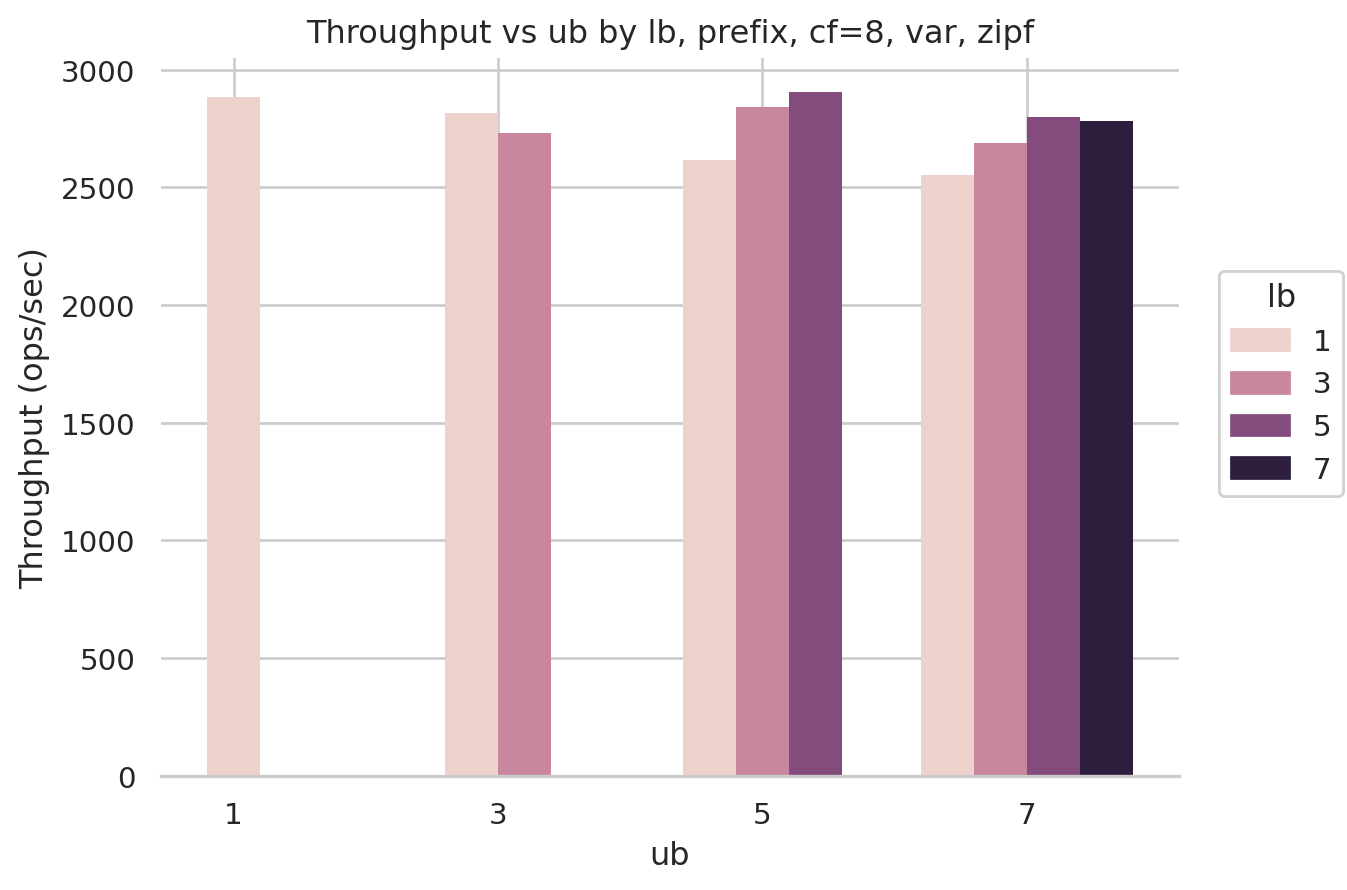

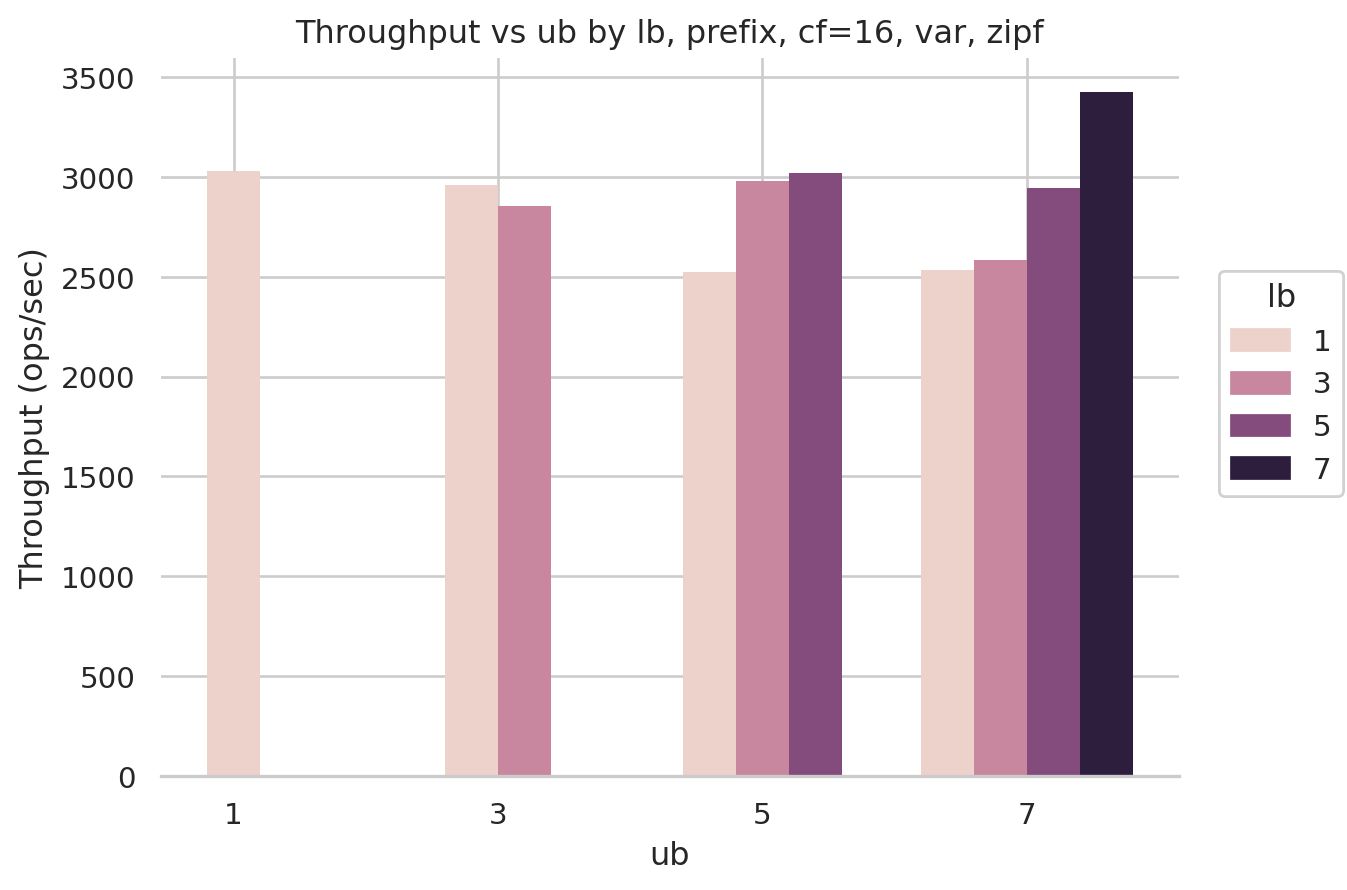

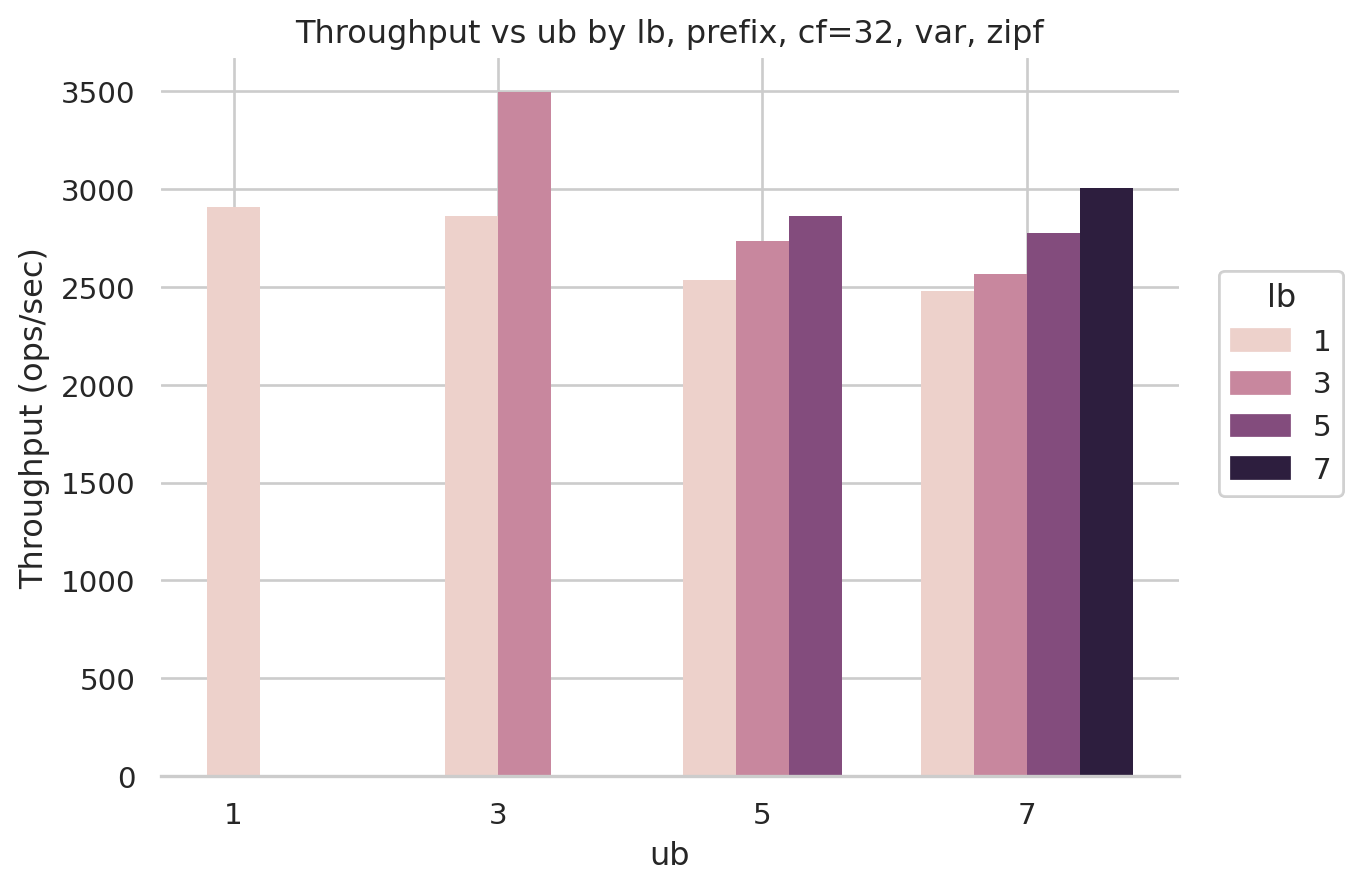

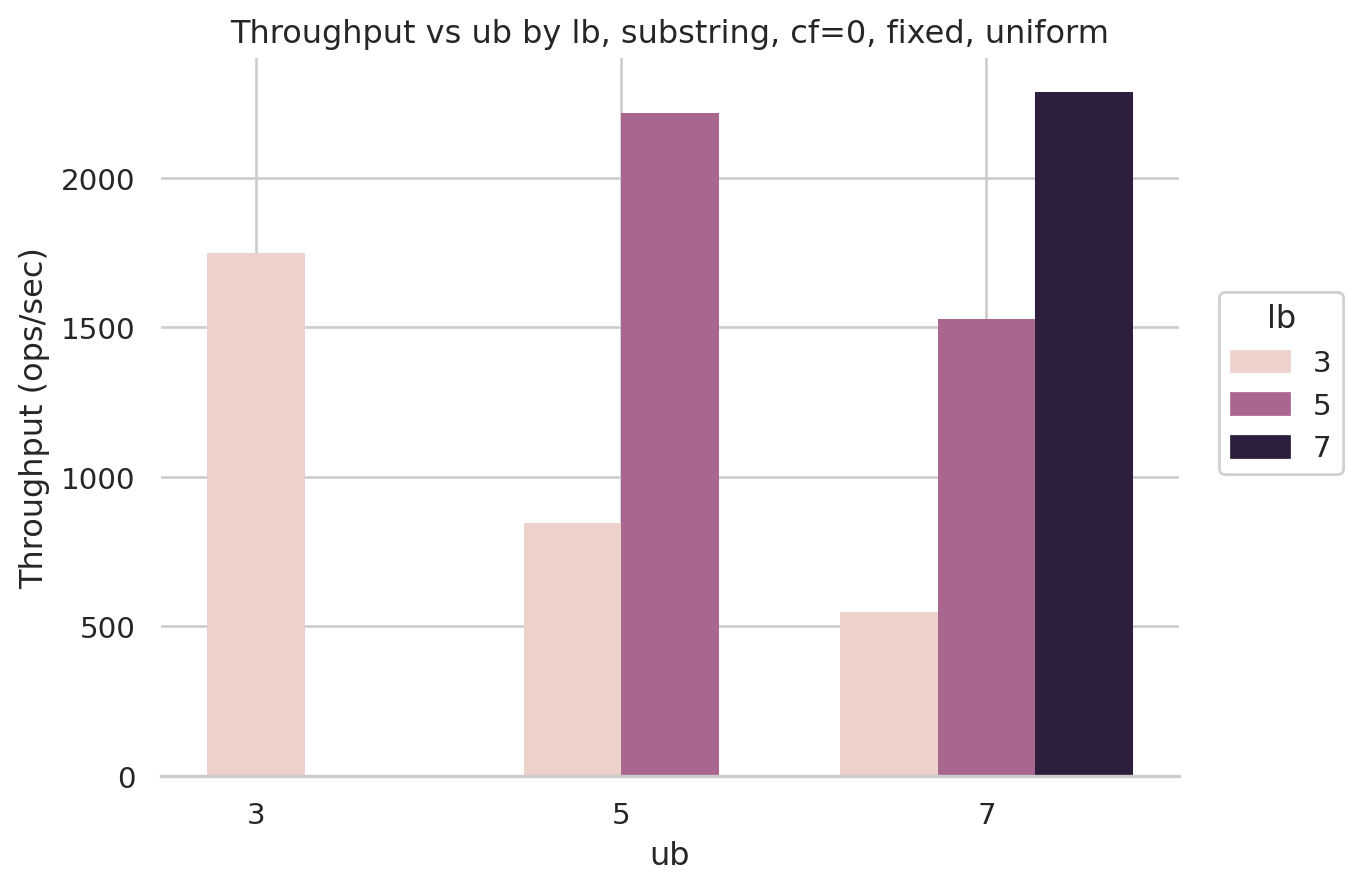

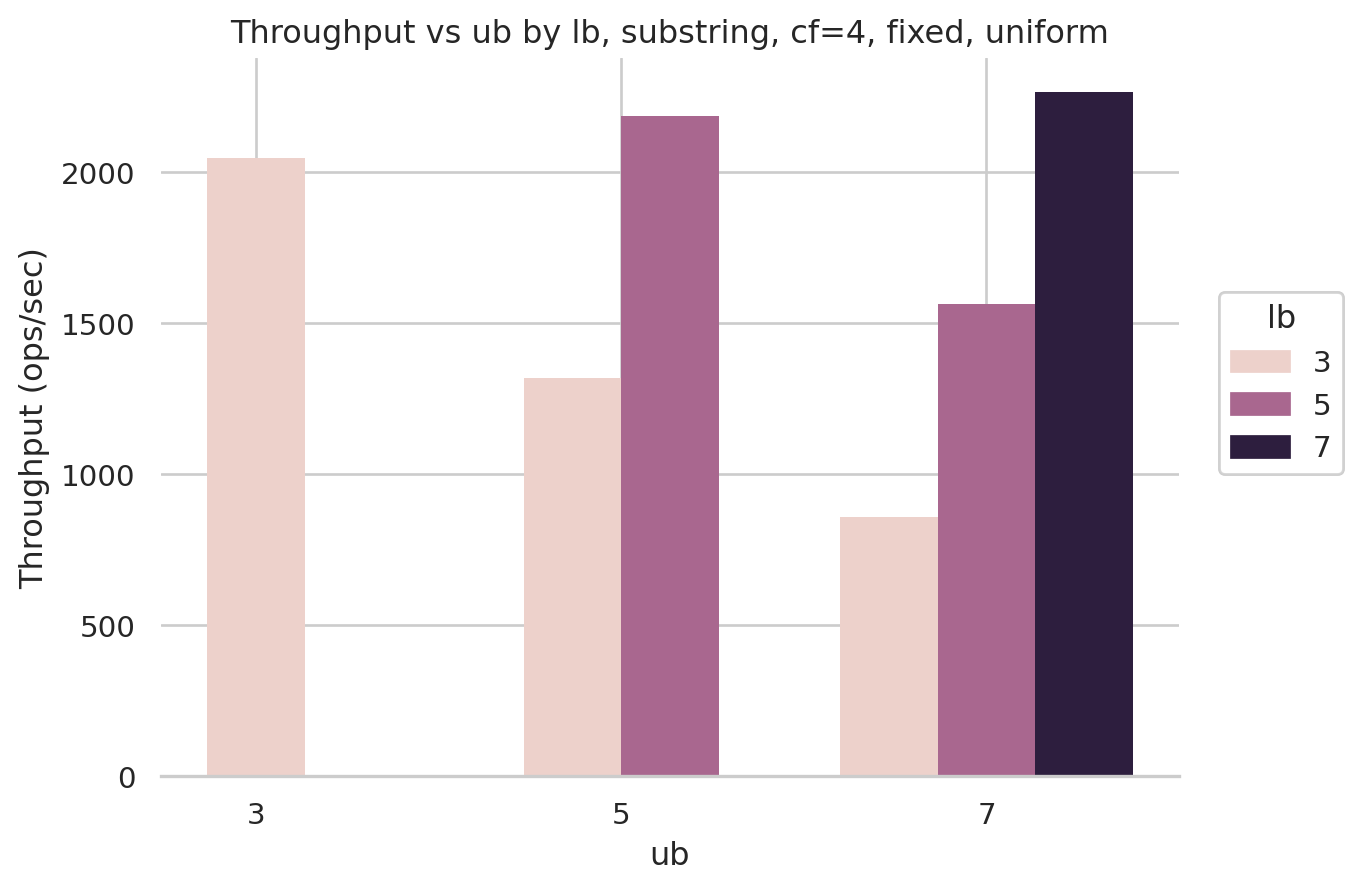

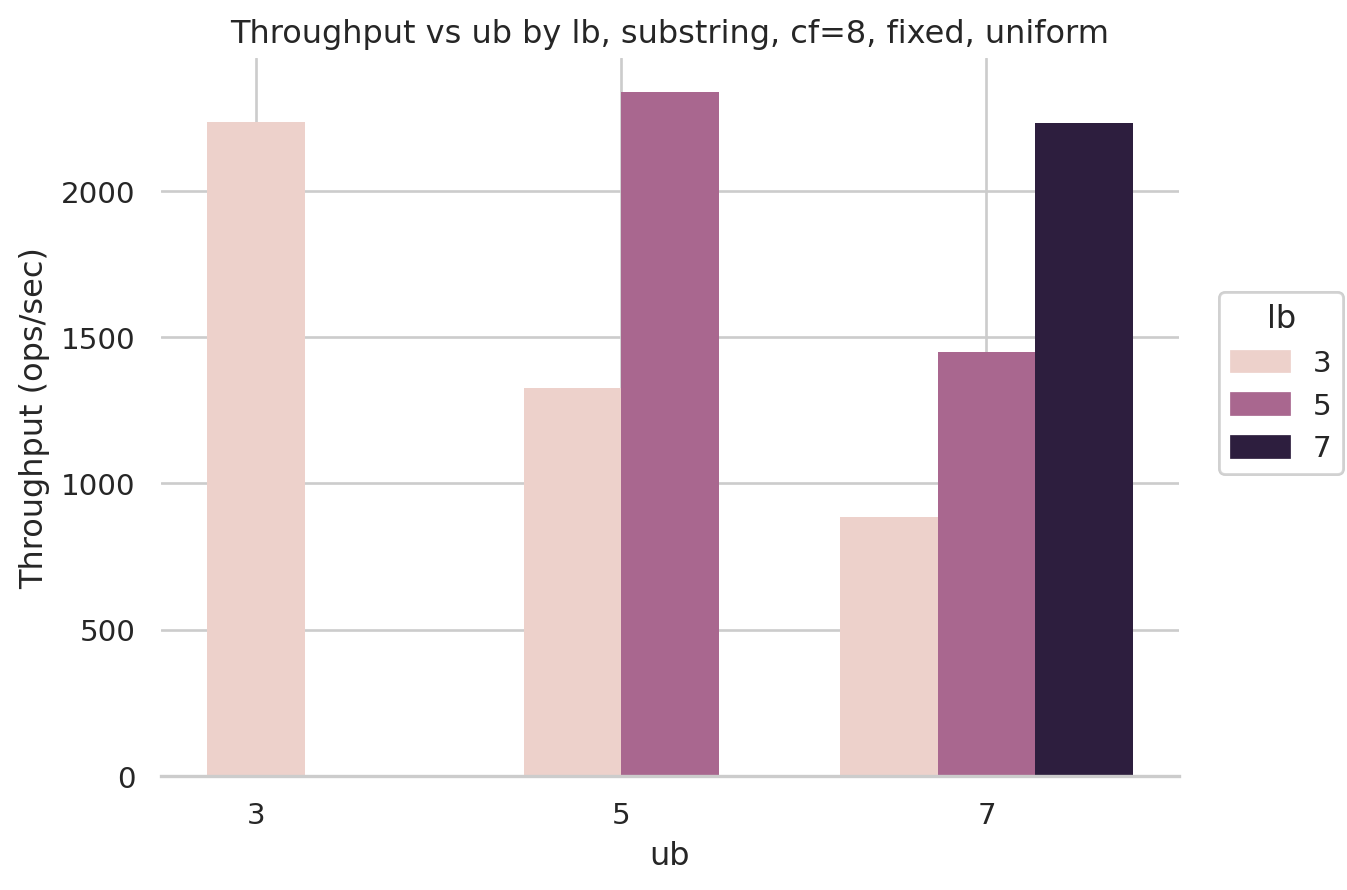

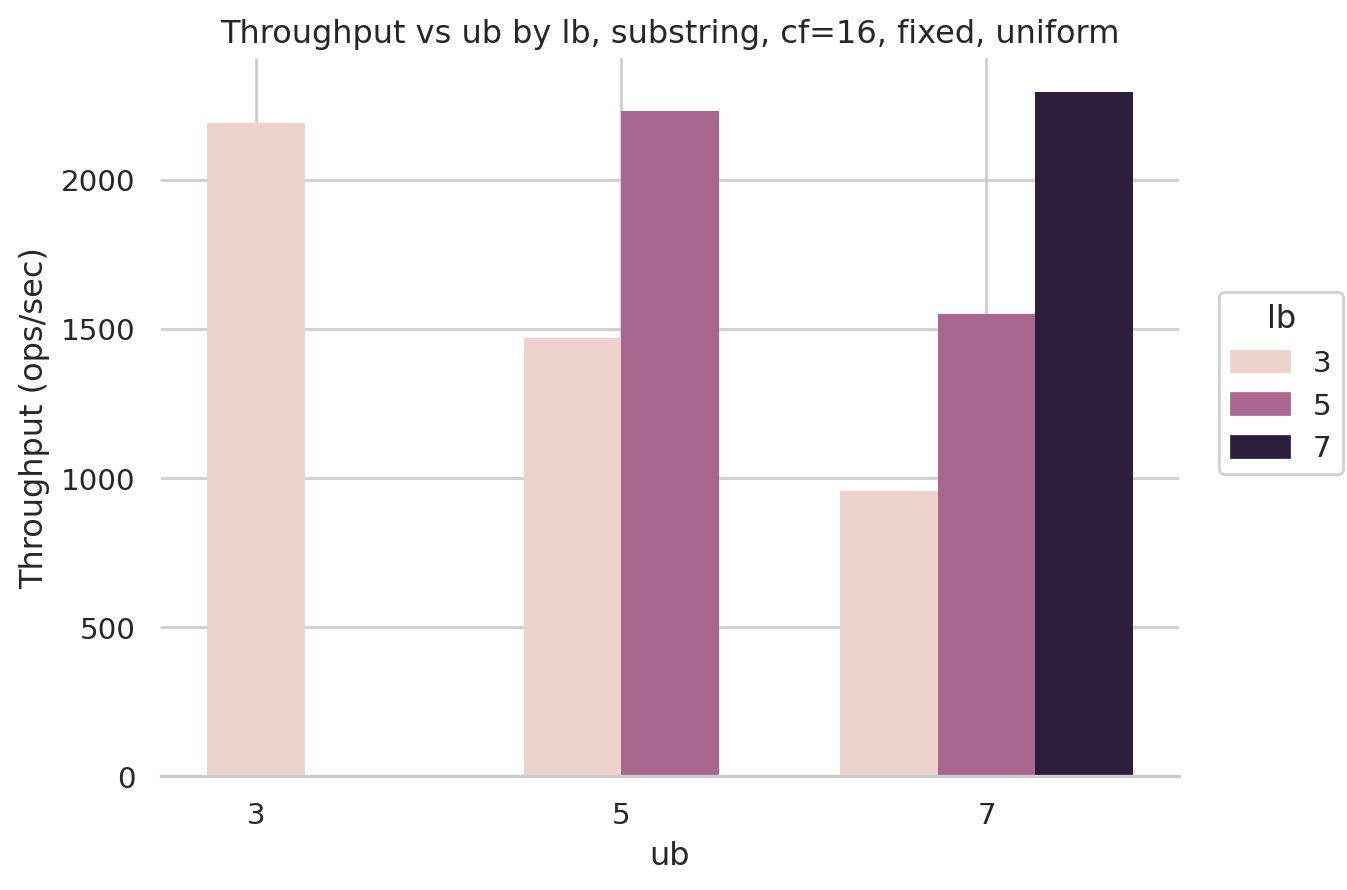

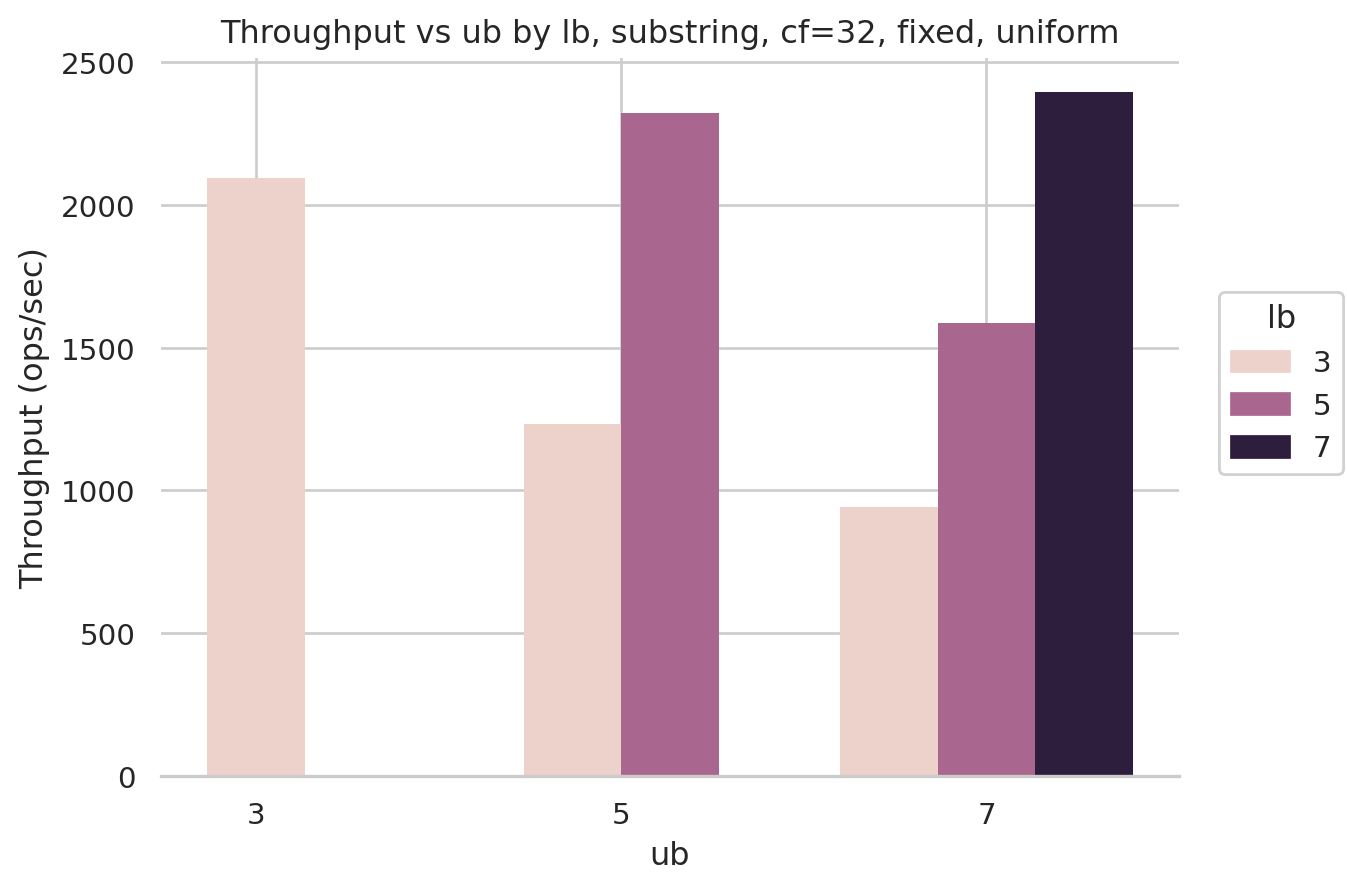

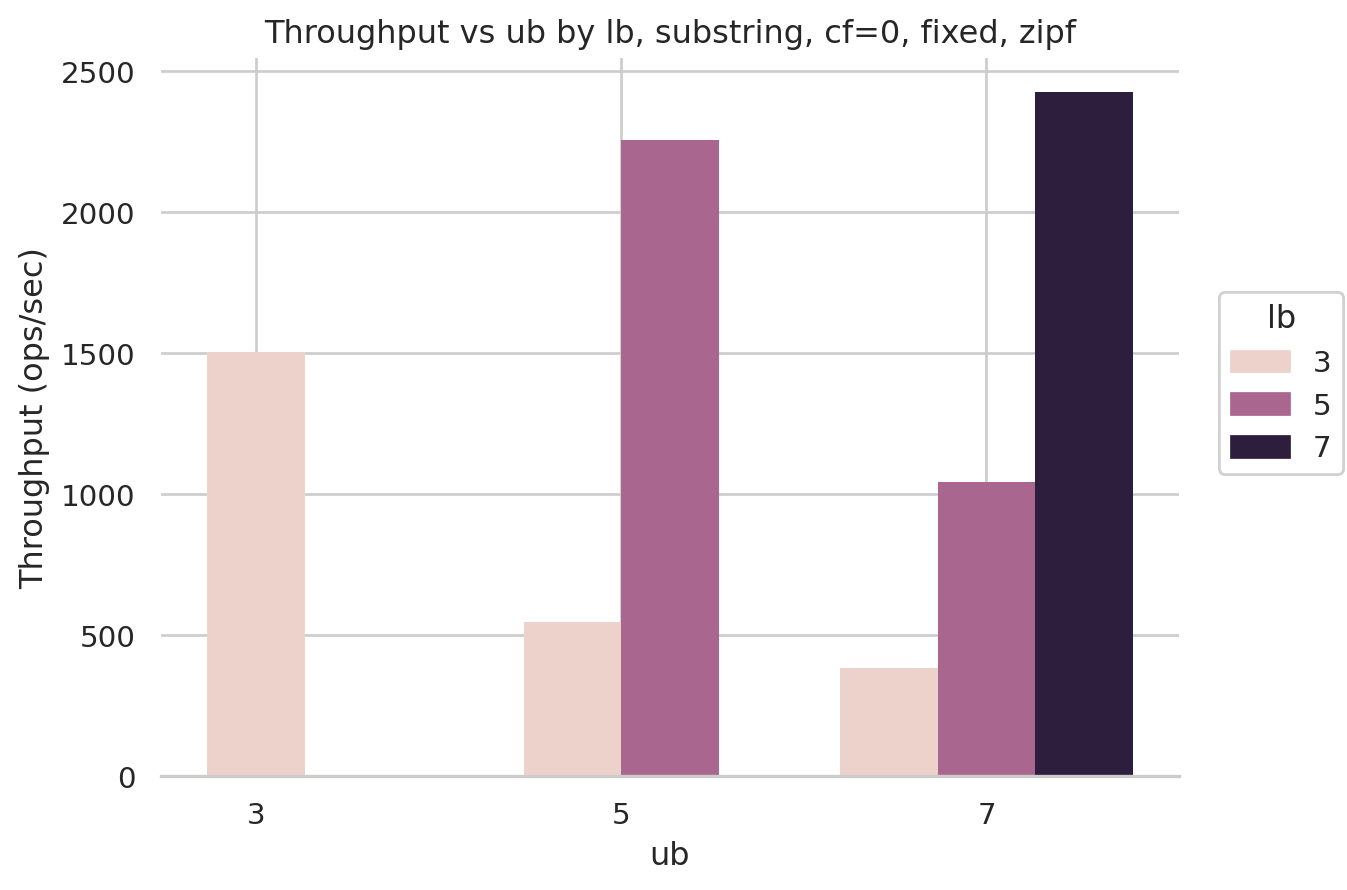

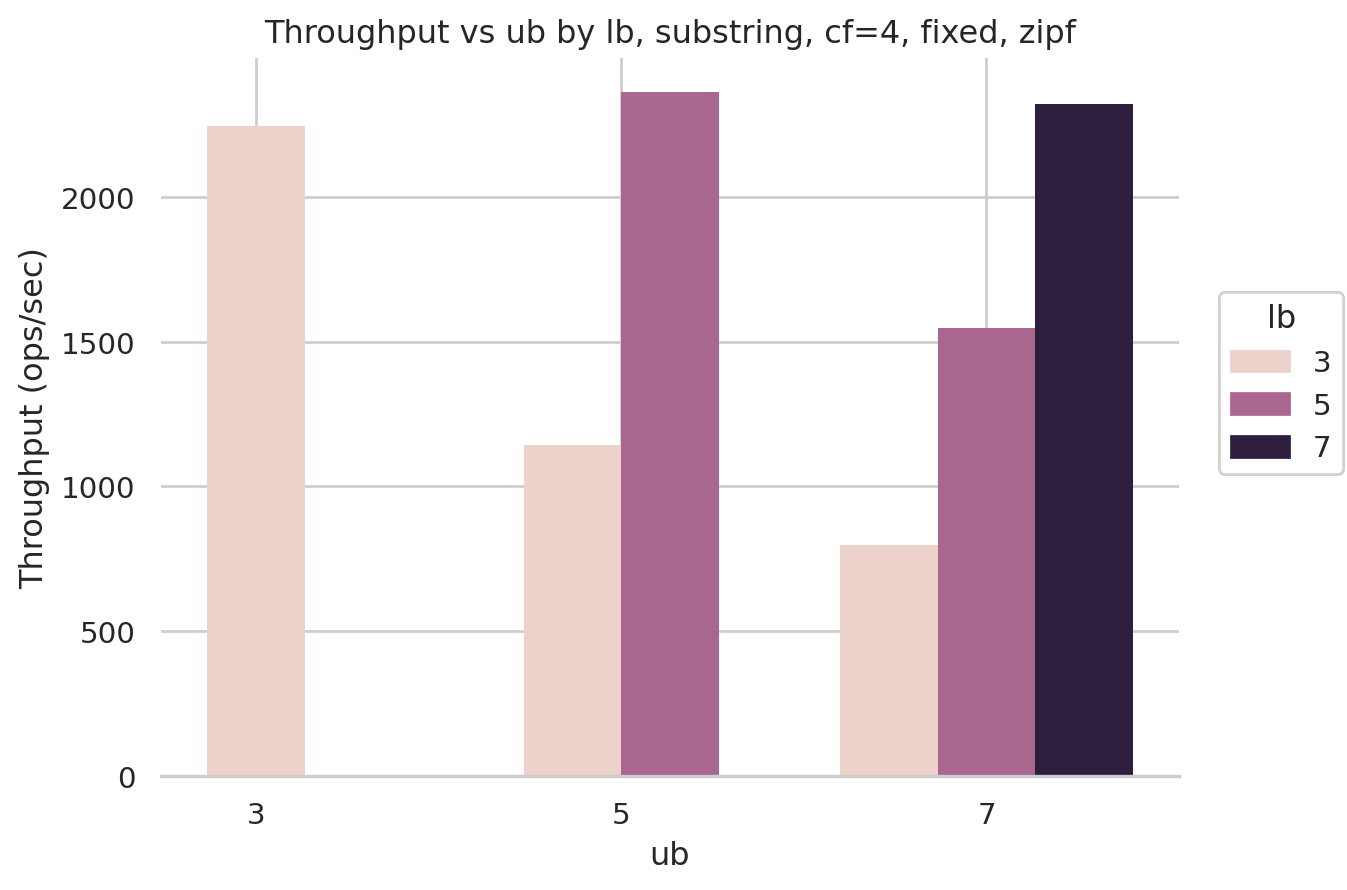

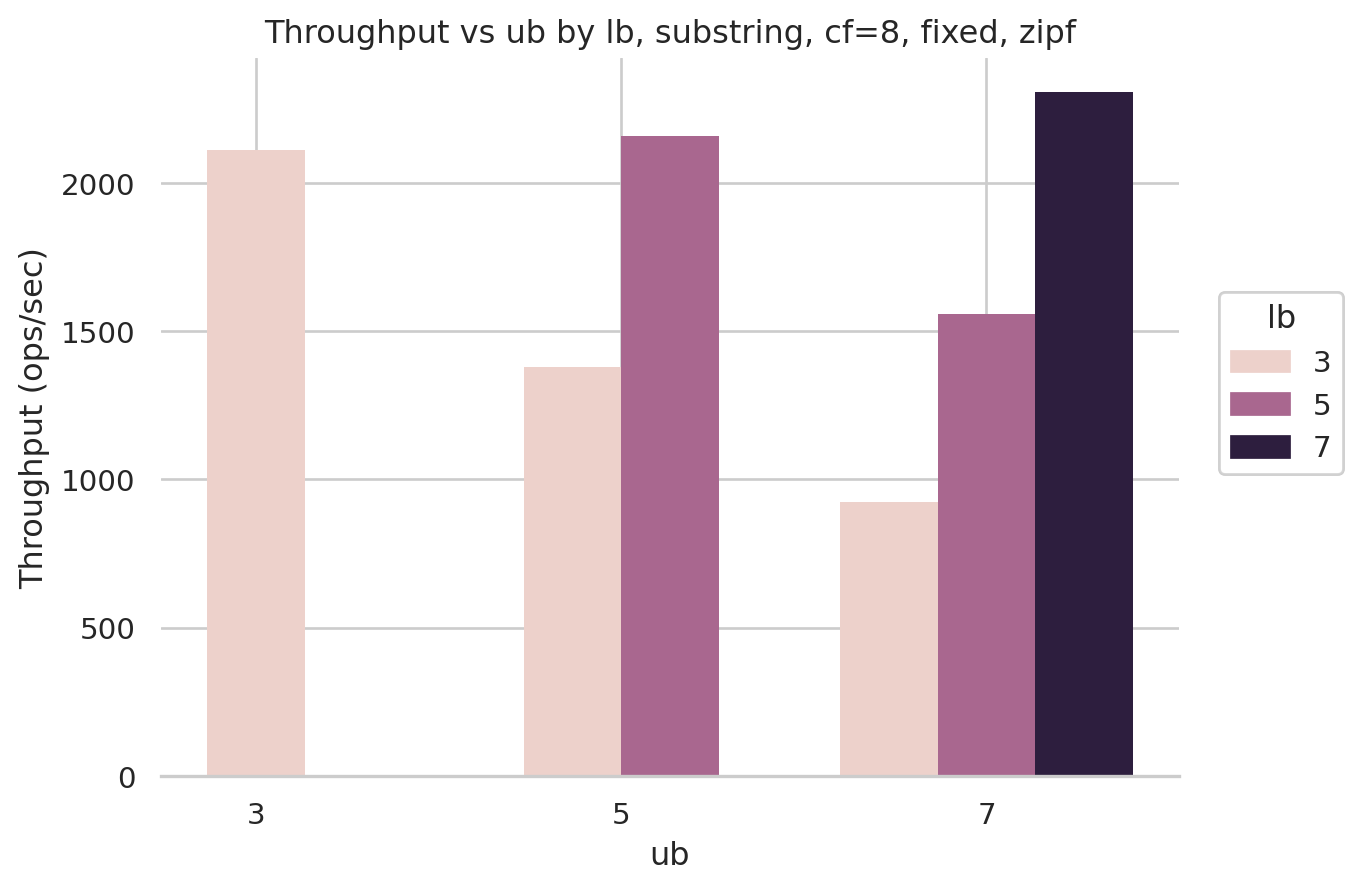

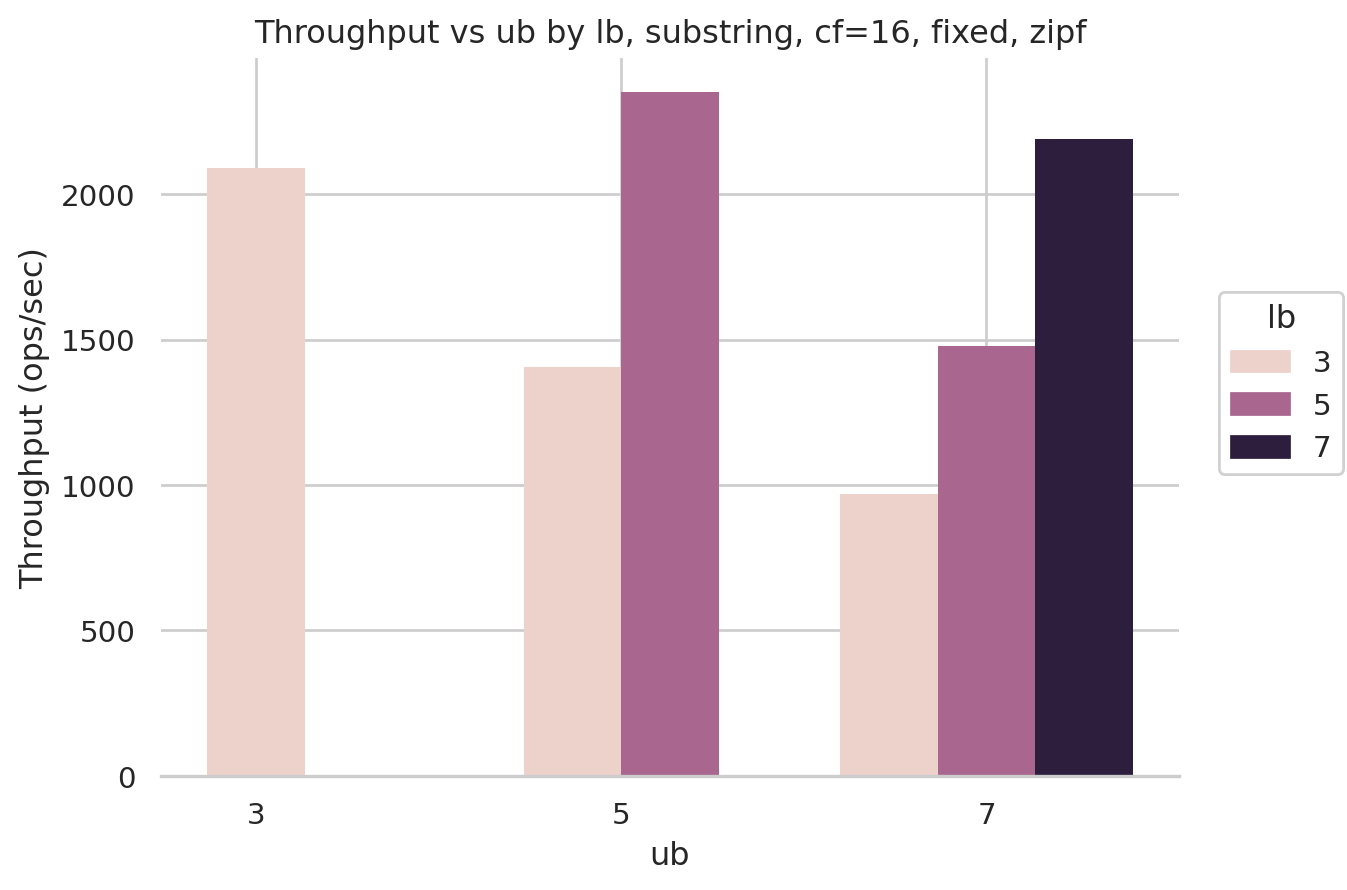

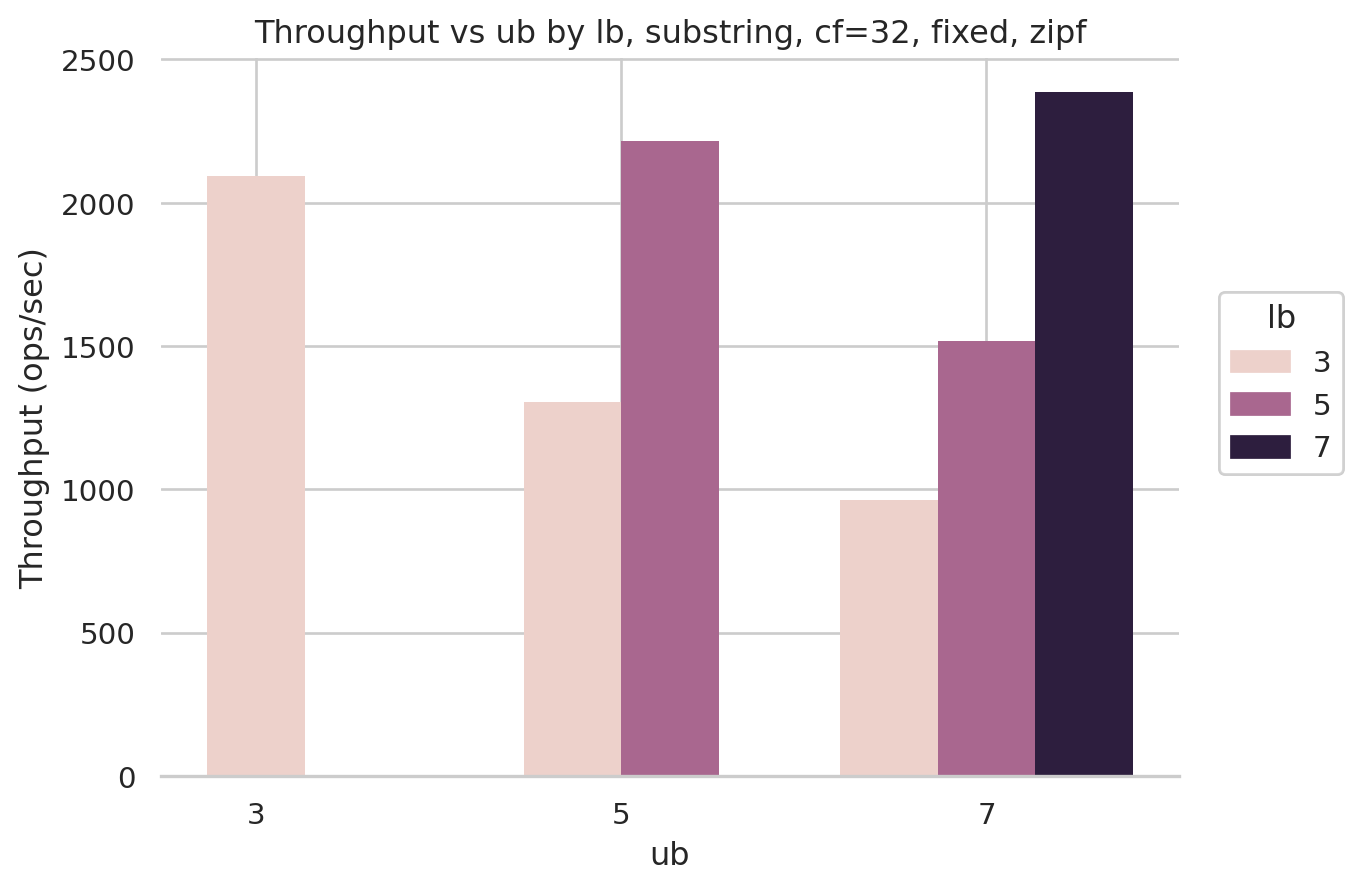

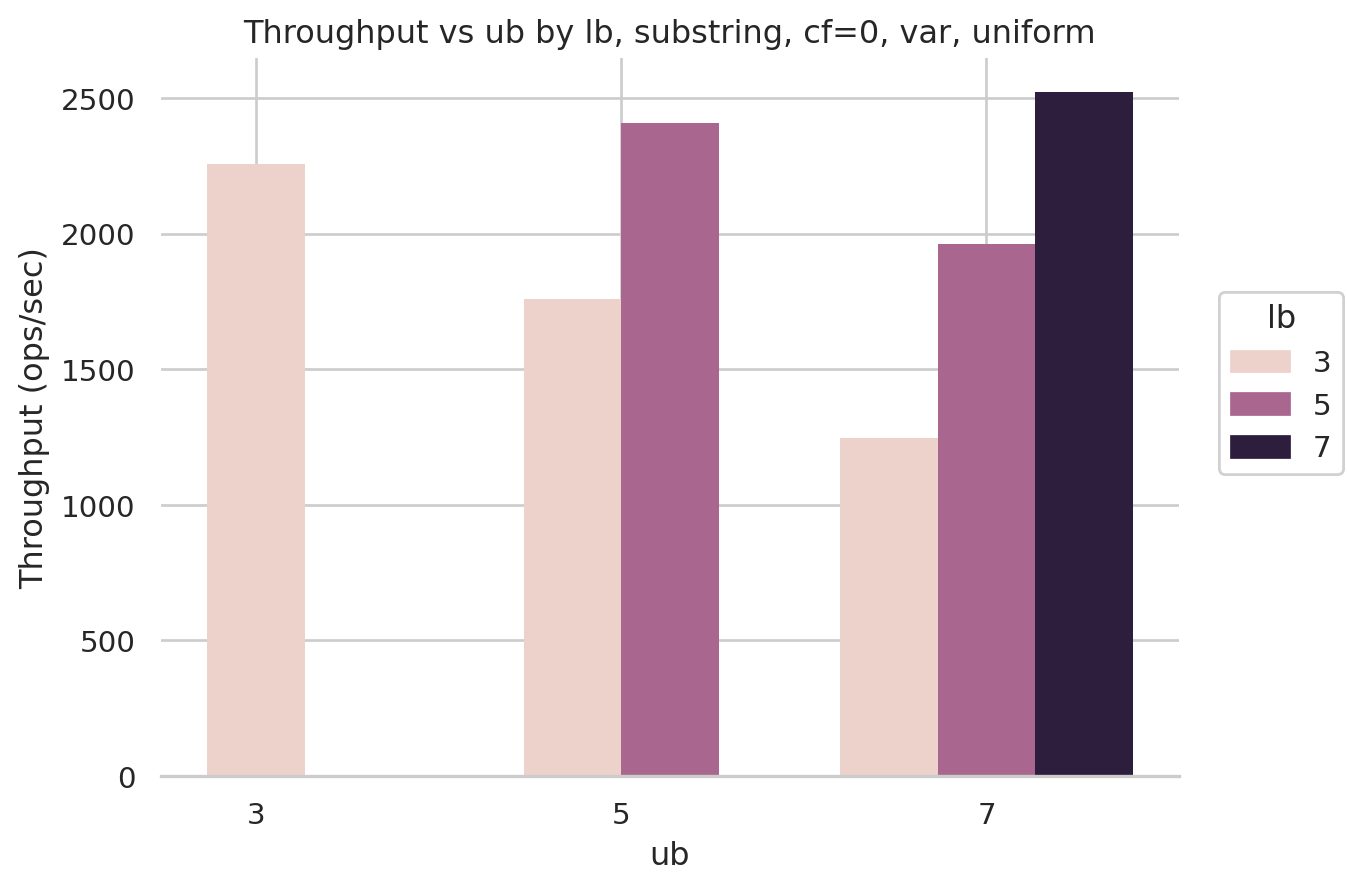

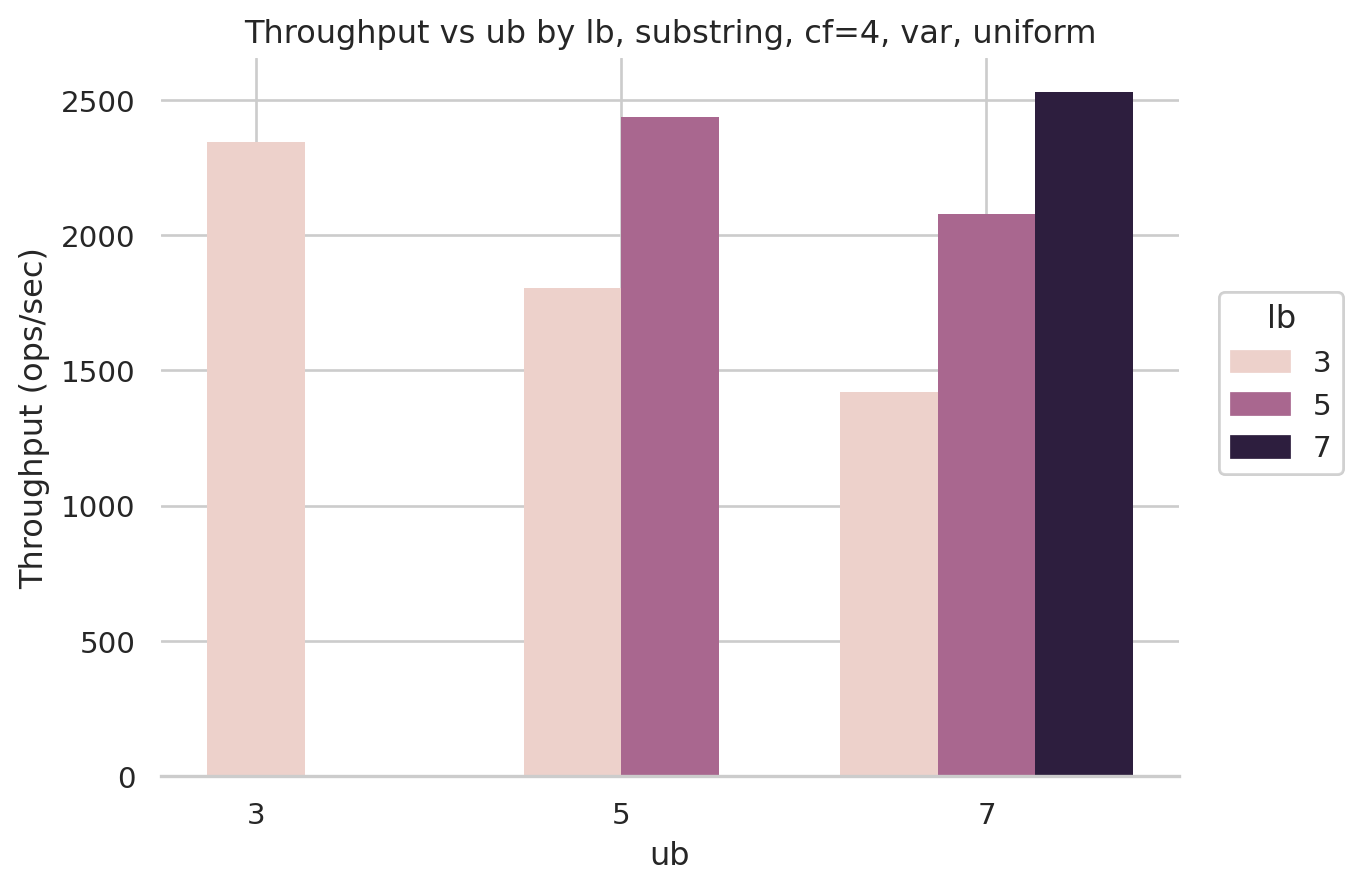

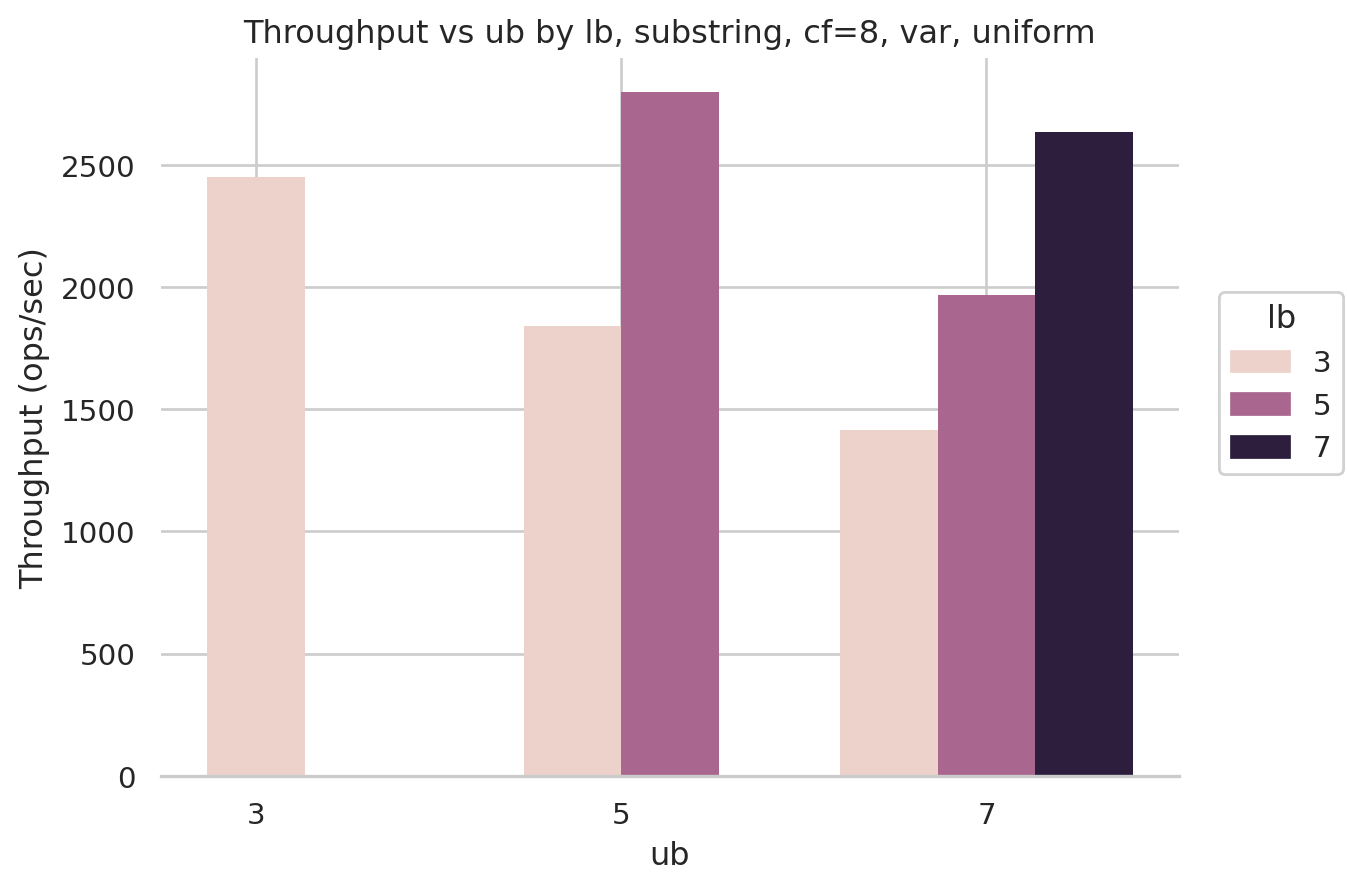

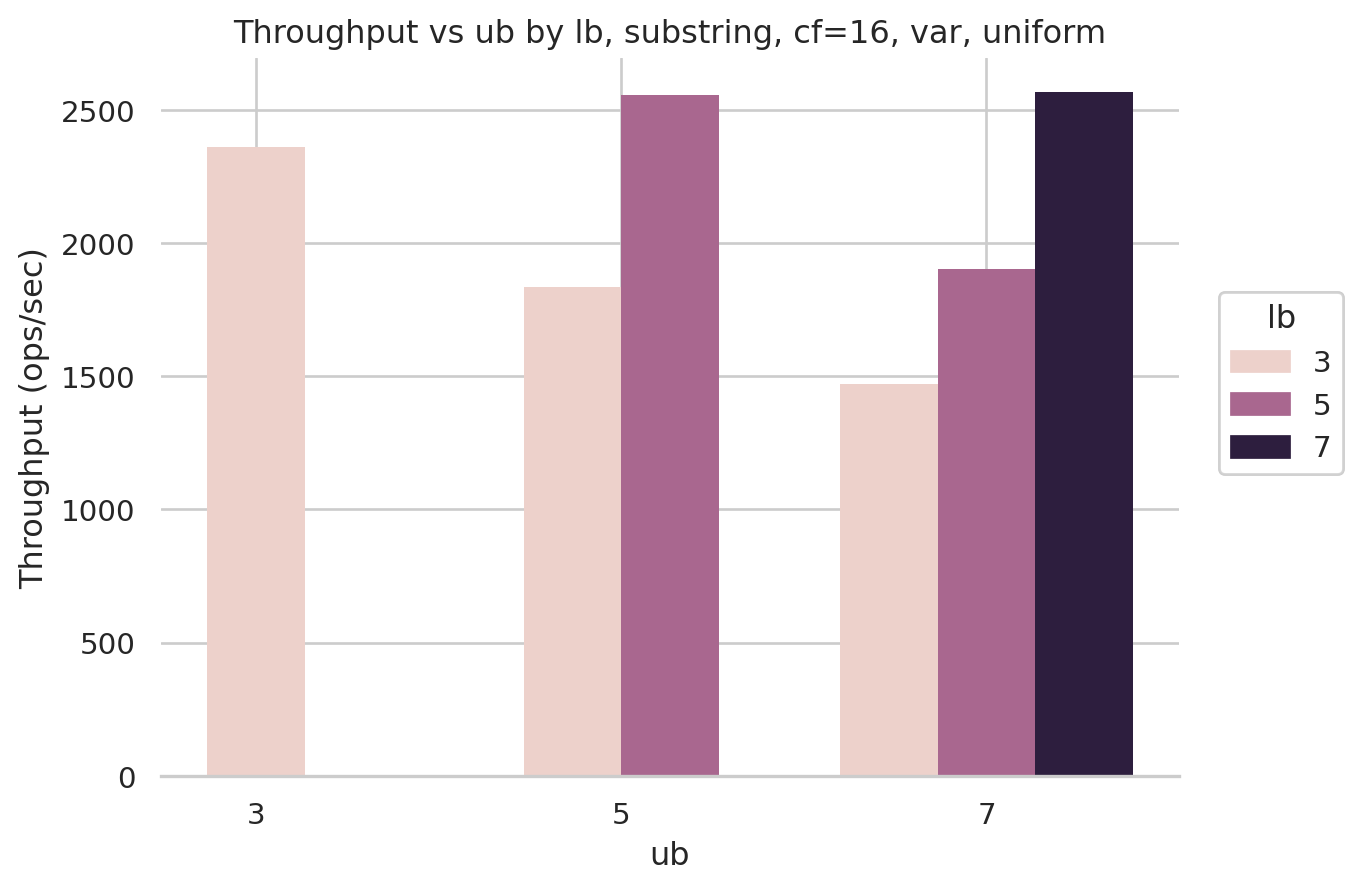

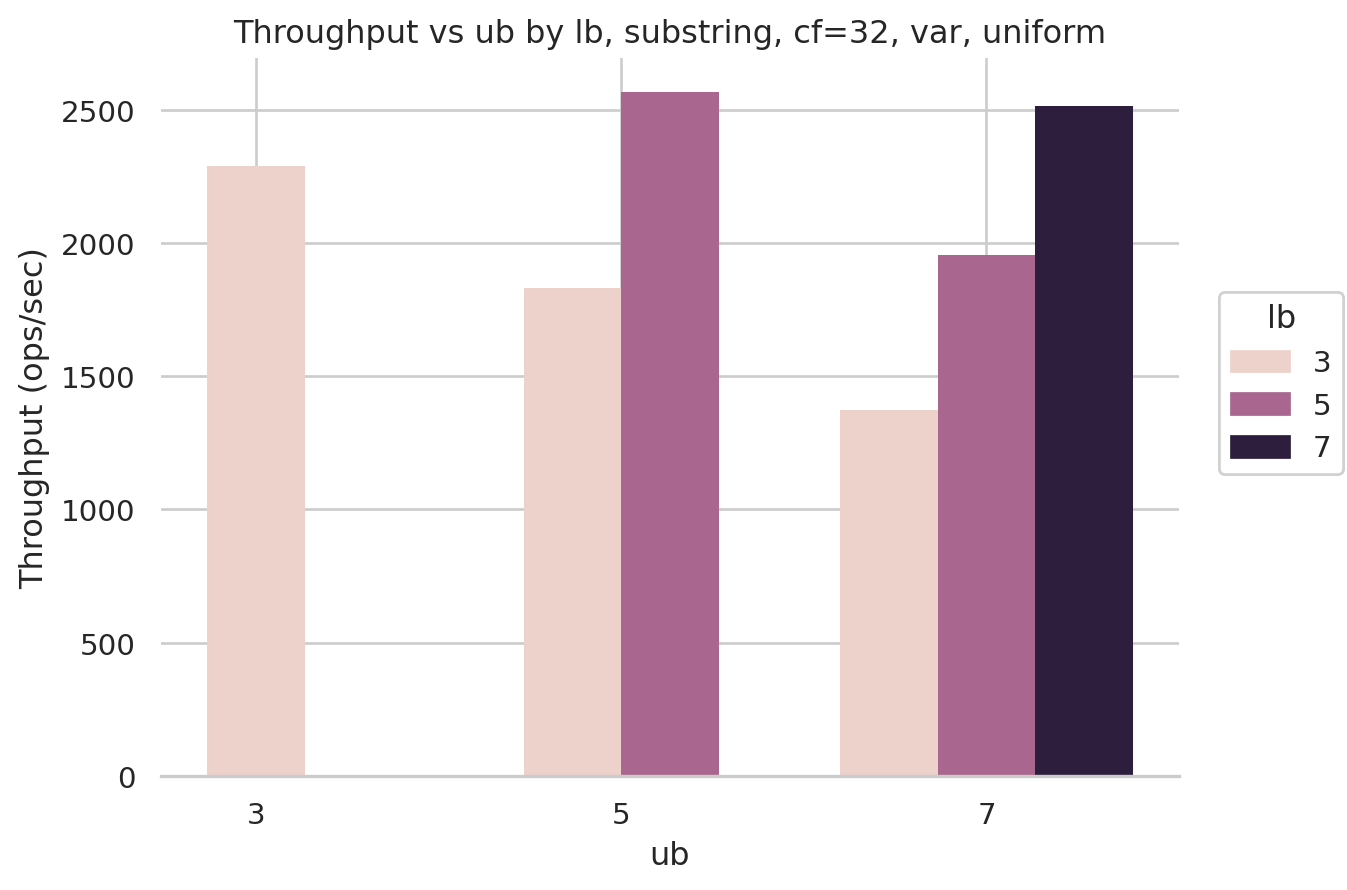

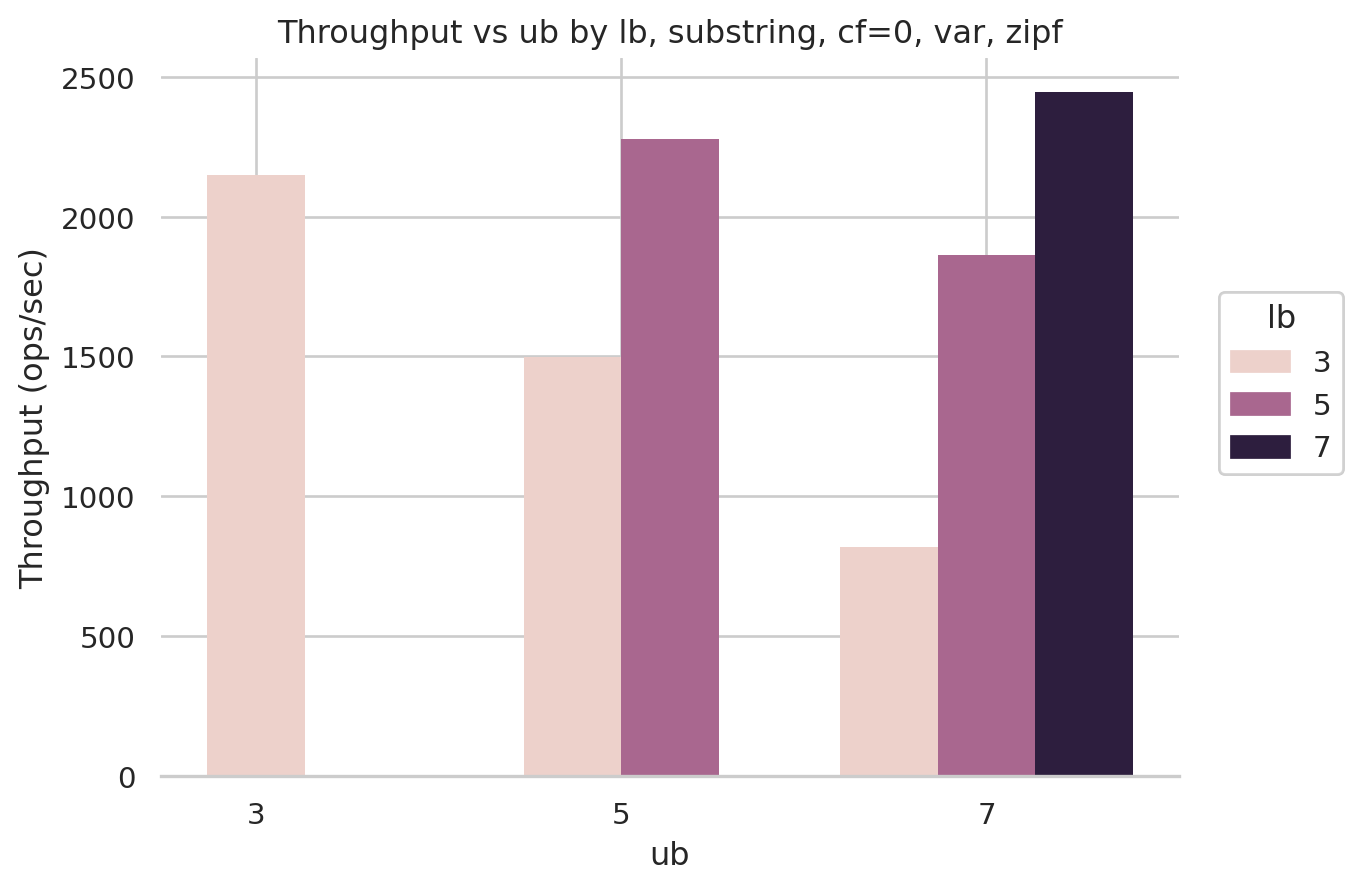

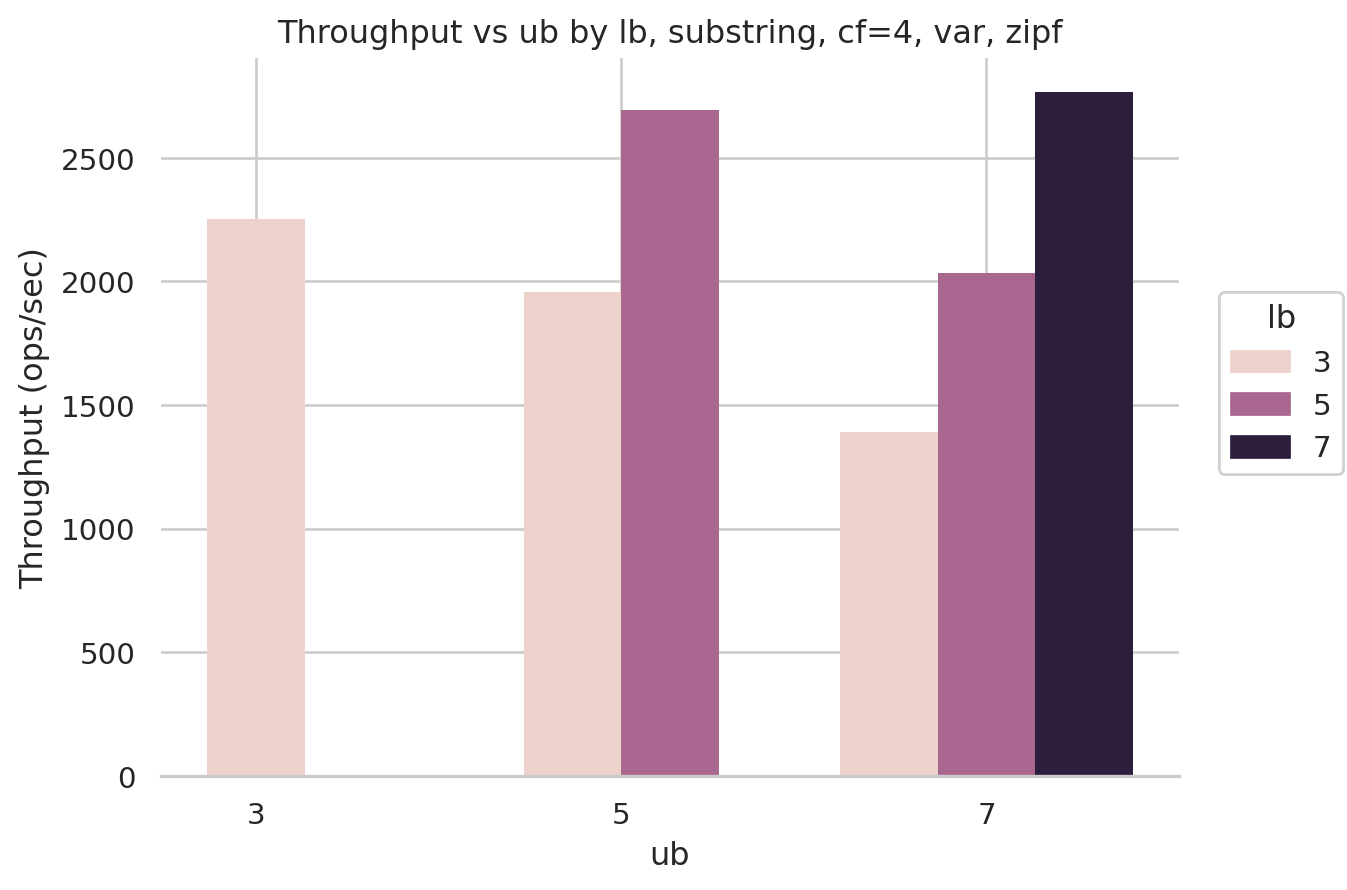

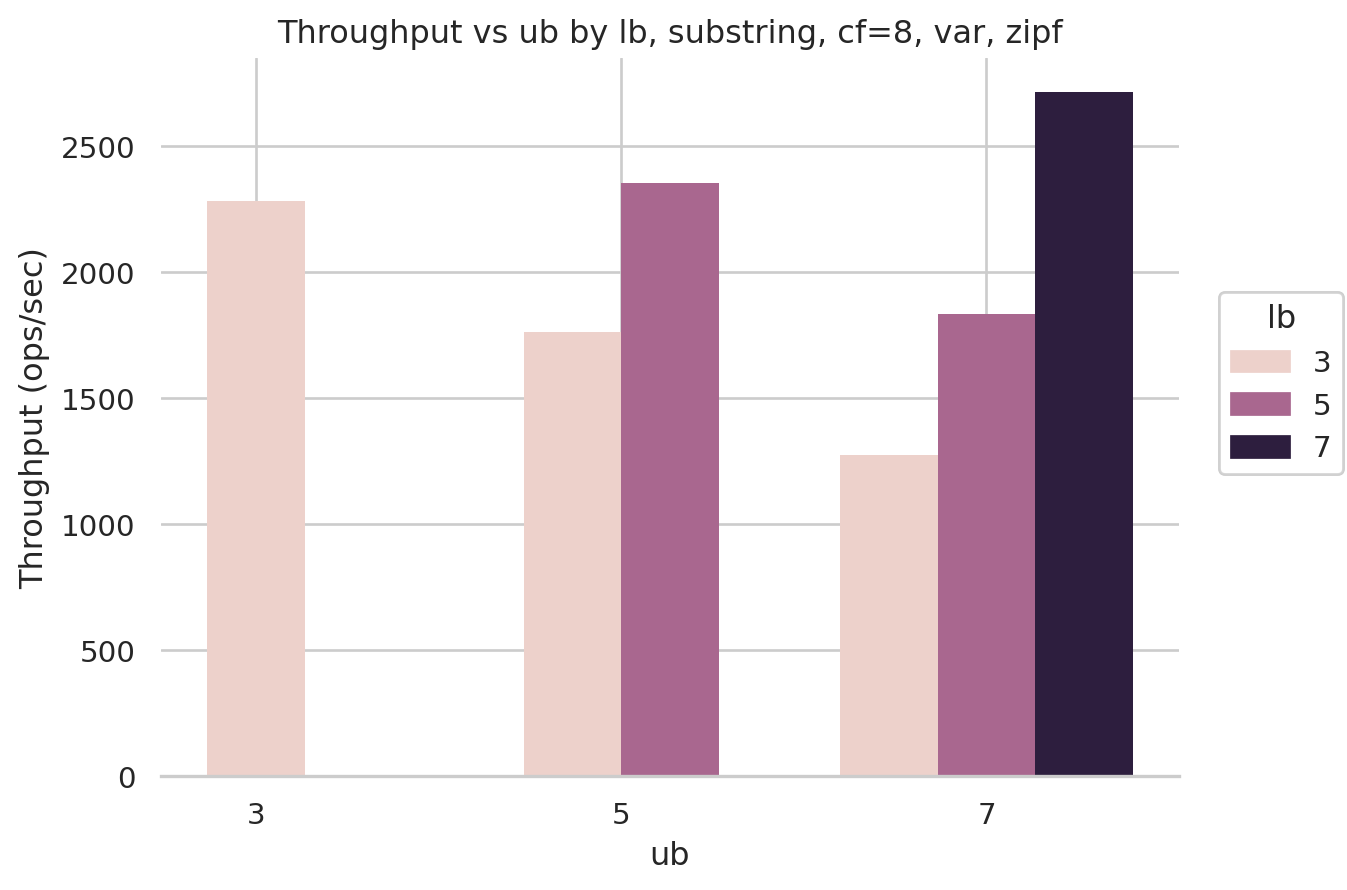

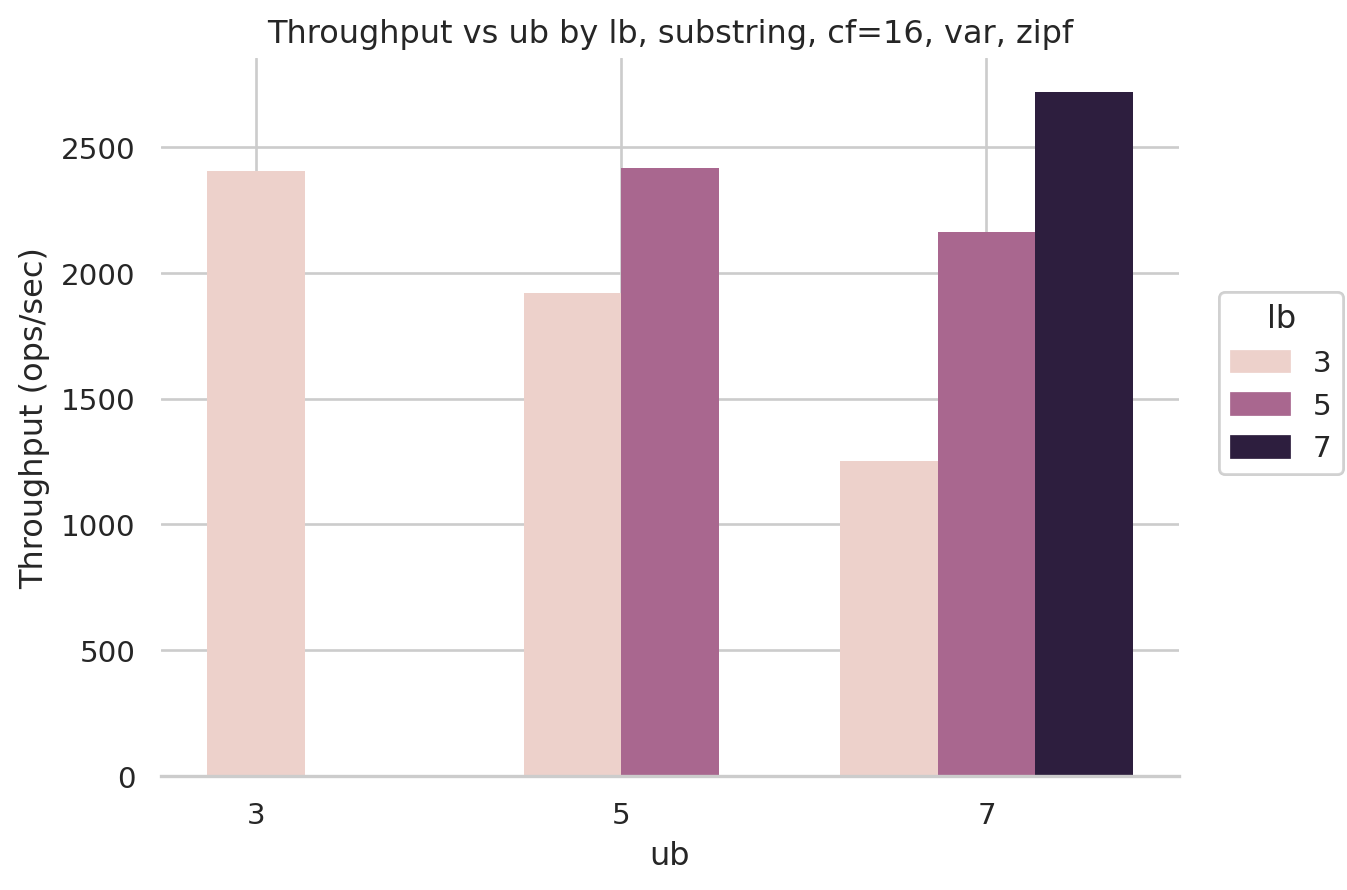

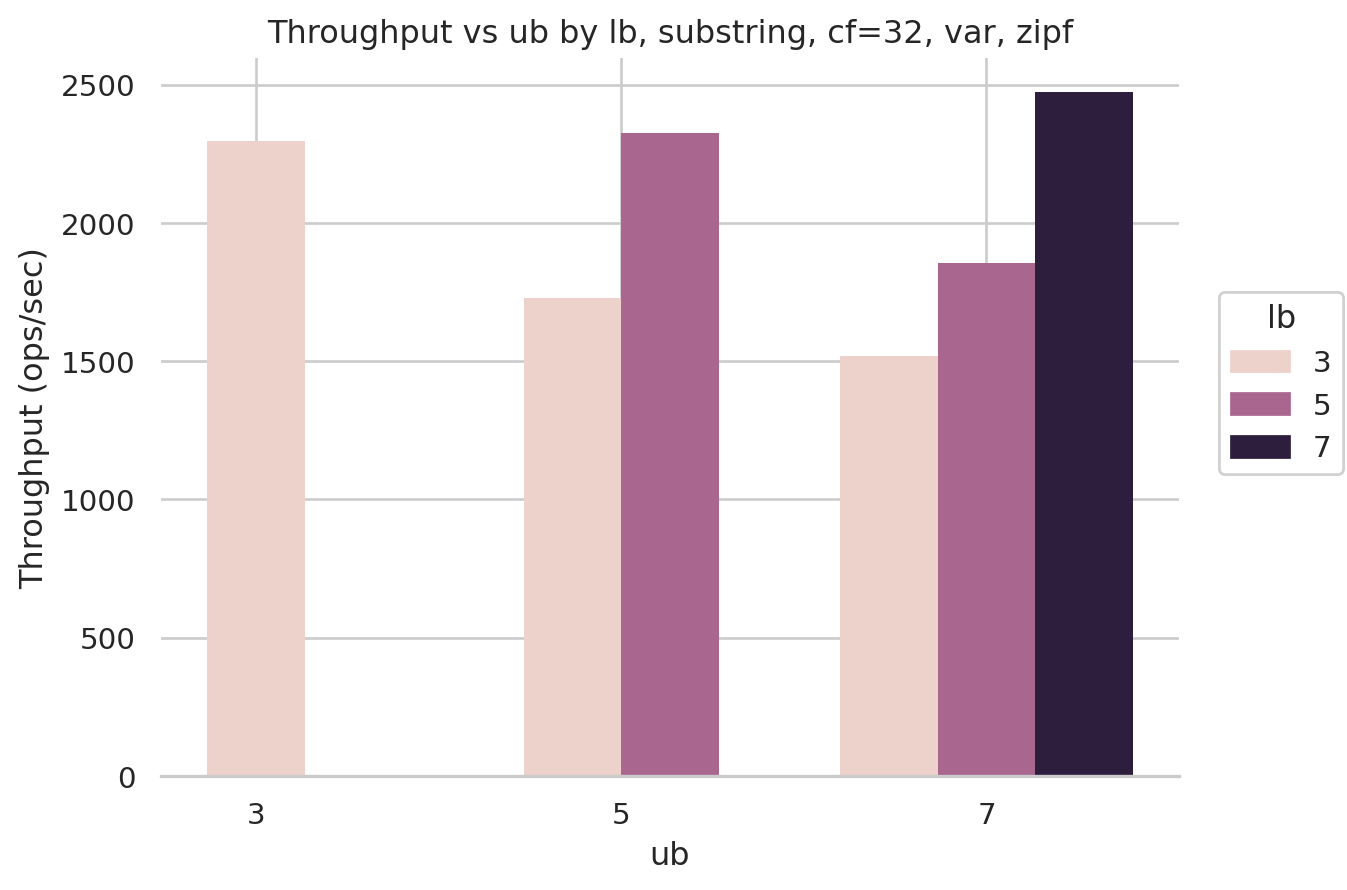

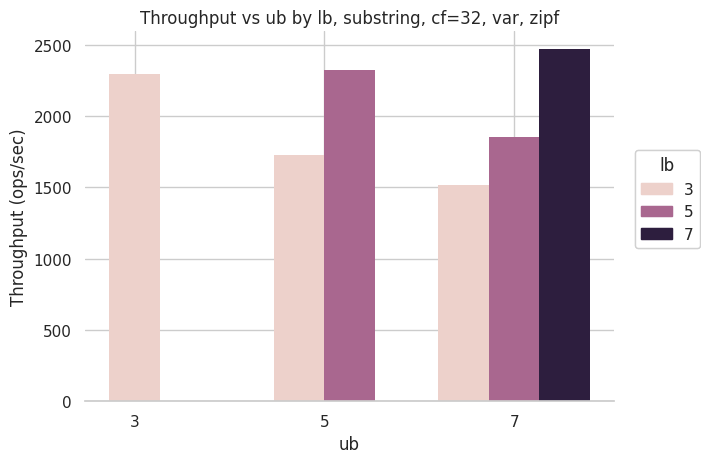

In [295]:
# Graph i3
for typ in ('prefix', 'substring'):
    for collname in (enc_stats['var_or_fixed'] + ', ' + enc_stats['zipf_or_uniform']).unique():
        for cf in (0, 4, 8, 16, 32):
            lowest_lb = 1 if typ == 'prefix' else 3
            stats = enc_stats.copy()
            stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
            stats = stats[(stats['ss_or_pref'] == typ) & (stats['cf'] == cf) & (stats['collname'] == collname)].copy()
            stats['tp'] = 16. * 1e9 / stats['lat_avg']
            
            title = f'Throughput vs ub by lb, {typ}, cf={cf}, {collname}'
            plt.close()
            ax = plt.gca()
            p = so.Plot(stats, x='ub', y='tp', color='lb')
            p = p.add(so.Bar(alpha=1), so.Dodge(empty='drop'))
            p = p.label(title=title, x='ub', y='Throughput (ops/sec)', color='lb')
            p = p.theme(sns.axes_style(style='whitegrid'))
            p = p.layout(engine='tight')
            p = p.scale(x=so.Continuous().tick(at=stats['ub'].unique()), color=so.Continuous().tick(at=stats['lb'].unique()))
            p = p.on(ax)
            sns.despine(ax=ax, left=True)

            p.save(f'../figures/graphi3-{typ}-{cf}-{collname.split(", ")[0]}-{collname.split(", ")[1]}.png', bbox_inches='tight')
            display(p)


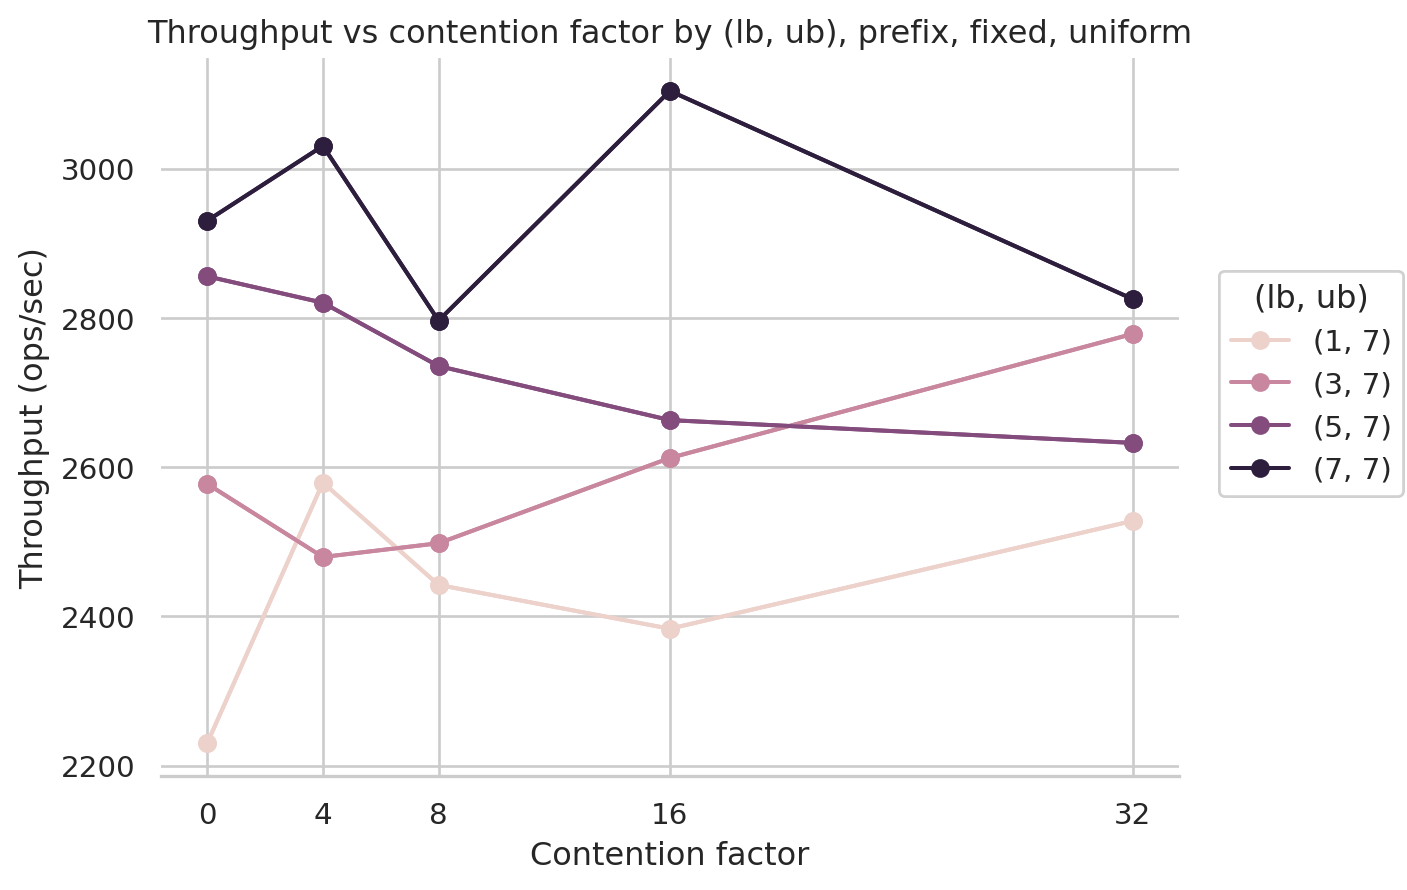

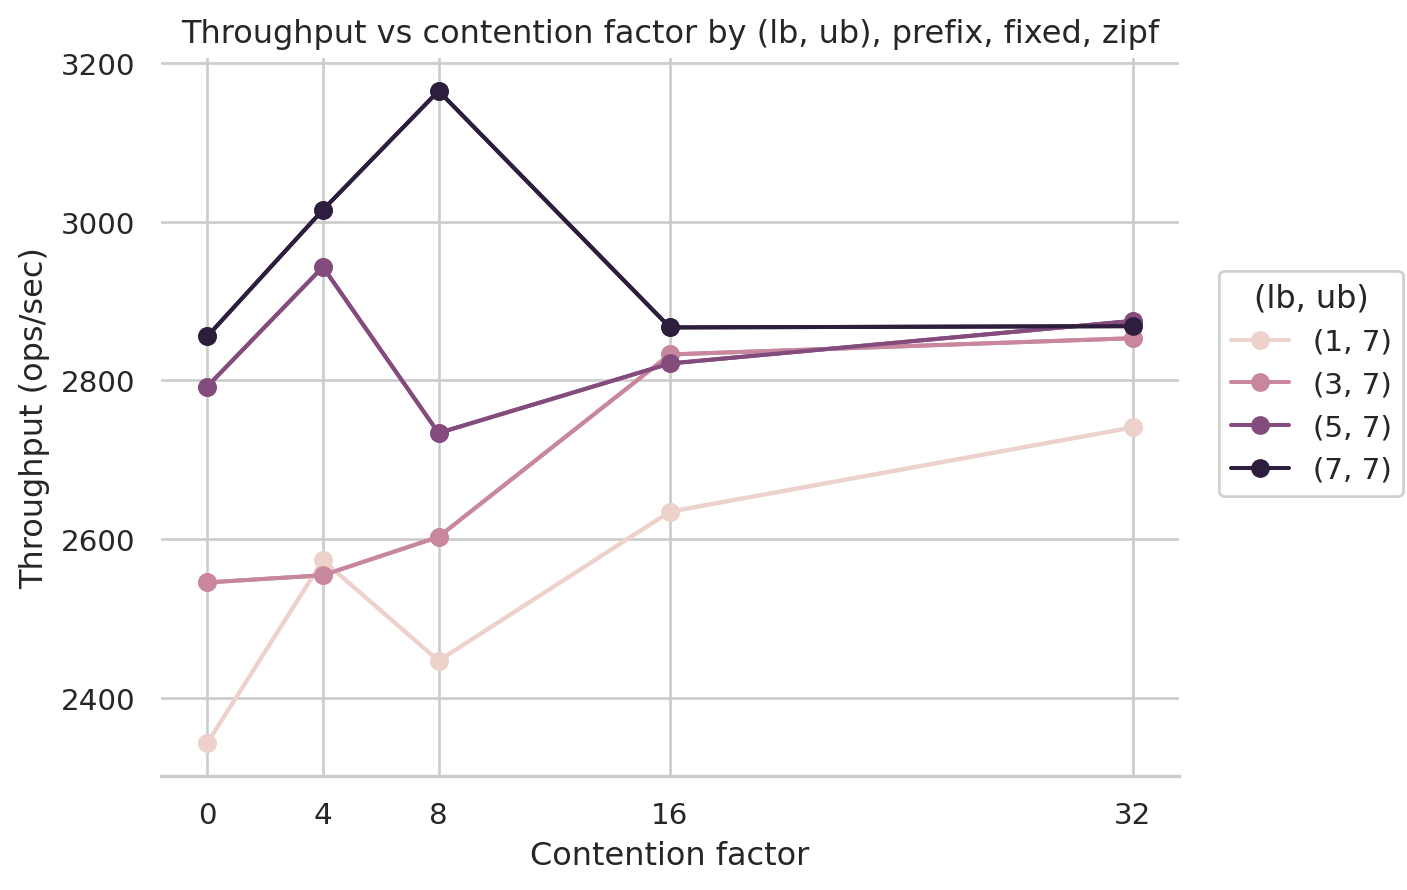

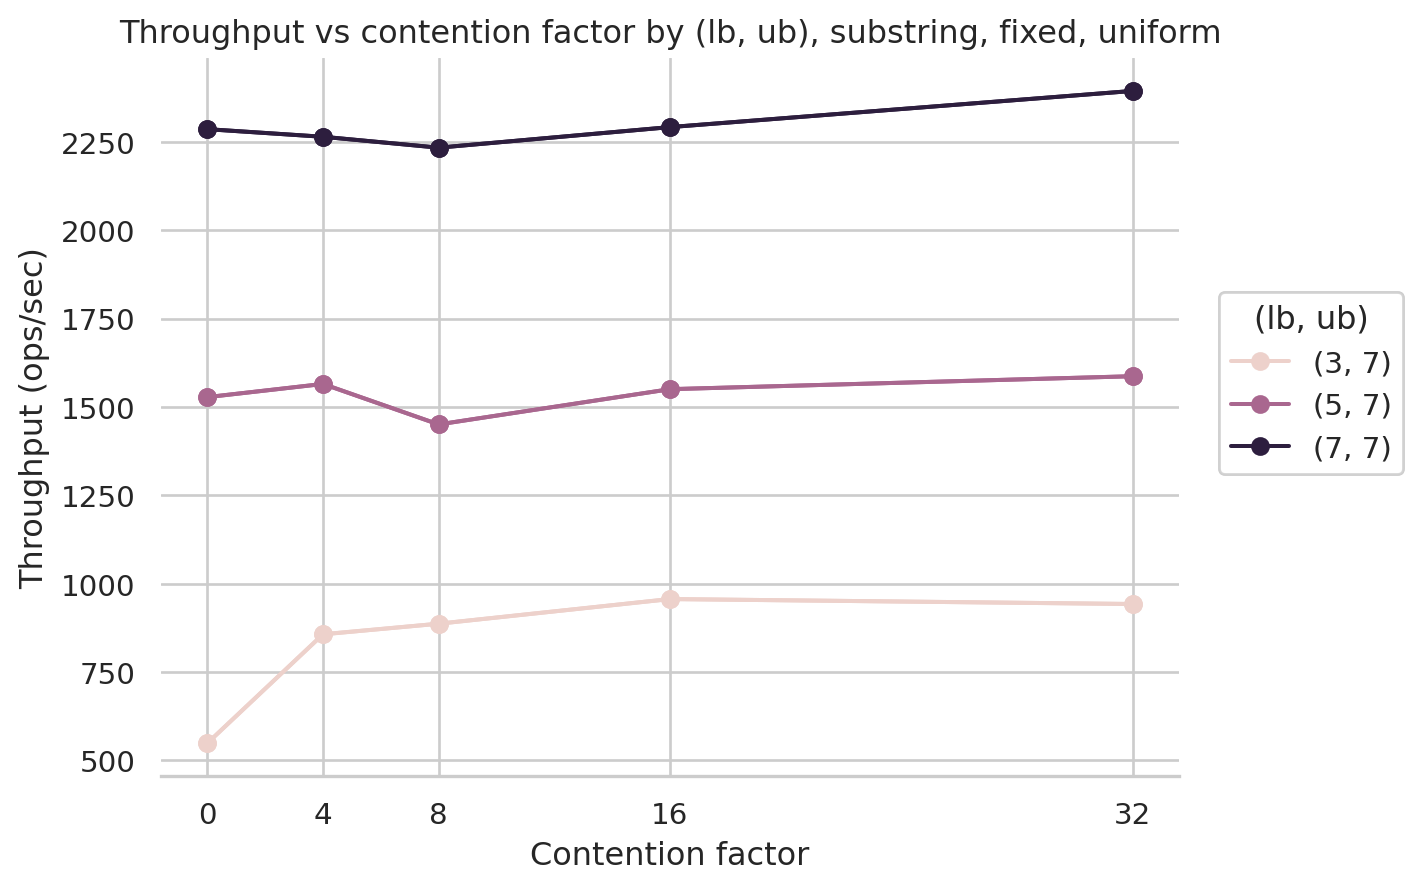

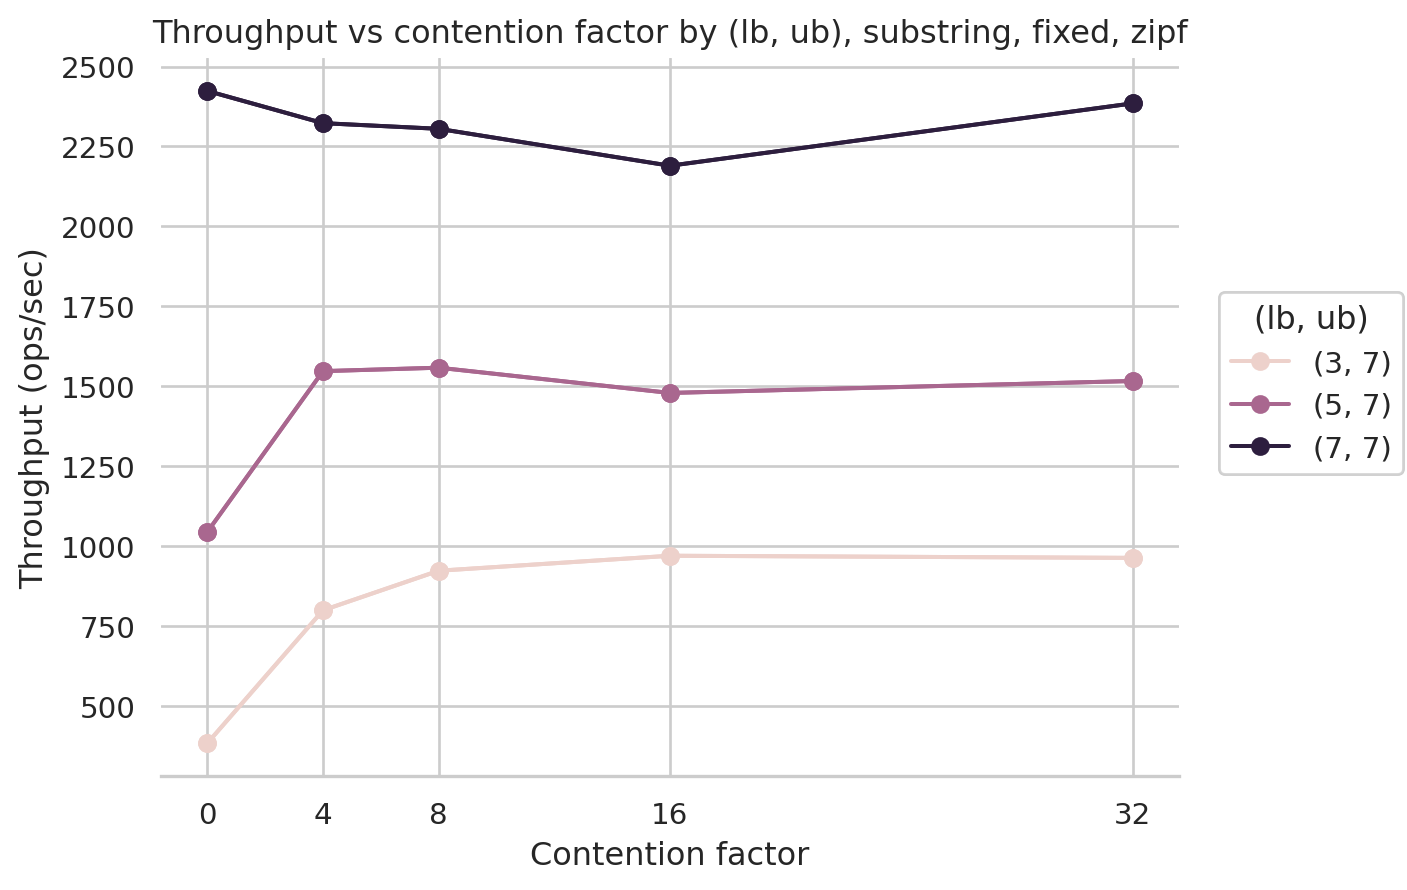

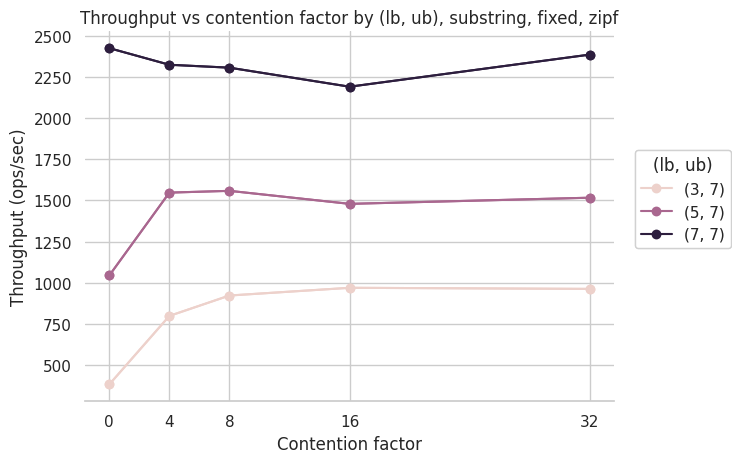

In [297]:
# Graph i4
for typ in ('prefix', 'substring'):
    for u_or_z in enc_stats['zipf_or_uniform'].unique():
        lowest_lb = 1 if typ == 'prefix' else 3
        stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['zipf_or_uniform'] == u_or_z) & (enc_stats['var_or_fixed'] == 'fixed') & (enc_stats['ub'] == 7)].copy()
        stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
        stats['tp'] = 16. * 1e9 / stats['lat_avg']
        
        title = f'Throughput vs contention factor by (lb, ub), {typ}, fixed, {u_or_z}'
        plt.close()
        ax = plt.gca()
        p = so.Plot(stats, x='cf', y='tp', color='lb')
        p = p.add(so.Line(marker='o', alpha=1))
        p = p.label(title=title, x='Contention factor', y='Throughput (ops/sec)', color='(lb, ub)')
        p = p.theme(sns.axes_style(style='whitegrid'))
        p = p.layout(engine='tight')
        p = p.scale(x=so.Continuous().tick(at=stats['cf'].unique()), color=so.Continuous().tick(at=stats['lb'].unique()).label(like='({x}, 7)'))
        p = p.on(ax)
        sns.despine(ax=ax, left=True)

        p.save(f'../figures/graphi4-{typ}-{u_or_z}.png', bbox_inches='tight')
        display(p)


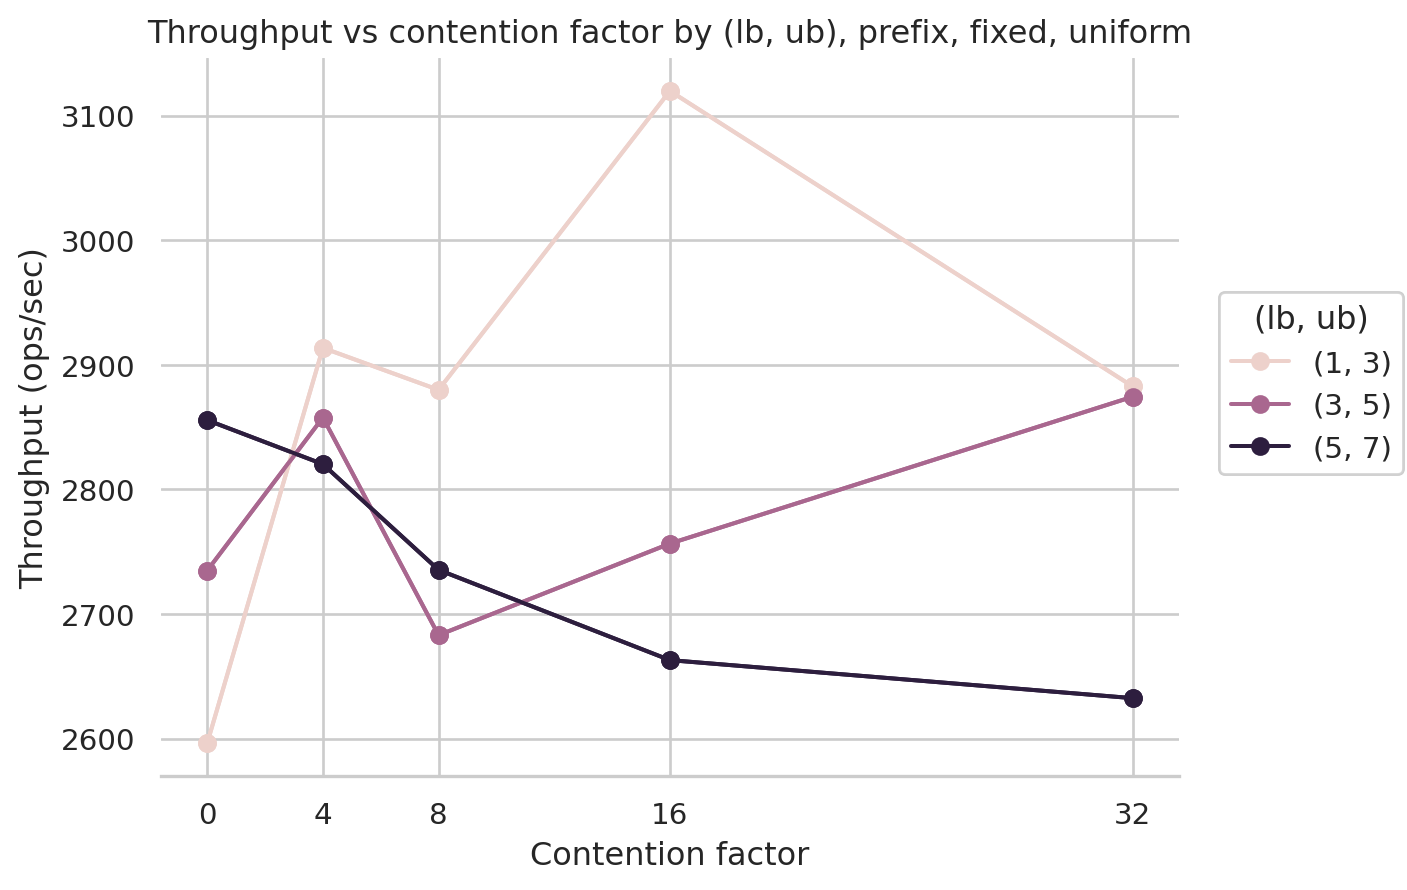

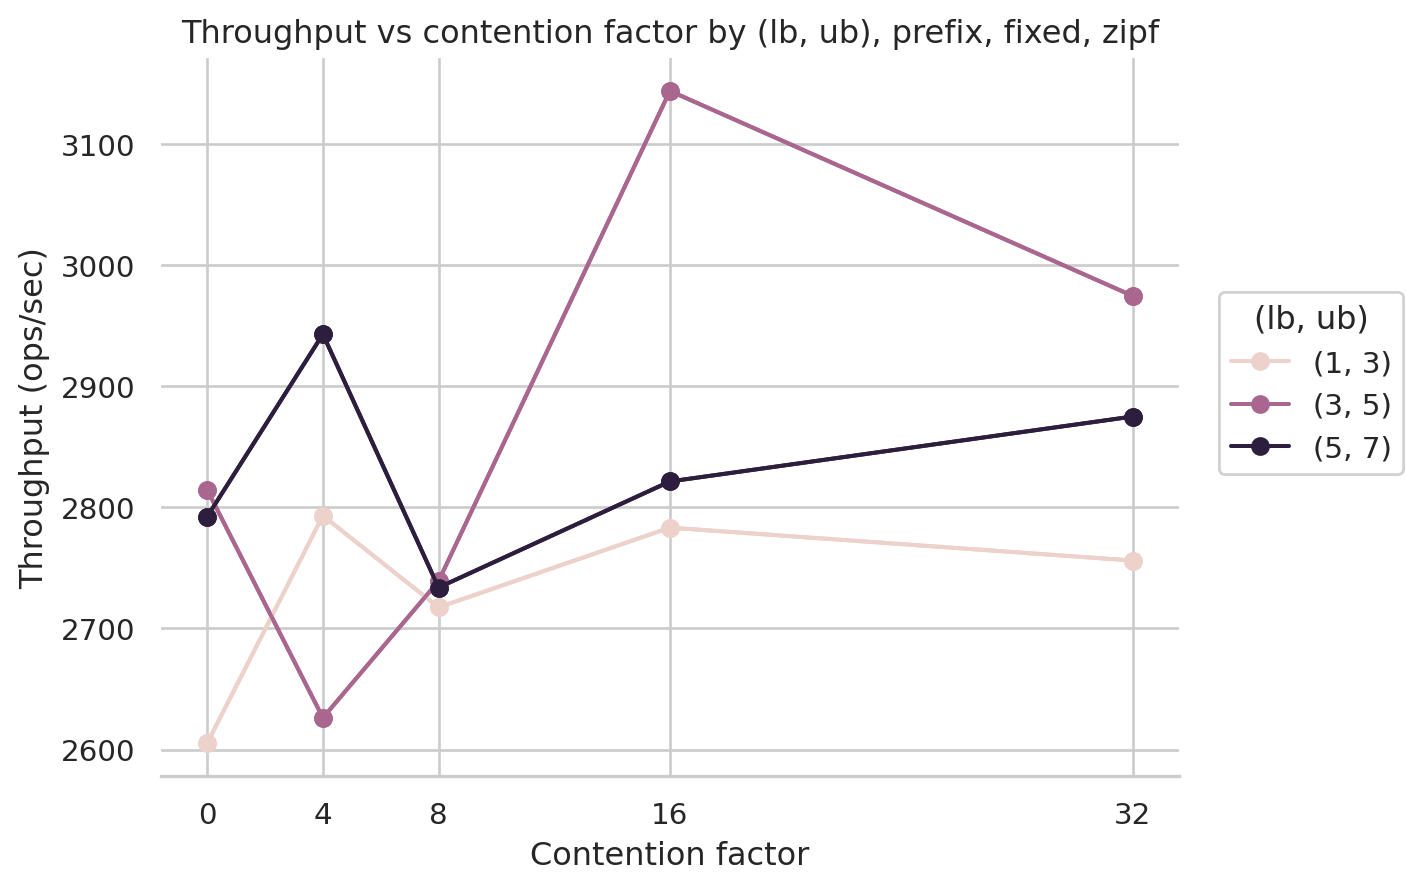

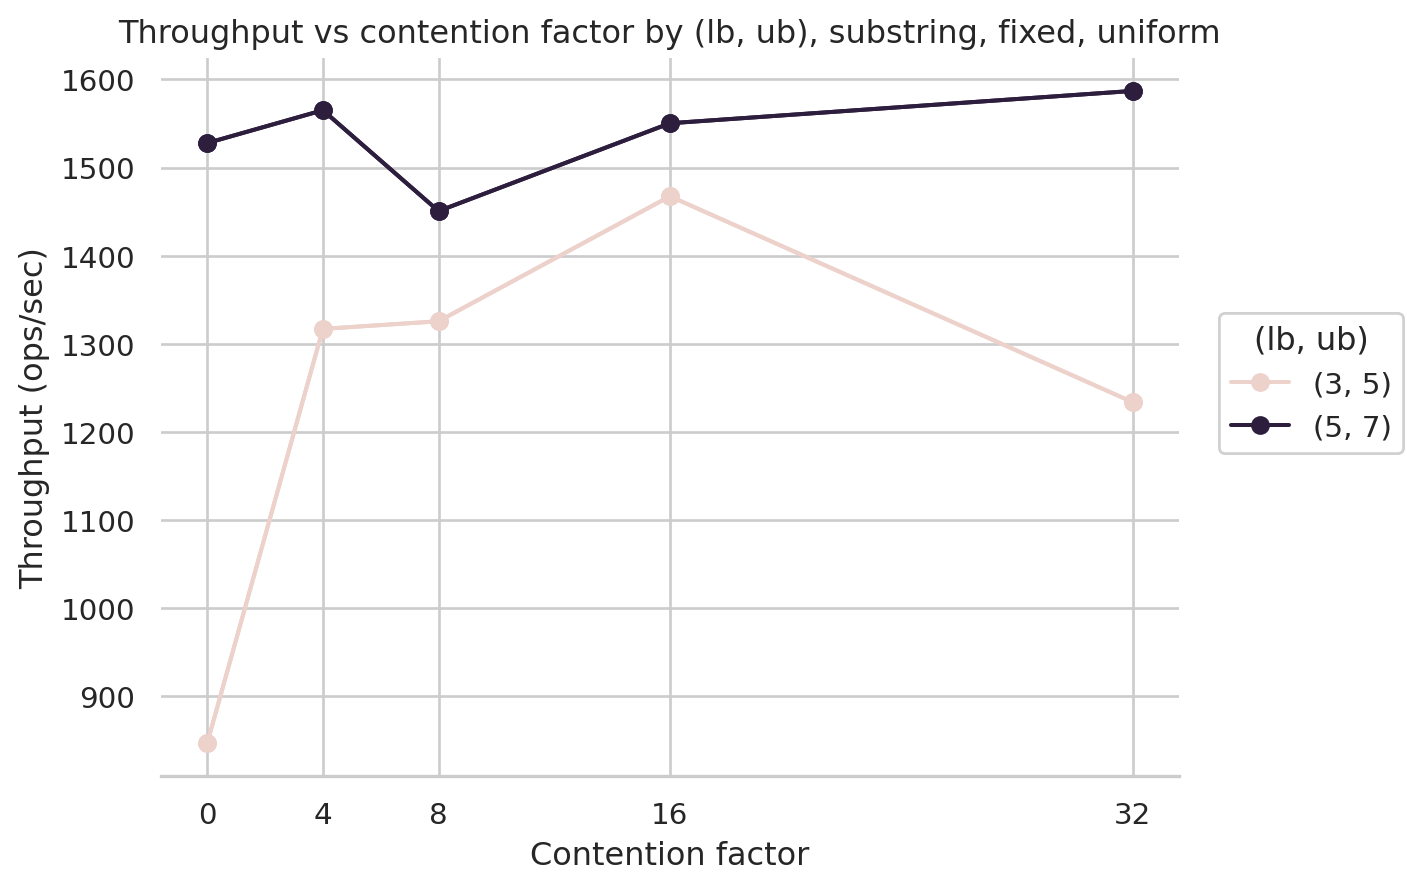

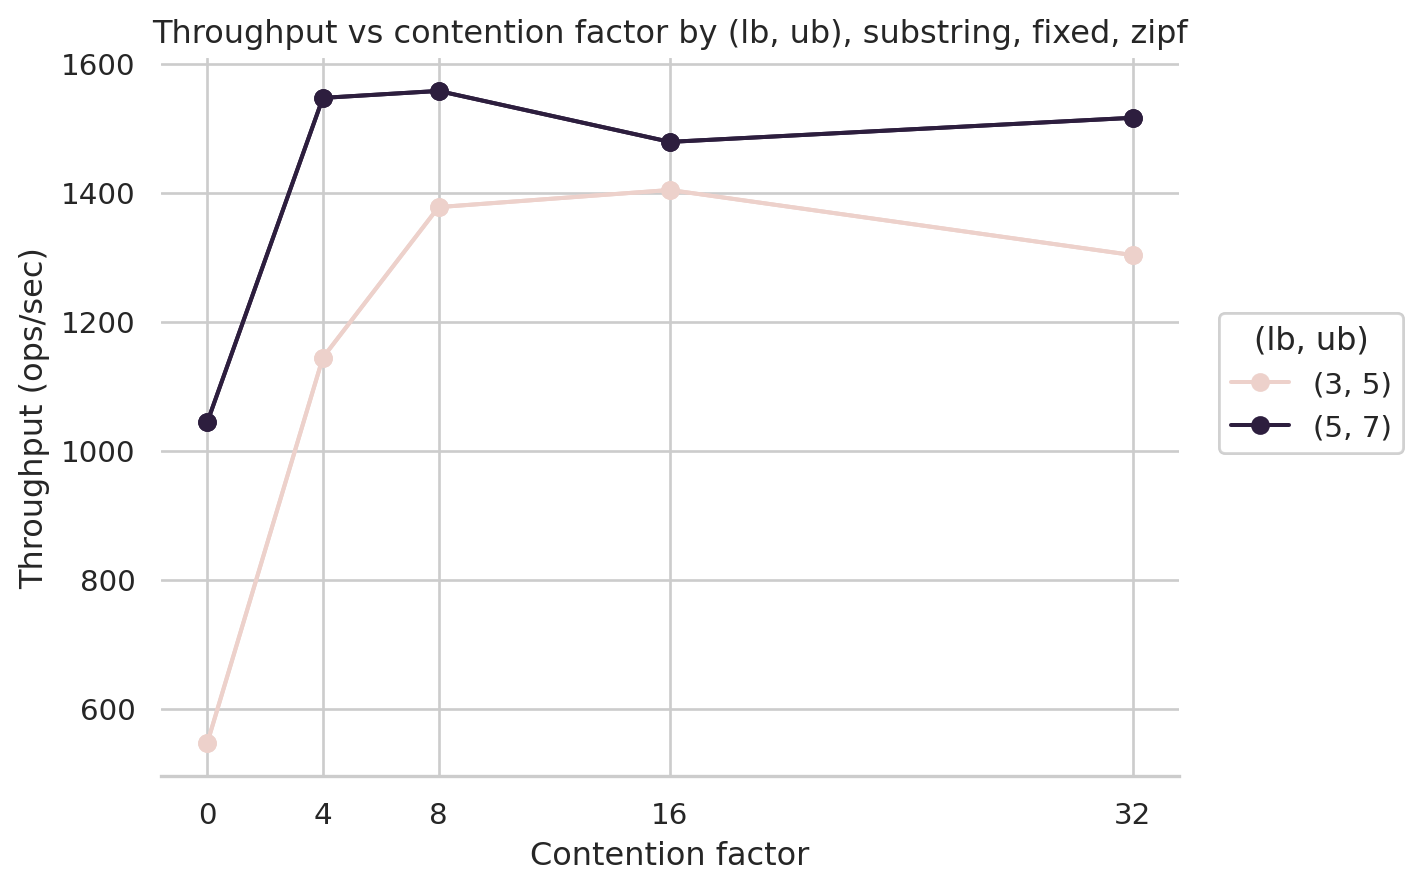

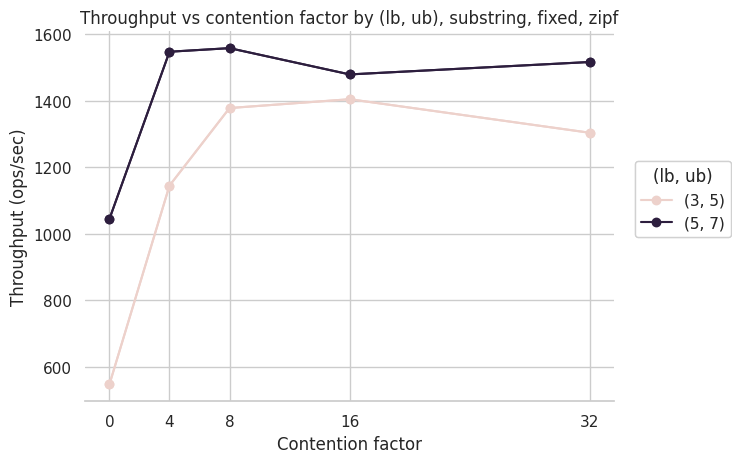

In [299]:
# Graph i5
for typ in ('prefix', 'substring'):
    for u_or_z in enc_stats['zipf_or_uniform'].unique():
        lowest_lb = 1 if typ == 'prefix' else 3
        stats = enc_stats[(enc_stats['ss_or_pref'] == typ) & (enc_stats['zipf_or_uniform'] == u_or_z) & (enc_stats['var_or_fixed'] == 'fixed') & (enc_stats['ub'] - enc_stats['lb'] == 2)].copy()
        stats['collname'] = stats['var_or_fixed'] + ', ' + stats['zipf_or_uniform']
        stats['tp'] = 16. * 1e9 / stats['lat_avg']
        
        title = f'Throughput vs contention factor by (lb, ub), {typ}, fixed, {u_or_z}'
        plt.close()
        ax = plt.gca()
        p = so.Plot(stats, x='cf', y='tp', color='lb')
        p = p.add(so.Line(marker='o', alpha=1))
        p = p.label(title=title, x='Contention factor', y='Throughput (ops/sec)', color='(lb, ub)')
        p = p.theme(sns.axes_style(style='whitegrid'))
        p = p.layout(engine='tight')
        p = p.scale(x=so.Continuous().tick(at=stats['cf'].unique()), color=so.Continuous().tick(at=stats['lb'].unique()).label(like=lambda x, _: f'({x}, {x + 2})'))
        p = p.on(ax)
        sns.despine(ax=ax, left=True)

        p.save(f'../figures/graphi5-{typ}-{u_or_z}.png', bbox_inches='tight')
        display(p)


In [ ]:
# Conflict probability investigation
docs = docsets['fixed-zipf-16']
unq_docs = set(docs)
assert len(unq_docs) == 1000
from collections import Counter
c = Counter()
c.update(docs)
print(c)

def shares_ss(a, b, l):
    a_subs = {a[i:i+l] for i in range(len(a) - l + 1)}
    b_subs = {b[i:i+l] for i in range(len(b) - l + 1)}
    return len(a_subs.intersection(b_subs)) > 0


rn = list(range(100000))
zipf_ov = zipf_miss = fixed_ov = fixed_miss = 0
for _ in range(1000000):
    i, j = random.sample(rn, 2)
    if shares_ss(docsets['fixed-zipf-16'][i], docsets['fixed-zipf-16'][j],2):
        zipf_ov += 1
    else:
        zipf_miss += 1
    if shares_ss(docsets['fixed-uniform-16'][i], docsets['fixed-uniform-16'][j], 2):
        fixed_ov += 1
    else:
        fixed_miss += 1

print(zipf_ov, zipf_miss, fixed_ov, fixed_miss)


Counter({'7243543523956387': 17853, '8011491949087386': 8329, '2082760975380644': 5332, '4500061651308326': 3886, '5425691679082928': 3040, '1380855710197684': 2488, '3202334016030966': 2100, '3392014299115800': 1813, '3326691221868292': 1593, '6838628061815207': 1419, '9765406157624282': 1277, '8096938801742317': 1161, '5800850754786667': 1063, '3484913290651978': 980, '3192282357916297': 908, '4297278080216017': 846, '5617026880618261': 792, '8456889926724871': 743, '4531748734573737': 700, '2524306255516808': 662, '4370611902068829': 627, '8963436312890367': 596, '8067663507005287': 568, '8168231222238482': 542, '9405488626656051': 518, '6865589016745389': 496, '3204782701169330': 476, '3047706177699597': 457, '6538620483812313': 440, '1096770867722547': 424, '2514735254247463': 409, '7202684964909320': 395, '3727350353030346': 382, '8866245191915308': 370, '3247649183513419': 358, '9415839930261665': 347, '0486110517254077': 337, '0491613942433240': 327, '2344425942215312': 318, '8